### Otter Hydraulic System — Notebook 4  
#### Clustering & Supervised Learning

<img src="fig_cluster_embedding_better.png" alt="Otter logo" width="180" align="left" style="margin-right:15px">

This notebook applies **unsupervised and supervised machine learning** methods to the cleaned and labelled Otter hydraulic dataset to identify patterns, classify system states, and support predictive maintenance analysis.


### **Overview**


- Load in previosully cleaned data set, resample to 15 minutes, apply functions to add rolling means, std deviations and log transformations on numeric data
- Explore and visualise labelled data to understand operational regimes.  Ensure no operational flags are carried into unsupervised or supervised leanring models
- Apply clustering method HDBSCAN to detect natural groupings and anomalies
- Identify what operational regimes these clsuters represent. Label the data with the learned states
- Develop and train supervised models (Random Forest, XGBoost, Logistic Regression) to classify hydraulic system behaviour and predict abnormal conditions.  Compare model types
- Evaluate model accuracy, precision/recall, and feature importance to interpret key drivers of losses and instability.


In [1]:
from __future__ import annotations 

# Import Libraries 
import os
import re
import sys
from collections import Counter
from pathlib import Path
from typing import Any, Dict, Optional, Tuple, Union

# Third-party
import hdbscan
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import HTML, display
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy.fft import fft, fftfreq
from scipy.stats import pearsonr, spearmanr
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.proportion import proportion_confint  # Wilson CI
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from pandas.api.types import is_numeric_dtype, is_bool_dtype
from sklearn.decomposition import PCA  # used for fallback even if UMAP is available
from matplotlib.patches import Ellipse
import re
import numpy as np
import pandas as pd
from typing import Tuple, List, Dict

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.utils.multiclass import unique_labels
from lightgbm import LGBMClassifier


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
# Import the data prcoessign pipeline for rolling means/std/log transforms

PIPE_DIR = r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\pipeline"
if PIPE_DIR not in sys.path:
    sys.path.append(PIPE_DIR)

# --- Import your pipeline 3 function ---
from otter_pipeline3__model_feature_build_time_resample import prepare_features_pipeline3


In [3]:
# Readin cleaned data files for last 4 years

# Paths (same as when you saved them)
path_clean = r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\data\df_all_otter_labeled_cleaned_v1_250825.parquet"
path_valves = r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\data\df_all_otter_valve_positions_labeled_cleaned_v1_250825.parquet"

# Load DataFrames
df = pd.read_parquet(path_clean)
otter_valve_positions_df = pd.read_parquet(path_valves)

# Quick check
print("Main cleaned dataframe:", df.shape)
print("\nColumns in df_clean (first 10):", df.columns[:10].tolist())

# USe 4 years data because beore that was noiser
# Get last 4 years dynamically from latest date in the dataset
cutoff_date = df.index.max() - pd.DateOffset(years=4)

df = df.loc[df.index >= cutoff_date].copy()

print(df[["is_steady_state","is_steady_state_strict"]].mean())

Main cleaned dataframe: (2983482, 67)

Columns in df_clean (first 10): ['HPU_SPLY_LEV_L', 'HPU_RET_LEV_L', 'HPU_SPLY_LEV_L_Smooth', 'HPU_RET_LEV_L_Smooth', 'HPU_LP_A_SPLY', 'HPU_HP_A_SPLY', 'HPU_LPA_OUT', 'HPU_LPB_OUT', 'HPU_HPA_OUT', 'HPU_HPB_OUT']
is_steady_state           0.892767
is_steady_state_strict    0.750329
dtype: float64


In [13]:
print(df.columns)

Index(['HPU_SPLY_LEV_L', 'HPU_RET_LEV_L', 'HPU_SPLY_LEV_L_Smooth',
       'HPU_RET_LEV_L_Smooth', 'HPU_LP_A_SPLY', 'HPU_HP_A_SPLY', 'HPU_LPA_OUT',
       'HPU_LPB_OUT', 'HPU_HPA_OUT', 'HPU_HPB_OUT', 'SCM1_LP_CONS',
       'SCM1_HP_CONS', 'SCM1_RET', 'FCV_CPI', '2_LP_Valve_OpenToClosed',
       '2_LP_Valve_ClosedToOpen', '5_LP_Valve_OpenToClosed',
       '5_LP_Valve_ClosedToOpen', 'HP_Valve_OpenToClosed',
       'HP_Valve_ClosedToOpen', 'FCV_Fluid_Usage', 'umbilical_charge_volume',
       'Supply_Consumption_Excl_Fills', 'External_Losses',
       'External_Loss_MA_2h', 'External_Loss_MA_12h', 'External_Loss_MA_24h',
       'External_Loss_MA_168h', 'External_Loss_EWM_1d', 'External_Loss_EWM_7d',
       'External_Losses_DropSlope_1h_Lph',
       'Supply_Consumption_Excl_Fills_DropSlope_1h_Lph', 'LP_Px_Delta',
       'HP_Px_Delta', 'Supply_Slope_2H_Lph', 'Supply_Slope_12H_Lph',
       'Supply_Slope_24H_Lph', 'HPU_LPA_OUT_DropSlope_1h_Lph',
       'HPU_LPA_OUT_DropSlope_2h_Lph', 'HPU_LPA_OU

#### Section 1. Unsupervised Learning - Detect operating state clusters

Work on data frame to reduce dimensions. Identify Highly Corelalted Features which could be removed b) Identify skewed features which will benefit from log transformation

Continuous features considered (51):
['HPU_SPLY_LEV_L', 'HPU_RET_LEV_L', 'HPU_SPLY_LEV_L_Smooth', 'HPU_RET_LEV_L_Smooth', 'HPU_LP_A_SPLY', 'HPU_HP_A_SPLY', 'HPU_LPA_OUT', 'HPU_LPB_OUT', 'HPU_HPA_OUT', 'HPU_HPB_OUT', 'SCM1_LP_CONS', 'SCM1_HP_CONS', 'SCM1_RET', 'FCV_CPI', '2_LP_Valve_OpenToClosed', '2_LP_Valve_ClosedToOpen', '5_LP_Valve_OpenToClosed', '5_LP_Valve_ClosedToOpen', 'FCV_Fluid_Usage', 'umbilical_charge_volume', 'Supply_Consumption_Excl_Fills', 'External_Losses', 'External_Loss_MA_2h', 'External_Loss_MA_12h', 'External_Loss_MA_24h', 'External_Loss_MA_168h', 'External_Loss_EWM_1d', 'External_Loss_EWM_7d', 'External_Losses_DropSlope_1h_Lph', 'Supply_Consumption_Excl_Fills_DropSlope_1h_Lph', 'LP_Px_Delta', 'HP_Px_Delta', 'Supply_Slope_2H_Lph', 'Supply_Slope_12H_Lph', 'Supply_Slope_24H_Lph', 'HPU_LPA_OUT_DropSlope_1h_Lph', 'HPU_LPA_OUT_DropSlope_2h_Lph', 'HPU_LPA_OUT_DropSlope_8h_Lph', 'HPU_LPB_OUT_DropSlope_1h_Lph', 'HPU_LPB_OUT_DropSlope_2h_Lph', 'HPU_LPB_OUT_DropSlope_8h_Lph', 

,feature_i,feature_j,abs_corr
1,HPU_SPLY_LEV_L,HPU_SPLY_LEV_L_Smooth,0.999965
52,HPU_RET_LEV_L,HPU_RET_LEV_L_Smooth,0.999865
1274,External_Loss_MA_168h,External_Loss_MA_24h,0.942168
1428,External_Losses_DropSlope_1h_Lph,Supply_Consumption_Excl_Fills_DropSlope_1h_Lph,0.925504
1070,External_Losses,Supply_Consumption_Excl_Fills,0.852408
309,HPU_LPA_OUT,SCM1_LP_CONS,0.830943
1173,External_Loss_MA_12h,External_Loss_MA_24h,0.808487
1326,External_Loss_EWM_1d,External_Loss_EWM_7d,0.754108
2499,LP_pump_rate_2h,LP_pump_state,0.738982
1174,External_Loss_MA_12h,External_Loss_MA_168h,0.715497


scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix


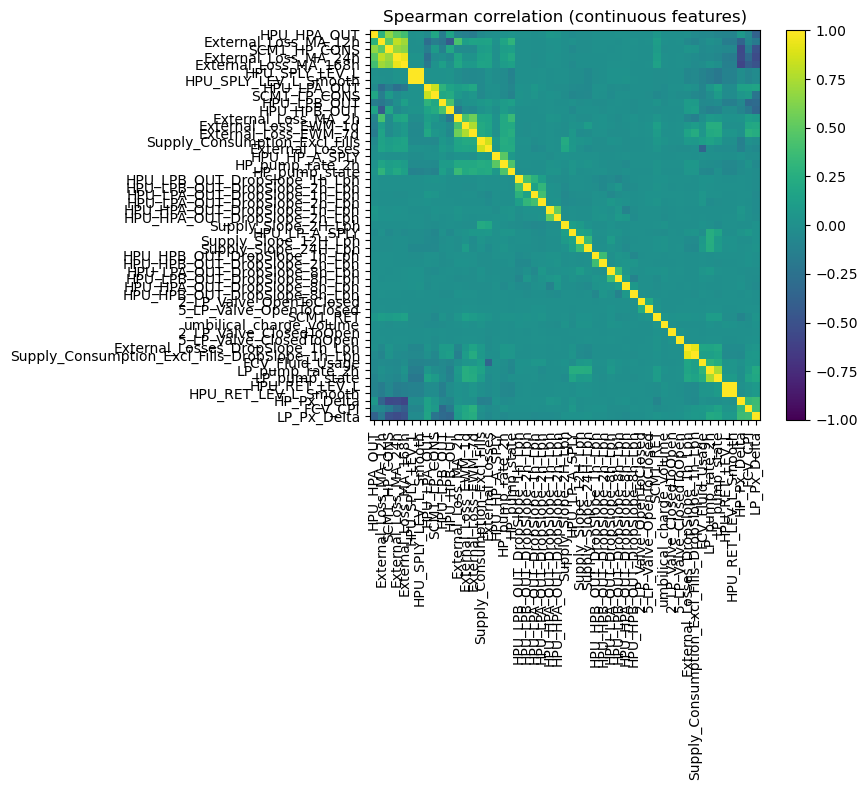


Top binary–continuous associations (point-biserial |r|):


,binary,continuous,r_pointbiserial,abs_r
222,is_fcv_ops,FCV_Fluid_Usage,1.000000,1.000000
520,is_lp_low,SCM1_LP_CONS,-0.927717,0.927717
325,is_pressurising,umbilical_charge_volume,0.851378,0.851378
621,is_no_redundancy,HPU_HPB_OUT,-0.829488,0.829488
170,is_valve_ops,5_LP_Valve_ClosedToOpen,0.805411,0.805411
490,is_hp_high,HP_Px_Delta,-0.717298,0.717298
517,is_lp_low,HPU_LPB_OUT,-0.703884,0.703884
467,is_hp_high,HPU_HPA_OUT,-0.631650,0.631650
572,is_hp_low,SCM1_HP_CONS,-0.607027,0.607027
506,is_hp_high,HP_pump_rate_2h,0.445192,0.445192



Pump-state (0/1/2) vs continuous — correlation ratio (η²):


,categorical,continuous,eta2
48,HP_pump_state,HP_pump_state,1.000000
101,LP_pump_state,LP_pump_state,1.000000
100,LP_pump_state,LP_pump_rate_2h,0.480574
47,HP_pump_state,HP_pump_rate_2h,0.415299
31,HP_pump_state,HP_Px_Delta,0.287880
8,HP_pump_state,HPU_HPA_OUT,0.250859
77,LP_pump_state,External_Loss_EWM_1d,0.224526
78,LP_pump_state,External_Loss_EWM_7d,0.208085
9,HP_pump_state,HPU_HPB_OUT,0.180968
69,LP_pump_state,FCV_Fluid_Usage,0.099404


In [4]:
# =========================================
# Correlation of variable. 
# =========================================
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from scipy.cluster.hierarchy import linkage, leaves_list
import matplotlib.pyplot as plt

# ---------------------------
# Utilities
# ---------------------------
def get_groups_from_existing(profile=None):
    """Try to reuse groups from the earlier evaluator; else infer."""
    groups = {}
    if isinstance(profile, pd.DataFrame) and "feature" in profile and "recommend" in profile:
        groups["keep_binary"]   = profile.query("recommend == 'keep_binary'")["feature"].tolist()
        groups["log1p"]         = profile.query("recommend == 'log1p'")["feature"].tolist()
        groups["yeo-johnson"]   = profile.query("recommend == 'yeo-johnson'")["feature"].tolist()
        groups["zscore"]        = profile.query("recommend == 'zscore'")["feature"].tolist()
        groups["drop_constant"] = profile.query("recommend == 'drop_constant'")["feature"].tolist()
    else:
        # Fallback inference
        def is_binary(s):
            s = pd.to_numeric(s, errors="coerce").dropna()
            return s.nunique() <= 2 and set(s.unique()) <= {0,1}
        groups["keep_binary"] = [c for c in df.columns if df[c].dropna().nunique()<=2 and is_binary(df[c])]
        groups["drop_constant"] = [c for c in df.columns if df[c].dropna().nunique()<=1]
        cont_candidates = [c for c in df.columns if c not in groups["keep_binary"] + groups["drop_constant"]]
        groups["log1p"], groups["yeo-johnson"], groups["zscore"] = [], [], cont_candidates
    # pump states if present
    groups["categorical_3state"] = [c for c in ["HP_pump_state","LP_pump_state"] if c in df.columns]
    return groups

def correlation_ratio(categories, values):
    """
    Correlation ratio (eta squared) for categorical vs continuous.
    categories: 1-D array-like of ints or strings
    values: 1-D array-like of floats
    Returns eta^2 in [0,1].
    """
    x = pd.Series(values).astype(float)
    y = pd.Series(categories)
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]
    if x.empty:
        return np.nan
    grand_mean = x.mean()
    # Between-group sum of squares
    ss_between = 0.0
    for lvl, grp in x.groupby(y):
        n = grp.size
        if n == 0: 
            continue
        ss_between += n * (grp.mean() - grand_mean)**2
    # Total sum of squares
    ss_total = ((x - grand_mean)**2).sum()
    return float(ss_between / ss_total) if ss_total > 0 else np.nan

def point_biserial(binary, continuous):
    """Point-biserial correlation for binary (0/1) vs continuous."""
    x = pd.to_numeric(binary, errors="coerce")
    y = pd.to_numeric(continuous, errors="coerce")
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]
    if x.nunique() != 2 or y.nunique() <= 1:
        return np.nan
    r, _ = pearsonr(x, y)
    return float(r)

def spearman_corr_df(X: pd.DataFrame):
    """Spearman correlation matrix with pairwise complete obs."""
    return X.corr(method="spearman")

def top_abs_pairs(corr_df, top_k=30, drop_self=True):
    """Return top absolute correlation pairs from a symmetric matrix."""
    c = corr_df.copy()
    if drop_self:
        np.fill_diagonal(c.values, np.nan)
    stacked = (
        c.abs()
         .stack()
         .reset_index()
         .rename(columns={"level_0":"feature_i", "level_1":"feature_j", 0:"abs_corr"})
    )
    # keep each pair once (i<j)
    stacked = stacked[stacked["feature_i"] < stacked["feature_j"]]
    return stacked.sort_values("abs_corr", ascending=False).head(top_k)

def plot_clustered_heatmap(corr_df, title="Spearman correlation (clustered)", vmax=1.0):
    # Hierarchical clustering to order features
    # Replace NaNs with 0 for distances
    M = corr_df.fillna(0.0).values
    # Convert correlation to distance
    D = 1 - np.clip(M, -1, 1)
    # Ward doesn't support non-euclidean directly; use average linkage
    Z = linkage(D, method="average")
    order = leaves_list(Z)
    corr_ord = corr_df.iloc[order, :].iloc[:, order]

    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr_ord.values, vmin=-vmax, vmax=vmax, interpolation="nearest")
    plt.title(title)
    plt.xticks(range(corr_ord.shape[1]), corr_ord.columns, rotation=90)
    plt.yticks(range(corr_ord.shape[0]), corr_ord.index)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# ---------------------------
# Build groups and select columns
# ---------------------------
try:
    groups = get_groups_from_existing(profile)
except NameError:
    groups = get_groups_from_existing(None)

continuous_cols = [c for c in (groups["log1p"] + groups["yeo-johnson"] + groups["zscore"])
                   if c in df.columns]
binary_cols     = [c for c in groups["keep_binary"] if c in df.columns]
pump_cols       = [c for c in groups["categorical_3state"] if c in df.columns]

# Keep only numeric continuous columns
X_cont = df[continuous_cols].apply(pd.to_numeric, errors="coerce")

# ---------------------------
# 1) Spearman correlation (continuous vs continuous)
# ---------------------------
corr_spear = spearman_corr_df(X_cont)

print(f"Continuous features considered ({len(continuous_cols)}):")
print(continuous_cols)

# Show top correlated pairs
top_pairs = top_abs_pairs(corr_spear, top_k=10)
print("\nTop correlated continuous pairs (abs Spearman):")
display(top_pairs)

# Plot clustered heatmap (matplotlib only)
plot_clustered_heatmap(corr_spear, title="Spearman correlation (continuous features)")

# ---------------------------
# 2) Point-biserial: binary tags vs continuous features
# ---------------------------
if len(binary_cols) > 0:
    rows = []
    for b in binary_cols:
        for c in continuous_cols:
            r = point_biserial(df[b], df[c])
            rows.append({"binary": b, "continuous": c, "r_pointbiserial": r})
    pb = pd.DataFrame(rows)
    pb["abs_r"] = pb["r_pointbiserial"].abs()
    pb_top = pb.sort_values("abs_r", ascending=False).head(10)
    print("\nTop binary–continuous associations (point-biserial |r|):")
    display(pb_top)
else:
    print("\nNo binary columns detected for point-biserial step.")

# ---------------------------
# 3) Correlation ratio (η²): pump_state (0/1/2) vs continuous features
# ---------------------------
if len(pump_cols) > 0:
    rows = []
    for cat in pump_cols:
        for c in continuous_cols:
            eta2 = correlation_ratio(df[cat], df[c])
            rows.append({"categorical": cat, "continuous": c, "eta2": eta2})
    eta = pd.DataFrame(rows).sort_values("eta2", ascending=False)
    print("\nPump-state (0/1/2) vs continuous — correlation ratio (η²):")
    display(eta.head(10))
else:
    print("\nNo pump state columns found for correlation-ratio step.")

# ---------------------------



In [5]:
# =========================================
# Feature Transformation Evaluator - Decide Outliers for log transofmrations
# =========================================
import re
import numpy as np
import pandas as pd
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer

BOOLEAN_FEATURES_WANTED = [
    "is_fcv_ops", "is_valve_ops",
    "is_tank_fill",
    "is_pressurising","is_steady_state","is_steady_state_strict","is_losses_high","is_consumption_low",
    
]

EVAL_LABEL = "is_steady_state_strict"
# ---------------------------
# Helpers
# ---------------------------
def robust_outlier_rate(series: pd.Series, thresh=4.0):
    s = pd.to_numeric(series, errors="coerce").dropna().astype(float)
    if s.empty:
        return 0.0
    med = np.median(s)
    mad = np.median(np.abs(s - med)) or 1e-9
    z = 0.6745 * (s - med) / mad
    return float((np.abs(z) > thresh).mean())

def is_binary_series(s: pd.Series):
    s = pd.to_numeric(s, errors="coerce").dropna().astype(float)
    return len(s.unique()) <= 2 and set(s.unique()) <= {0.0, 1.0}

def name_implies_nonnegative(name: str):
    name_l = name.lower()
    return any(k in name_l for k in [
        "usage","consumption","volume","lev","rate","ma_","ewm",
        "open","closed","lph","count","ops","fill"
    ])

def recommend_transform(col: pd.Series, name: str,
                        tail_ratio_thresh=10.0, skew_thresh=1.0, zero_infl_thresh=0.9):
    """Return one of: drop_constant | keep_binary | log1p | yeo-johnson | zscore | categorical_3state"""
    s_raw = pd.to_numeric(col, errors="coerce")
    s = s_raw.dropna().astype(float)

    if s.empty or s.nunique() <= 1:
        return "drop_constant"

    # special-case pump states 0/1/2
    if name in {"HP_pump_state","LP_pump_state"}:
        uniq = set(s.unique())
        if uniq <= {0.0,1.0,2.0}:
            return "categorical_3state"

    if is_binary_series(s_raw):
        return "keep_binary"

    minv, maxv = float(s.min()), float(s.max())
    p50, p95, p99 = np.percentile(s, [50, 95, 99])
    s_skew = skew(s) if len(s) >= 8 else 0.0
    zero_pct = float((s_raw == 0).mean())
    tail_ratio = (p99 / p50) if p50 != 0 else np.inf
    heavy_tail = (tail_ratio > tail_ratio_thresh) or (s_skew > skew_thresh) or (zero_pct > zero_infl_thresh)

    # signed vs nonnegative
    nonneg_hint = name_implies_nonnegative(name)
    if minv >= 0 or nonneg_hint:
        return "log1p" if heavy_tail else "zscore"
    else:
        return "yeo-johnson" if heavy_tail else "zscore"

def profile_dataframe(df: pd.DataFrame,
                      tail_ratio_thresh=10.0, skew_thresh=1.0, zero_infl_thresh=0.9):
    rows = []
    for c in df.columns:
        s_raw = pd.to_numeric(df[c], errors="coerce")
        s = s_raw.dropna().astype(float)
        if s.empty:
            rows.append({"feature": c, "min": np.nan, "p50": np.nan, "p95": np.nan, "p99": np.nan, "max": np.nan,
                         "skew": np.nan, "%zeros": np.nan, "outlier_rate(robust)": np.nan,
                         "recommend": "drop_constant"})
            continue

        if s.nunique() <= 1:
            rec = "drop_constant"
            sk = 0.0
            zr = float((s_raw == 0).mean())
            med = float(s.iloc[0])
            p50 = p95 = p99 = med
        else:
            rec = recommend_transform(s_raw, c, tail_ratio_thresh, skew_thresh, zero_infl_thresh)
            sk = float(skew(s)) if len(s) >= 8 else 0.0
            zr = float((s_raw == 0).mean())
            p50, p95, p99 = [float(x) for x in np.percentile(s, [50, 95, 99])]

        out_rate = robust_outlier_rate(s_raw)
        rows.append({
            "feature": c,
            "min": float(np.nanmin(s)),
            "p50": p50,
            "p95": p95,
            "p99": p99,
            "max": float(np.nanmax(s)),
            "skew": sk,
            "%zeros": zr,
            "outlier_rate(robust)": out_rate,
            "recommend": rec
        })
    prof = pd.DataFrame(rows).sort_values(["recommend", "feature"]).reset_index(drop=True)
    return prof

# ---------------------------
# Run profiling
# ---------------------------
profile = profile_dataframe(df)

# Show everything nicely
pd.set_option('display.max_rows', profile.shape[0])
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', 120)
display(profile)



# ---------------------------
# Build transform groups
# ---------------------------
groups = {
    "drop_constant": profile.query("recommend == 'drop_constant'")["feature"].tolist(),
    "keep_binary": profile.query("recommend == 'keep_binary'")["feature"].tolist(),
    "log1p": profile.query("recommend == 'log1p'")["feature"].tolist(),
    "yeo-johnson": profile.query("recommend == 'yeo-johnson'")["feature"].tolist(),
    "zscore": profile.query("recommend == 'zscore'")["feature"].tolist(),
    "categorical_3state": [c for c in ["HP_pump_state","LP_pump_state"] if c in df.columns]
}

print("\n=== Transform plan ===")
for k,v in groups.items():
    print(f"{k:>16}: {len(v)} → {v[:12]}{' …' if len(v)>12 else ''}")

# ---------------------------
# (Optional) zero-inflation & heavy-tail spotlight for log1p candidates
# ---------------------------
if len(groups["log1p"]) > 0:
    spotlight = profile[profile["feature"].isin(groups["log1p"])].copy()
    spotlight["tail_ratio"] = spotlight.apply(lambda r:
        (np.inf if r["p50"]==0 else (r["p99"]/r["p50"])), axis=1)
    spotlight = spotlight.sort_values(["%zeros","tail_ratio","skew"], ascending=[False, False, False])
    print("\nTop log1p candidates (zero-inflated & heavy-tailed):")
    display(spotlight.head(20)[["feature","%zeros","tail_ratio","skew","p50","p95","p99","max"]])

# ---------------------------
# (Optional) correlation pruning to remove near-duplicates
# We do this separately for continuous features, leaving binaries/categoricals alone.
# ---------------------------
def correlation_prune(df_in: pd.DataFrame, cols: list, rho=0.98, method="spearman"):
    cols = [c for c in cols if c in df_in.columns]
    if not cols:
        return cols, []
    X = df_in[cols].apply(pd.to_numeric, errors="coerce")
    corr = X.corr(method=method).abs()
    to_drop = set()
    # simple greedy: drop later columns if highly correlated with any earlier kept one
    kept = []
    for i,c in enumerate(cols):
        if c in to_drop:
            continue
        kept.append(c)
        high = corr.index[(corr[c] > rho) & (corr.index != c)].tolist()
        to_drop.update(set(high))
    drop_list = [c for c in cols if c in to_drop and c not in kept]
    return kept, drop_list

continuous_cols = groups["log1p"] + groups["yeo-johnson"] + groups["zscore"]
kept_cont, dup_cont = correlation_prune(df, continuous_cols, rho=0.98, method="spearman")

print("\n=== Correlation pruning (continuous) ===")
print("kept:", len(kept_cont), "examples:", kept_cont[:12], "…")
print("dropped as near-duplicates:", len(dup_cont), "examples:", dup_cont[:12], "…")

# ---------------------------
# Final recommended feature set (for later modeling)
#   - continuous kept after pruning
#   - binaries as-is
#   - pump states as categorical (to one-hot later)
# ---------------------------
final_plan = {
    "continuous_log1p":   [c for c in kept_cont if c in groups["log1p"]],
    "continuous_yeoj":    [c for c in kept_cont if c in groups["yeo-johnson"]],
    "continuous_zscore":  [c for c in kept_cont if c in groups["zscore"]],
    "binary_passthrough": groups["keep_binary"],
    "categorical_3state": groups["categorical_3state"],
    "dropped_constant":   groups["drop_constant"],
    "dropped_corr_dupes": dup_cont
}

#import json, pathlib, yaml
#pathlib.Path("transform_plan.json").write_text(json.dumps(final_plan, indent=2))
#try:
#    pathlib.Path("transform_plan.yaml").write_text(yaml.safe_dump(final_plan, sort_keys=False))
#except Exception:
#    pass  # pyyaml may not be installed

print("\n=== Final transform plan (counts) ===")
for k,v in final_plan.items():
    print(f"{k:>22}: {len(v)}")

print("\nTip: apply transforms as -> log1p(nonneg), Yeo-Johnson(signed heavy-tail), z-score(others), "
      "one-hot pump states, passthrough binaries. Keep steady-state masks for later modeling.")


,feature,min,p50,p95,p99,max,skew,%zeros,outlier_rate(robust),recommend
0,HP_Valve_ClosedToOpen,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,drop_constant
1,HP_Valve_OpenToClosed,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,drop_constant
2,is_consumption_low,0.000000,1.000000e+00,1.000000,1.000000,1.000000,-1.156726,0.249671,0.249671,keep_binary
3,is_fcv_ops,0.000000,0.000000e+00,1.000000,1.000000,1.000000,3.842661,0.943523,0.056477,keep_binary
4,is_hp_high,0.000000,0.000000e+00,0.000000,1.000000,1.000000,5.484257,0.969739,0.030261,keep_binary
5,is_hp_low,0.000000,0.000000e+00,1.000000,1.000000,1.000000,1.672017,0.820697,0.179303,keep_binary
6,is_losses_high,0.000000,0.000000e+00,1.000000,1.000000,1.000000,2.538814,0.892767,0.107233,keep_binary
7,is_lp_high,0.000000,0.000000e+00,0.000000,0.000000,1.000000,37.827876,0.999303,0.000697,keep_binary
8,is_lp_low,0.000000,0.000000e+00,0.000000,1.000000,1.000000,9.699268,0.989698,0.010302,keep_binary
9,is_no_redundancy,0.000000,1.000000e+00,1.000000,1.000000,1.000000,-0.152500,0.461985,0.461985,keep_binary



=== Transform plan ===
   drop_constant: 2 → ['HP_Valve_ClosedToOpen', 'HP_Valve_OpenToClosed']
     keep_binary: 14 → ['is_consumption_low', 'is_fcv_ops', 'is_hp_high', 'is_hp_low', 'is_losses_high', 'is_lp_high', 'is_lp_low', 'is_no_redundancy', 'is_pressurising', 'is_steady_state', 'is_steady_state_strict', 'is_supply_tank_low'] …
           log1p: 23 → ['2_LP_Valve_ClosedToOpen', '2_LP_Valve_OpenToClosed', '5_LP_Valve_ClosedToOpen', '5_LP_Valve_OpenToClosed', 'External_Loss_EWM_1d', 'External_Loss_EWM_7d', 'External_Loss_MA_12h', 'External_Loss_MA_2h', 'FCV_Fluid_Usage', 'HPU_HPA_OUT_DropSlope_1h_Lph', 'HPU_HPA_OUT_DropSlope_2h_Lph', 'HPU_HPA_OUT_DropSlope_8h_Lph'] …
     yeo-johnson: 2 → ['External_Losses', 'HP_Px_Delta']
          zscore: 26 → ['External_Loss_MA_168h', 'External_Loss_MA_24h', 'External_Losses_DropSlope_1h_Lph', 'FCV_CPI', 'HPU_HPA_OUT', 'HPU_HPB_OUT', 'HPU_HPB_OUT_DropSlope_1h_Lph', 'HPU_HPB_OUT_DropSlope_2h_Lph', 'HPU_HPB_OUT_DropSlope_8h_Lph', 'HPU_HP_A_SPLY',

,feature,%zeros,tail_ratio,skew,p50,p95,p99,max
17,2_LP_Valve_OpenToClosed,0.999965,inf,196.406079,0.000000e+00,0.000000,0.000000,3.000000
16,2_LP_Valve_ClosedToOpen,0.999953,inf,152.316916,0.000000e+00,0.000000,0.000000,2.000000
18,5_LP_Valve_ClosedToOpen,0.999830,inf,79.222701,0.000000e+00,0.000000,0.000000,2.000000
19,5_LP_Valve_OpenToClosed,0.999715,inf,128.265530,0.000000e+00,0.000000,0.000000,8.000000
38,umbilical_charge_volume,0.999560,inf,62.091503,0.000000e+00,0.000000,0.000000,11.599569
24,FCV_Fluid_Usage,0.943523,inf,3.842661,0.000000e+00,0.350000,0.350000,0.350000
35,LP_pump_rate_2h,0.717495,inf,3.489062,0.000000e+00,1.500000,3.000000,6.500000
37,Supply_Consumption_Excl_Fills,0.060027,3.649684e+01,32.125505,3.398883e-02,0.108308,1.240485,154.532317
34,HP_pump_rate_2h,0.035627,3.500000e+00,2.243197,1.000000e+00,1.500000,3.500000,8.500000
20,External_Loss_EWM_1d,0.003423,7.475980e+00,3.370765,5.733025e+01,239.017461,428.599801,780.769176



=== Correlation pruning (continuous) ===
kept: 49 examples: ['2_LP_Valve_ClosedToOpen', '2_LP_Valve_OpenToClosed', '5_LP_Valve_ClosedToOpen', '5_LP_Valve_OpenToClosed', 'External_Loss_EWM_1d', 'External_Loss_EWM_7d', 'External_Loss_MA_12h', 'External_Loss_MA_2h', 'FCV_Fluid_Usage', 'HPU_HPA_OUT_DropSlope_1h_Lph', 'HPU_HPA_OUT_DropSlope_2h_Lph', 'HPU_HPA_OUT_DropSlope_8h_Lph'] …
dropped as near-duplicates: 2 examples: ['HPU_RET_LEV_L_Smooth', 'HPU_SPLY_LEV_L_Smooth'] …

=== Final transform plan (counts) ===
      continuous_log1p: 22
       continuous_yeoj: 2
     continuous_zscore: 25
    binary_passthrough: 14
    categorical_3state: 2
      dropped_constant: 2
    dropped_corr_dupes: 2

Tip: apply transforms as -> log1p(nonneg), Yeo-Johnson(signed heavy-tail), z-score(others), one-hot pump states, passthrough binaries. Keep steady-state masks for later modeling.


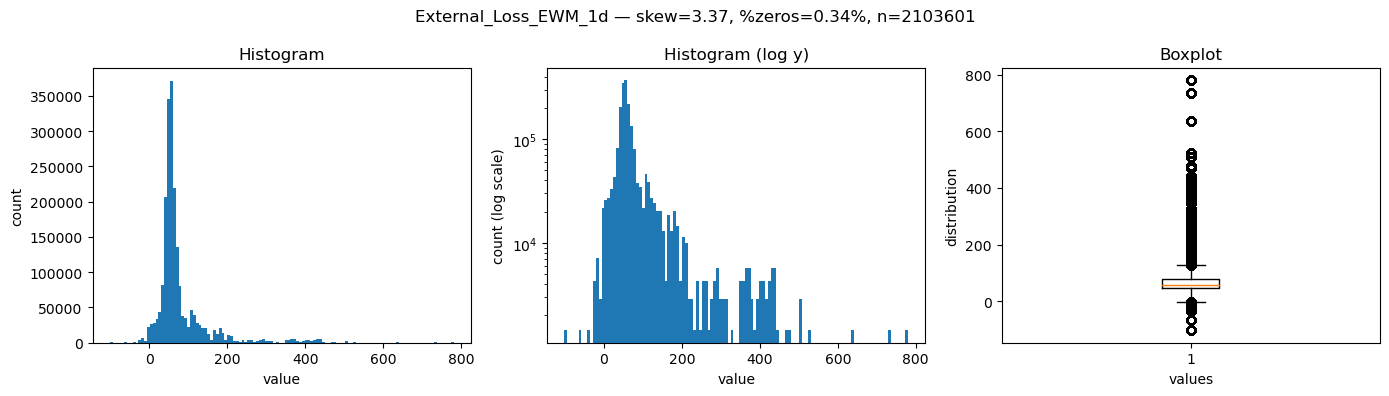

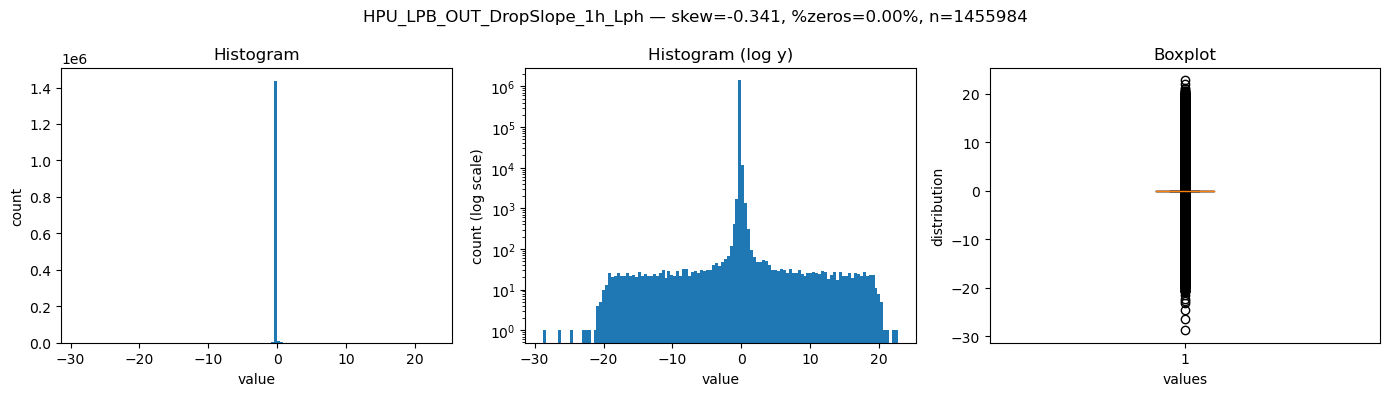

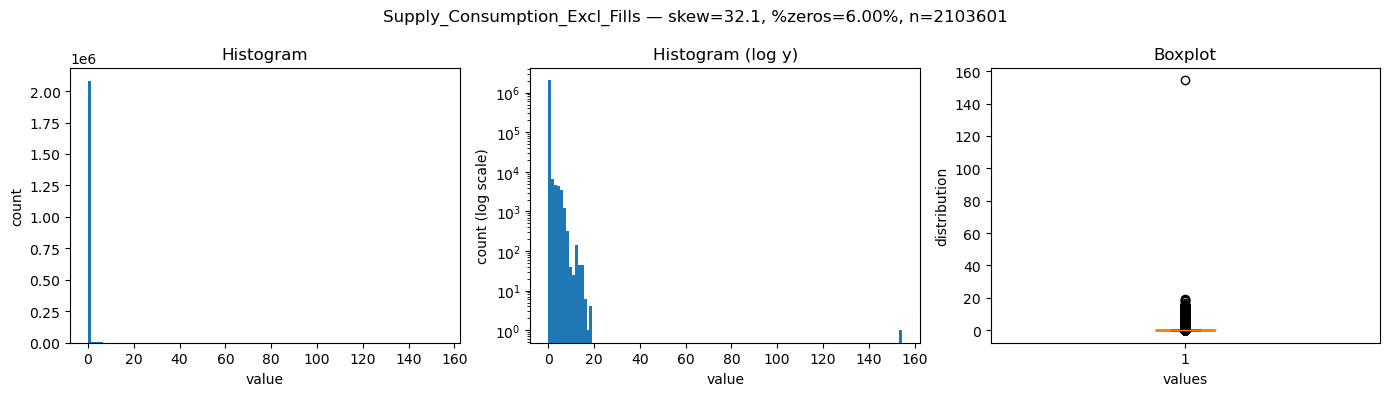

In [6]:
# Plot histogram for the Skewed points before and after the log transformation 

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- feature list from your message ---
chosen_features = [
    "External_Loss_EWM_1d",
    "HPU_LPB_OUT_DropSlope_1h_Lph","Supply_Consumption_Excl_Fills"
]

def ensure_df():
    g = globals()
    if "df" in g and isinstance(g["df"], pd.DataFrame) and not g["df"].empty:
        return g["df"]
    # try default CSV path
    if os.path.exists("/mnt/data/data.csv"):
        df_local = pd.read_csv("/mnt/data/data.csv")
        g["df"] = df_local
        return df_local
    raise RuntimeError("No DataFrame `df` found and /mnt/data/data.csv is not available. Please load your data.")

def is_binary_series(s: pd.Series):
    x = pd.to_numeric(s, errors="coerce").dropna().astype(float)
    u = set(x.unique())
    return len(u) <= 2 and u.issubset({0.0, 1.0})

def series_clean(s: pd.Series):
    x = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    return x

def percent_zeros(s: pd.Series):
    return float((pd.to_numeric(s, errors="coerce") == 0).mean())

def safe_skew(x: pd.Series):
    try:
        return float(x.skew()) if x.size >= 3 else np.nan
    except Exception:
        return np.nan

df = ensure_df()

available = [c for c in chosen_features if c in df.columns]
missing = [c for c in chosen_features if c not in df.columns]

if missing:
    print("Warning: missing columns (skipping):", missing)

for feat in available:
    s = df[feat]
    if is_binary_series(s):
        print(f"[skip binary] {feat}")
        continue
    x = series_clean(s)
    if x.empty:
        print(f"[skip empty] {feat}")
        continue

    # Quick stats for title
    pzeros = percent_zeros(s)
    sk = safe_skew(x)

    # Heuristic bins
    bins = min(120, max(30, int(np.sqrt(len(x)))))

    # One row, three columns: hist (linear), hist (log y), boxplot
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"{feat} — skew={sk:.3g}, %zeros={pzeros:.2%}, n={len(x)}")

    # 1) Histogram (linear y)
    axes[0].hist(x, bins=bins)
    axes[0].set_title("Histogram")
    axes[0].set_xlabel("value")
    axes[0].set_ylabel("count")

    # 2) Histogram (log-y)
    axes[1].hist(x, bins=bins)
    axes[1].set_yscale("log")
    axes[1].set_title("Histogram (log y)")
    axes[1].set_xlabel("value")
    axes[1].set_ylabel("count (log scale)")

    # 3) Boxplot (with fliers)
    axes[2].boxplot(x, vert=True, showfliers=True)
    axes[2].set_title("Boxplot")
    axes[2].set_xlabel("values")
    axes[2].set_ylabel("distribution")

    fig.tight_layout()
    plt.show()








**Create the dataset for Unsupervised Model**

Pipeline 3 resamples the 1 minute dataset to 15 minutes (using mean) process rolling mean/std and the log trasnformations. All Health status Flags removed from dataset to prevent leakage

In [7]:
# --- Create required Features and DAta set fro model incl log transforms on skwewed data - Rolling window at 15minutes to ensure each point has context  ---
TIME_COL = "timestamp"          
RESAMPLE_RULE = "15T"           # 15-minute periods
# Rolling windows at 15-min resolution: 30 min, 1 h, 2 h
ROLL_WINDOWS = {"30min": 2, "1h": 4, "2h": 8}

# Define feature groups
NUMERIC_FEATURES_WANTED = [
    "Supply_Consumption_Excl_Fills","umbilical_charge_volume",
    "External_Losses",
    "External_Loss_MA_2h",
    "FCV_Fluid_Usage",
    "HP_pump_rate_2h",
    "LP_pump_rate_2h",
    "HPU_LPA_OUT_DropSlope_1h_Lph",
    "HPU_HPA_OUT_DropSlope_1h_Lph",
    "HPU_LPB_OUT_DropSlope_1h_Lph",
    "HPU_HPB_OUT_DropSlope_1h_Lph",
    "LP_Px_Delta","HPU_LPA_OUT","HPU_LPB_OUT","HPU_HPA_OUT","HPU_HPB_OUT","SCM1_RET","SCM1_LP_CONS",
    "HP_Px_Delta",
    "External_Losses_DropSlope_1h_Lph",
    "Supply_Consumption_Excl_Fills_DropSlope_1h_Lph","SCM1_HP_CONS","HP_pump_state","LP_pump_state",
    "2_LP_Valve_ClosedToOpen", "2_LP_Valve_OpenToClosed", "5_LP_Valve_ClosedToOpen", "5_LP_Valve_OpenToClosed",
    "External_Loss_EWM_1d", "External_Loss_EWM_7d", "External_Loss_MA_12h"
    ]


BOOLEAN_FEATURES_WANTED = [
    "is_fcv_ops", "is_valve_ops",
    "is_tank_fill",
    "is_pressurising","is_steady_state","is_steady_state_strict","is_losses_high","is_consumption_low",
    
]

EVAL_LABEL = "is_steady_state_strict"

LOG1P_FEATURES = [
    "2_LP_Valve_ClosedToOpen","2_LP_Valve_OpenToClosed",
    "5_LP_Valve_ClosedToOpen","5_LP_Valve_OpenToClosed",
    "External_Loss_EWM_1d","External_Loss_EWM_7d",
    "External_Loss_MA_12h","External_Loss_MA_2h",
    "FCV_Fluid_Usage","HPU_HPA_OUT_DropSlope_1h_Lph"
]


# whether to also create rolling means/stds for those log1p columns
ROLL_LOG_FEATURES = True


In [8]:
# --- Create the dataset for models ---

(df_15,           # downsampled (e.g., 15T)
 df_15_feat,      # downsampled + rolling features +  log1p
 X, X_scaled,     # feature matrix & its scaled version
 scaler,          # fitted StandardScaler (fit on X)
 feature_cols,    # list of columns used in X/X_scaled
 meta             # dict with shapes and config echoes
) = prepare_features_pipeline3(
        df=df, 
        time_col="timestamp",
        resample_rule=RESAMPLE_RULE,                
        numeric_features=NUMERIC_FEATURES_WANTED,   
        boolean_features=BOOLEAN_FEATURES_WANTED,   
        roll_windows=ROLL_WINDOWS,                  # {"30min":2,"1h":4,"2h":8} for the rolling features
        log1p_features=[c for c in LOG1P_FEATURES if c in df.columns],
        include_log_roll=ROLL_LOG_FEATURES,         # True/False as in your nb
        fillna_value=0.0
    )

# --- Quick confirmations (same prints you already use) ---
print("Downsampled shape:", df_15.shape)
print("Feature matrix shape:", X.shape)
print("Scaled matrix shape:", X_scaled.shape)
print("Added log features:", [f"log1p_{c}" for c in LOG1P_FEATURES if c in df_15.columns])
print("Feature cols used:", len(feature_cols))
print("Meta:", meta.get("shapes", meta))


DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, us

Downsampled shape: (140257, 49)
Feature matrix shape: (140257, 287)
Scaled matrix shape: (140257, 287)
Added log features: ['log1p_2_LP_Valve_ClosedToOpen', 'log1p_2_LP_Valve_OpenToClosed', 'log1p_5_LP_Valve_ClosedToOpen', 'log1p_5_LP_Valve_OpenToClosed', 'log1p_External_Loss_EWM_1d', 'log1p_External_Loss_EWM_7d', 'log1p_External_Loss_MA_12h', 'log1p_External_Loss_MA_2h', 'log1p_FCV_Fluid_Usage', 'log1p_HPU_HPA_OUT_DropSlope_1h_Lph']
Feature cols used: 287
Meta: {'df_15': (140257, 49), 'df_15_feat': (140257, 295), 'X': (140257, 287), 'X_scaled': (140257, 287)}


In [7]:
cols = df_15_feat.columns.tolist()
print(cols)

['Supply_Consumption_Excl_Fills', 'umbilical_charge_volume', 'External_Losses', 'External_Loss_MA_2h', 'FCV_Fluid_Usage', 'HP_pump_rate_2h', 'LP_pump_rate_2h', 'HPU_LPA_OUT_DropSlope_1h_Lph', 'HPU_HPA_OUT_DropSlope_1h_Lph', 'HPU_LPB_OUT_DropSlope_1h_Lph', 'HPU_HPB_OUT_DropSlope_1h_Lph', 'LP_Px_Delta', 'HPU_LPA_OUT', 'HPU_LPB_OUT', 'HPU_HPA_OUT', 'HPU_HPB_OUT', 'SCM1_RET', 'SCM1_LP_CONS', 'HP_Px_Delta', 'External_Losses_DropSlope_1h_Lph', 'Supply_Consumption_Excl_Fills_DropSlope_1h_Lph', 'SCM1_HP_CONS', 'HP_pump_state', 'LP_pump_state', '2_LP_Valve_ClosedToOpen', '2_LP_Valve_OpenToClosed', '5_LP_Valve_ClosedToOpen', '5_LP_Valve_OpenToClosed', 'External_Loss_EWM_1d', 'External_Loss_EWM_7d', 'External_Loss_MA_12h', 'is_fcv_ops', 'is_valve_ops', 'is_tank_fill', 'is_pressurising', 'is_steady_state', 'is_steady_state_strict', 'is_losses_high', 'is_consumption_low', 'log1p_2_LP_Valve_ClosedToOpen', 'log1p_2_LP_Valve_OpenToClosed', 'log1p_5_LP_Valve_ClosedToOpen', 'log1p_5_LP_Valve_OpenToClose

In [9]:
# Run PCA to the full feature space targeting a variance of 87.5% (k being the number of principal components you keep in PCA)
TARGET_VAR = 0.875  # aim for ~90% cumulative variance

# Fit full PCA once to read the curve
pca_full = PCA(n_components=None, svd_solver="full", random_state=42).fit(X_scaled)
cum = pca_full.explained_variance_ratio_.cumsum()
pc = int(np.searchsorted(cum, TARGET_VAR) + 1)

print(f"Explained variance (15 PCs): {cum[14]:.3f}" if len(cum) >= 15 else "N/A")
print(f"pc number for target {TARGET_VAR:.2f} → {pc}")

# Refit PCA with k components and transform
pca = PCA(n_components=pc, svd_solver="full", random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Final cumulative variance:", pca.explained_variance_ratio_.sum())

Explained variance (15 PCs): 0.606
pc number for target 0.88 → 48
Final cumulative variance: 0.8758437624406781


In [10]:
# Evaluate the top PCs

NUM_PCS = 5  # show only first 5 PCs (or fewer if model has less)

# Build loadings as before...
loadings = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)
abs_loadings = loadings.abs()

TOP_N = 4
n_show = min(NUM_PCS, pca.n_components_)  # safety if <5 components

for i in range(n_show):
    pc = f"PC{i+1}"
    top_feats = (
        abs_loadings.loc[pc]
        .sort_values(ascending=False)
        .head(TOP_N)
    )
    var_pct = pca.explained_variance_ratio_[i] * 100
    print(f"\n=== {pc} (explains {var_pct:.2f}% variance) ===")
    display(top_feats.to_frame("abs_loading"))



=== PC1 (explains 11.12% variance) ===


,abs_loading
Supply_Consumption_Excl_Fills_mean_2h,0.139258
Supply_Consumption_Excl_Fills_mean_1h,0.133734
LP_pump_rate_2h,0.131698
LP_pump_rate_2h_mean_30min,0.129947



=== PC2 (explains 7.74% variance) ===


,abs_loading
5_LP_Valve_OpenToClosed_std_1h,0.147592
5_LP_Valve_OpenToClosed_mean_1h,0.146115
log1p_5_LP_Valve_OpenToClosed_std_1h,0.145501
log1p_5_LP_Valve_OpenToClosed_mean_1h,0.142810



=== PC3 (explains 5.45% variance) ===


,abs_loading
External_Loss_MA_12h_mean_2h,0.152190
External_Loss_MA_12h_mean_1h,0.152189
External_Loss_MA_12h_mean_30min,0.152188
External_Loss_MA_12h,0.152187



=== PC4 (explains 5.29% variance) ===


,abs_loading
SCM1_LP_CONS_mean_2h,0.217726
SCM1_LP_CONS_mean_1h,0.217659
SCM1_HP_CONS_mean_30min,0.215980
SCM1_HP_CONS,0.215869



=== PC5 (explains 4.70% variance) ===


,abs_loading
2_LP_Valve_ClosedToOpen_mean_1h,0.173261
log1p_2_LP_Valve_ClosedToOpen_mean_1h,0.173255
log1p_2_LP_Valve_ClosedToOpen_std_1h,0.172431
2_LP_Valve_ClosedToOpen_std_1h,0.172289


In [11]:
# View the data after the stanardised scaling - for info

def standardized_preview(X_scaled, feature_cols, n_rows=5, n_cols=8):
    """
    Return a small table showing standardized values (z-scores).
   
    """
    n_cols = min(n_cols, len(feature_cols))
    df_std = pd.DataFrame(X_scaled, columns=feature_cols)
    return df_std.iloc[:n_rows, :n_cols].round(4)

preview = standardized_preview(X_scaled, feature_cols, n_rows=5, n_cols=10)
preview



,2_LP_Valve_ClosedToOpen,2_LP_Valve_ClosedToOpen_mean_1h,2_LP_Valve_ClosedToOpen_mean_2h,2_LP_Valve_ClosedToOpen_mean_30min,2_LP_Valve_ClosedToOpen_std_1h,2_LP_Valve_ClosedToOpen_std_2h,2_LP_Valve_ClosedToOpen_std_30min,2_LP_Valve_OpenToClosed,2_LP_Valve_OpenToClosed_mean_1h,2_LP_Valve_OpenToClosed_mean_2h
0,-0.0222,-0.0425,-0.0586,-0.0307,-0.0428,-0.0592,-0.0303,-0.0206,-0.0403,-0.0567
1,-0.0222,-0.0425,-0.0586,-0.0307,-0.0428,-0.0592,-0.0303,-0.0206,-0.0403,-0.0567
2,-0.0222,-0.0425,-0.0586,-0.0307,-0.0428,-0.0592,-0.0303,-0.0206,-0.0403,-0.0567
3,-0.0222,-0.0425,-0.0586,-0.0307,-0.0428,-0.0592,-0.0303,-0.0206,-0.0403,-0.0567
4,-0.0222,-0.0425,-0.0586,-0.0307,-0.0428,-0.0592,-0.0303,-0.0206,-0.0403,-0.0567


***Find best HDBSCAN Parameters.*** 

Run HDBSCAN on data using different minimum cluster size and sample to evaluate best fit 

In [91]:
# Run HDBSCAN with a variery of sizes to evalaute optimal cluster sizes
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
import numpy as np, pandas as pd, hdbscan
from itertools import product
import matplotlib.pyplot as plt

def _hungarian_match_rate(y_new, y_old):
    if y_old is None or len(y_old) != len(y_new):
        return np.nan
    both = pd.DataFrame({"new": y_new, "old": y_old})
    C = pd.crosstab(both["new"], both["old"])
    if C.shape[0] == 0 or C.shape[1] == 0:
        return np.nan
    r_ind, c_ind = linear_sum_assignment(-C.values)
    remap = {int(C.index[r]): int(C.columns[c]) for r, c in zip(r_ind, c_ind)}
    aligned = np.array([remap.get(int(x), int(x)) for x in y_new])
    return float((aligned == y_old).mean())

def eval_grid(
    X_scaled,
    k_list=(20, 25, 30, 49),
    min_cluster_sizes=(500, 800, 1000),
    min_samples_list=(30, 50, 100),
    y_old=None,
    pca_solver="randomized",         # <- faster than "full" for these ks
    iterated_power=3,
    random_state=42
):
    rows = []
    # Pre-fit PCA objects once per k (cache)
    pcas = {}
    for k in sorted(set(k_list)):
        pca = PCA(n_components=k, svd_solver=pca_solver,
                  iterated_power=iterated_power, random_state=random_state).fit(X_scaled)
        X_pca = pca.transform(X_scaled)
        cum_var = pca.explained_variance_ratio_.sum()
        pcas[k] = (X_pca, cum_var)

    for k in k_list:
        X_pca, cum_var = pcas[k]
        for mcs, ms in product(min_cluster_sizes, min_samples_list):
            hdb = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms,
                                  prediction_data=True).fit(X_pca)
            y = hdb.labels_
            probs = hdb.probabilities_

            core = (y != -1)
            n_clusters = int(len(set(y)) - (1 if -1 in set(y) else 0))
            noise_pct  = 100.0 * (y == -1).mean()
            mean_prob  = float(probs[core].mean()) if np.any(core) else 0.0
            match_rate = _hungarian_match_rate(y, y_old)

            # Composite score (tweak weight as needed)
            score = mean_prob - 0.003 * noise_pct

            rows.append({
                "k": k,
                "cum_var": cum_var,
                "min_cluster_size": mcs,
                "min_samples": ms,
                "n_clusters": n_clusters,
                "noise_pct": noise_pct,
                "mean_prob": mean_prob,
                "match_rate": match_rate,
                "score": score,
                "all_noise": bool(n_clusters == 0)
            })

    df = pd.DataFrame(rows).sort_values(["score", "mean_prob"], ascending=[False, False])
    return df

def best_per_k(df, score_col="score"):
    return (df.sort_values(score_col, ascending=False)
              .groupby("k", as_index=False)
              .first()
              .sort_values("k"))



    # annotate top few points
    peaks = best_k_df.nlargest(5, score_col).sort_values("k")
    for _, r in peaks.iterrows():
        txt = f"k={int(r['k'])}, mcs={int(r['min_cluster_size'])}, ms={int(r['min_samples'])}\n" \
              f"n_cl={int(r['n_clusters'])}, noise={r['noise_pct']:.1f}%"
        ax.annotate(txt, xy=(r["k"], r[score_col]), xytext=(8,12),
                    textcoords="offset points", fontsize=8)

    fig.tight_layout()
    fig.savefig(f"{outbase}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{outbase}.svg", bbox_inches="tight")
    plt.show()

# --- your run (now includes elbow k=45) ---
results = eval_grid(
    X_scaled,
    k_list=(48,),
    min_cluster_sizes=(500,750,1000),
    min_samples_list=(30, 50),
    y_old=None
)

print(results.head(15).to_string(index=False, float_format=lambda x: f"{x:0.3f}"))

best_k = best_per_k(results)




 k  cum_var  min_cluster_size  min_samples  n_clusters  noise_pct  mean_prob  match_rate  score  all_noise
48    0.875               500           50          12     17.676      0.920         NaN  0.867      False
48    0.875               500           30          13     27.226      0.881         NaN  0.799      False
48    0.875               750           30          11     28.002      0.870         NaN  0.786      False
48    0.875              1000           30          10     27.485      0.840         NaN  0.758      False
48    0.875              1000           50          13     45.910      0.826         NaN  0.689      False
48    0.875               750           50          13     45.910      0.806         NaN  0.669      False


Run HDBSCAN with 500 min cluster size giving 12 cluster. Then evalaute / label the clusters to an operating regime

In [12]:
# ====  run  HDBSCAN with best parameters. Chose min cluster size as 500 and min samples as 50 for 12 clusters and 17% noise

from sklearn.decomposition import PCA
import numpy as np, pandas as pd, matplotlib.pyplot as plt, hdbscan

# ----- 0) Chosen parameters (from your sweep winner) -----
K   = 48 # number pca components for 90% Varaince
MCS = 500
MS  = 50

# ----- 1) Use the exact same matrix you passed to eval_grid -----
# If your sweep used X_scaled_15, change the next line accordingly.
X_for_pca = X_scaled
frame = df_15_feat.copy()



# -----PCA -----
pca = PCA(n_components=K, svd_solver="randomized", iterated_power=3, random_state=42).fit(X_for_pca)
X_pca = pca.transform(X_for_pca)
cum_var = pca.explained_variance_ratio_.sum()
print(f"[PCA] k={K} | X_pca shape={X_pca.shape} | cumulative variance={cum_var:.3f}")

# ----- 3) HDBSCAN with your selected params -----
hdb = hdbscan.HDBSCAN(
    min_cluster_size=MCS,
    min_samples=MS,
    prediction_data=True,          # to get probabilities_
    # metric="euclidean",          # default; uncomment if you want to be explicit
    # cluster_selection_method="eom"
).fit(X_pca)

labels = hdb.labels_.astype(int)
probs  = getattr(hdb, "probabilities_", np.ones(len(labels), dtype=float))

# Attach to frame (the same downsampled 15T frame)
frame["cluster_hdbscan"]     = labels
frame["cluster_probability"] = probs

# ----- 4) Eevaluation summary of Clusters -----
is_noise   = (labels == -1)
n_clusters = int(len(set(labels)) - (1 if -1 in set(labels) else 0))
noise_pct  = 100.0 * is_noise.mean()
mean_prob  = float(np.mean(probs[~is_noise])) if np.any(~is_noise) else 0.0

vc = pd.Series(labels, name="count").value_counts()
top_sizes = vc[vc.index != -1].sort_values(ascending=False).head(10).to_dict()

print(f"n_clusters: {n_clusters}")
print(f"noise_pct: {noise_pct:.3f}")
print(f"mean_cluster_prob (non-noise): {mean_prob:.6f}")
print(f"top_cluster_sizes: {top_sizes}")


[PCA] k=48 | X_pca shape=(140257, 48) | cumulative variance=0.875
n_clusters: 12
noise_pct: 17.676
mean_cluster_prob (non-noise): 0.920074
top_cluster_sizes: {11: 83548, 9: 18820, 2: 2554, 5: 2356, 8: 1424, 4: 1289, 3: 1215, 6: 1214, 10: 1169, 7: 710}


In [13]:
# ===== Save the PCA + HDBSCAN model set (with scaler & feature order) =====
from pathlib import Path
import json, joblib, datetime as dt
import numpy as np

MODEL_DIR  = Path(r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models")
MODEL_PATH = MODEL_DIR / "hdbscan_pca_model_v7.pkl"           # HDBSCAN only
XFORM_PATH = MODEL_DIR / "preprocess_scaler_pca_v7.pkl"       # scaler + PCA + feature_cols
META_PATH  = MODEL_DIR / "hdbscan_meta_v7.json"               # run metadata
CLMAP_PATH = MODEL_DIR / "cluster_map_v7.json"                # optional: human labels

MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Sanity checks (these come from your pipeline + fit blocks)
assert X_scaled.shape[1] == len(feature_cols), "feature_cols must match X_scaled columns."
assert scaler is not None, "scaler must be the fitted StandardScaler from your pipeline."
assert hasattr(pca, "components_") and hasattr(hdb, "labels_"), "Fit PCA/HDBSCAN first."

# 1) Save HDBSCAN model
joblib.dump(hdb, MODEL_PATH)

# 2) Save preprocessing bundle (scaler + PCA + exact feature order)
xform_bundle = {
    "scaler": scaler,                  # the fitted StandardScaler used to make X_scaled
    "pca": pca,                        # the fitted PCA (n_components=K)
    "feature_cols": list(feature_cols) # exact order used to build X/X_scaled
}
joblib.dump(xform_bundle, XFORM_PATH)

# 3) Metadata for reproducibility
meta = {
    "created_utc": dt.datetime.utcnow().isoformat() + "Z",
    "time_col": "timestamp",
    "resample_rule": "15T",
    "roll_windows": {"30min": 2, "1h": 4, "2h": 8},
    "numeric_features_requested": list(NUMERIC_FEATURES_WANTED),
    "boolean_features_requested": list(BOOLEAN_FEATURES_WANTED),
    "log1p_features_requested": list(LOG1P_FEATURES),
    "include_log_roll": bool(ROLL_LOG_FEATURES),

    "feature_cols_len": len(feature_cols),
    "X_shape": list(X.shape),
    "X_scaled_shape": list(X_scaled.shape),

    "pca_n_components": int(getattr(pca, "n_components_", pca.n_components)),
    "pca_cum_variance": float(pca.explained_variance_ratio_.sum()),

    "hdbscan_min_cluster_size": int(hdb.min_cluster_size),
    "hdbscan_min_samples": (None if hdb.min_samples is None else int(hdb.min_samples)),
    "n_clusters_fit": int(len(set(hdb.labels_)) - (1 if -1 in set(hdb.labels_) else 0)),
    "noise_pct_fit": float((hdb.labels_ == -1).mean() * 100.0),

    # fill this only if you later align/merge cluster ids across runs
    "label_remap": {}
}
META_PATH.write_text(json.dumps(meta, indent=2))

# 4) (Optional) persist your human-readable cluster labels
if "cluster_map" in globals() and isinstance(cluster_map, dict):
    CLMAP_PATH.write_text(json.dumps({int(k): v for k, v in cluster_map.items()}, indent=2))

print("Saved:")
print(" -", MODEL_PATH)
print(" -", XFORM_PATH)
print(" -", META_PATH)
if CLMAP_PATH.exists(): print(" -", CLMAP_PATH)


Saved:
 - C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models\hdbscan_pca_model_v7.pkl
 - C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models\preprocess_scaler_pca_v7.pkl
 - C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models\hdbscan_meta_v7.json
 - C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models\cluster_map_v7.json


### Section 2 - Interpret the Clusters and define each cluster to an Operating Regime. LAbel data with appropriate operating regime

In [14]:
# Define some key numeric data parameters to evaluate clusters operating regimes
REGIME_FEATURES_TO_DESCRIBE = [
    "FCV_Fluid_Usage",
    "HP_pump_rate_2h","LP_pump_rate_2h",
    "External_Losses","Supply_Consumption_Excl_Fills",
    "SCM1_LP_CONS","SCM1_HP_CONS","HPU_LPA_OUT","HPU_LPB_OUT","HPU_HPA_OUT","HPU_HPB_OUT","HP_Px_Delta","LP_Px_Delta"
]

In [15]:
# Add cluster columns and their probability to original dataframe
df_15_feat = df_15_feat.copy()
df_15_feat["cluster_id"]   = hdb.labels_.astype(int)
df_15_feat["cluster_probability"] = getattr(hdb, "probabilities_", np.ones(len(hdb.labels_), dtype=float))

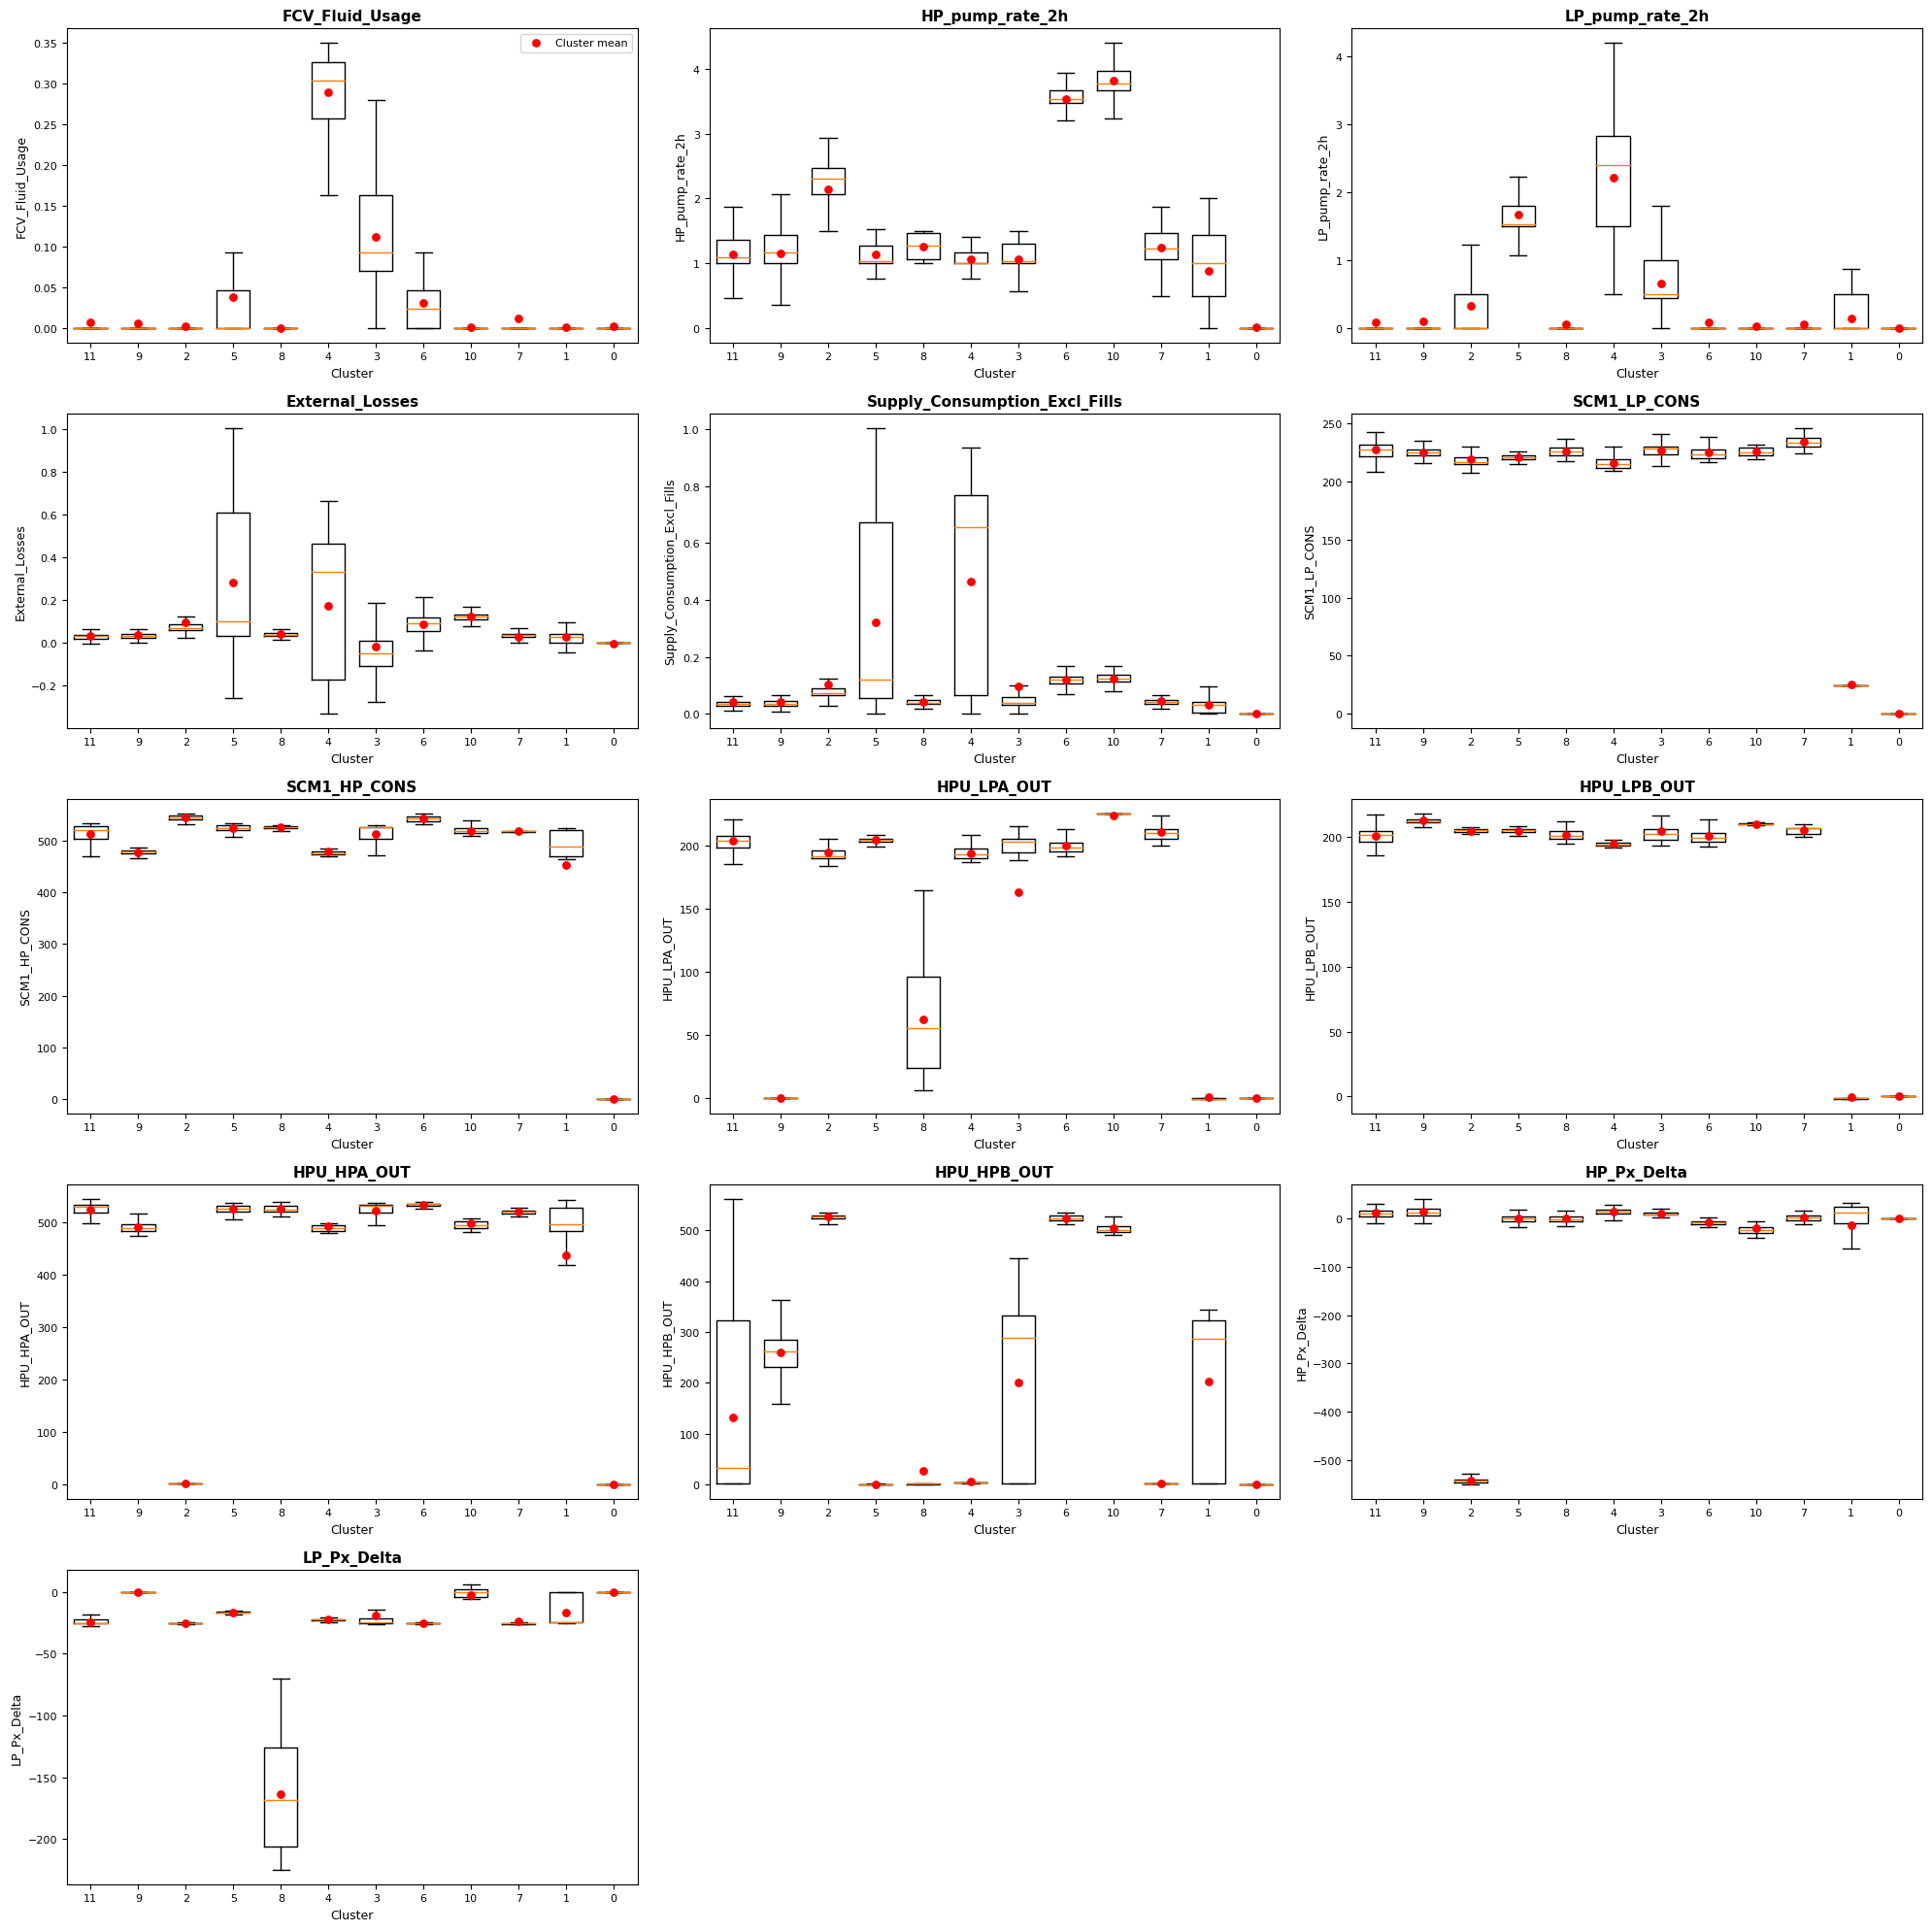

✅ Saved combined grid figure to: boxplots_by_cluster_grid\boxplots_grid_3wide_with_means.png


In [16]:

# Box whisker plots of the clusters features numeric data

# ----- Inputs -----
FEATURES = [
    "FCV_Fluid_Usage",
    "HP_pump_rate_2h","LP_pump_rate_2h",
    "External_Losses","Supply_Consumption_Excl_Fills",
    "SCM1_LP_CONS","SCM1_HP_CONS","HPU_LPA_OUT","HPU_LPB_OUT","HPU_HPA_OUT","HPU_HPB_OUT","HP_Px_Delta","LP_Px_Delta"
]
CLUSTER_COL_CANDIDATES = ["cluster_id", "cluster_hdbscan"]
EXCLUDE_NOISE = True
SHOW_FLIERS = False
MAX_PER_CLUSTER = 20000
SAVE_DIR = "boxplots_by_cluster_grid"

# Styling
BOX_WIDTH = 0.7
N_COLS = 3
FIG_W = 20
FIG_H_PER_ROW = 4
MEAN_MARKER_SIZE = 28

# ----- Cluster column detection -----
cluster_col = next((c for c in CLUSTER_COL_CANDIDATES if c in df_15_feat.columns), None)
assert cluster_col is not None, "No cluster column found (expected 'cluster_id' or 'cluster_hdbscan')."

# ----- Working frame -----
dfp = df_15_feat.copy()
if EXCLUDE_NOISE:
    dfp = dfp[dfp[cluster_col] != -1]

# Restrict to features that exist
use_feats = [c for c in FEATURES if c in dfp.columns]
assert len(use_feats) > 0, "None of the requested FEATURES exist in dataframe."

# Cluster order by size (largest first)
order = dfp[cluster_col].value_counts().index.tolist()

# Ensure output directory
os.makedirs(SAVE_DIR, exist_ok=True)

def _prep_arrays_for_boxplot(frame, col, order, max_per_cluster=None):
    arrays, labels, means = [], [], []
    for cid in order:
        vals = pd.to_numeric(frame.loc[frame[cluster_col]==cid, col], errors="coerce").dropna().values
        if max_per_cluster and vals.size > max_per_cluster:
            idx = np.random.choice(vals.size, size=max_per_cluster, replace=False)
            vals = vals[idx]
        if vals.size > 0:
            arrays.append(vals)
            labels.append(str(cid))
            means.append(float(np.mean(vals)))
    return arrays, labels, means

# ----- Plot 3 per row -----
n_feats = len(use_feats)
n_rows = int(np.ceil(n_feats / N_COLS))
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(FIG_W, FIG_H_PER_ROW * n_rows))
axes = axes.flatten()

for i, col in enumerate(use_feats):
    arrays, labels, means = _prep_arrays_for_boxplot(dfp, col, order, MAX_PER_CLUSTER)
    ax = axes[i]

    # Box plot
    bp = ax.boxplot(
        arrays,
        labels=labels,
        showfliers=SHOW_FLIERS,
        widths=BOX_WIDTH
    )

    # Overlay cluster means as red dots
    x_pos = np.arange(1, len(means) + 1)
    ax.scatter(x_pos, means, s=MEAN_MARKER_SIZE, c="red", marker="o", zorder=3, label="Cluster mean")

    # Cosmetics
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel("Cluster", fontsize=9)
    ax.set_ylabel(col, fontsize=9)
    ax.tick_params(axis='x', labelrotation=0, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    # Only add legend once
    if i == 0:
        ax.legend(loc="upper right", fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Save figure
out_path = os.path.join(SAVE_DIR, "boxplots_grid_3wide_with_means.png")
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"✅ Saved combined grid figure to: {out_path}")


📊 Mean values per cluster:


,FCV_Fluid_Usage,HP_pump_rate_2h,LP_pump_rate_2h,External_Losses,Supply_Consumption_Excl_Fills,SCM1_LP_CONS,SCM1_HP_CONS,HPU_LPA_OUT,HPU_LPB_OUT,HPU_HPA_OUT,HPU_HPB_OUT,HP_Px_Delta,LP_Px_Delta
cluster_id,,,,,,,,,,,,,
-1,0.058,1.171,0.805,0.124,0.205,215.118,479.733,173.754,192.293,479.886,136.373,0.153,-20.163
0,0.002,0.010,0.000,-0.002,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.001,0.882,0.149,0.028,0.030,25.186,451.857,1.093,-0.368,437.194,202.000,-14.663,-17.027
2,0.002,2.138,0.332,0.099,0.101,219.659,544.678,194.178,204.906,1.150,526.392,-543.528,-25.480
3,0.112,1.067,0.651,-0.017,0.095,226.983,512.327,163.201,204.257,522.222,201.486,9.895,-19.066
4,0.289,1.062,2.210,0.176,0.465,216.162,479.328,193.768,195.047,493.448,6.369,14.120,-22.394
5,0.038,1.135,1.671,0.285,0.323,221.044,524.292,204.130,204.831,525.296,0.808,1.004,-16.914
6,0.031,3.531,0.082,0.089,0.120,224.759,542.425,199.462,200.490,533.914,523.716,-8.511,-25.297
7,0.012,1.246,0.059,0.031,0.043,234.200,518.617,210.694,205.608,519.740,1.191,1.123,-23.506


🧭 Relative (per-feature) classification of clusters:


,FCV_Fluid_Usage,HP_pump_rate_2h,LP_pump_rate_2h,External_Losses,Supply_Consumption_Excl_Fills,SCM1_LP_CONS,SCM1_HP_CONS,HPU_LPA_OUT,HPU_LPB_OUT,HPU_HPA_OUT,HPU_HPB_OUT,HP_Px_Delta,LP_Px_Delta
cluster_id,,,,,,,,,,,,,
-1,Low,Low,Medium,Medium,Medium,High,High,High,High,High,Low,High,High
0,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,High,High
1,Low,Low,Low,Low,Low,Low,High,Low,Low,High,Medium,High,High
2,Low,Medium,Low,Medium,Low,High,High,High,High,Low,High,Low,High
3,Medium,Low,Low,Low,Low,High,High,High,High,High,Medium,High,High
4,High,Low,High,Medium,High,High,High,High,High,High,Low,High,High
5,Low,Low,High,High,High,High,High,High,High,High,Low,High,High
6,Low,High,Low,Medium,Low,High,High,High,High,High,High,High,High
7,Low,Low,Low,Low,Low,High,High,High,High,High,Low,High,High


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
FCV_Fluid_Usage,140257.0,0.019765,0.055752,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.046667,0.116667,0.303333,0.35000
HP_pump_rate_2h,140257.0,1.199624,0.547137,0.000000,0.000000,0.500000,0.800000,1.000000,1.133333,1.400000,1.500000,1.500000,3.700000,8.50000
LP_pump_rate_2h,140257.0,0.270984,0.607991,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.600000,1.500000,2.933333,6.50000
External_Losses,140257.0,0.056873,0.171850,-5.206794,-0.185471,-0.044521,-0.006646,0.018736,0.032666,0.045375,0.095247,0.331180,0.701348,10.59006
Supply_Consumption_Excl_Fills,140257.0,0.080817,0.224252,0.000000,0.000000,0.001857,0.016259,0.029162,0.034881,0.049428,0.111668,0.417084,0.782875,11.92884
SCM1_LP_CONS,140257.0,222.852968,28.377126,0.000000,24.000000,214.817355,218.000000,221.045149,227.000000,231.000000,235.000000,237.000000,241.000000,261.72479
SCM1_HP_CONS,140257.0,500.656501,59.369774,0.000000,154.292214,466.000000,474.000000,484.000000,517.000000,526.000000,529.000000,531.000000,547.000000,552.00000


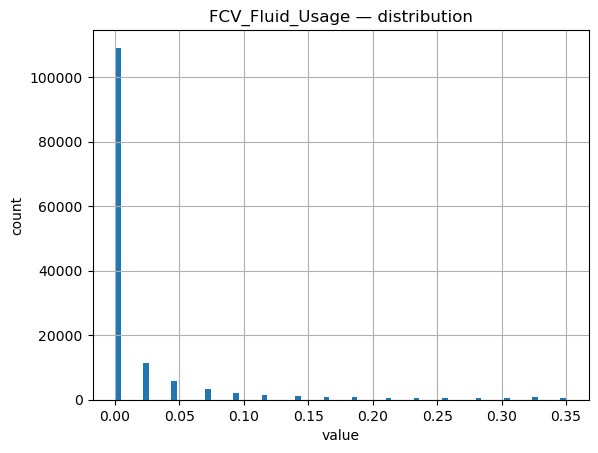

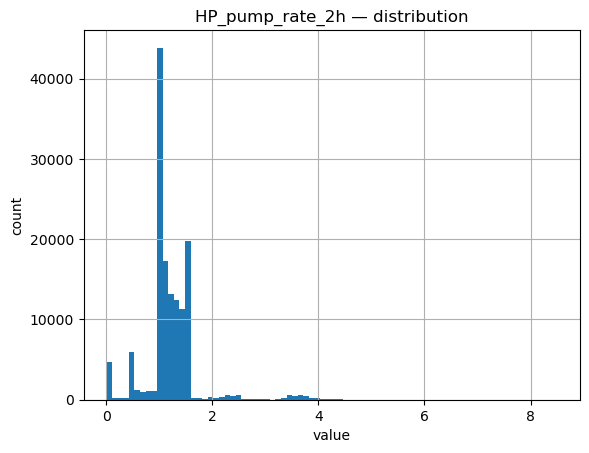

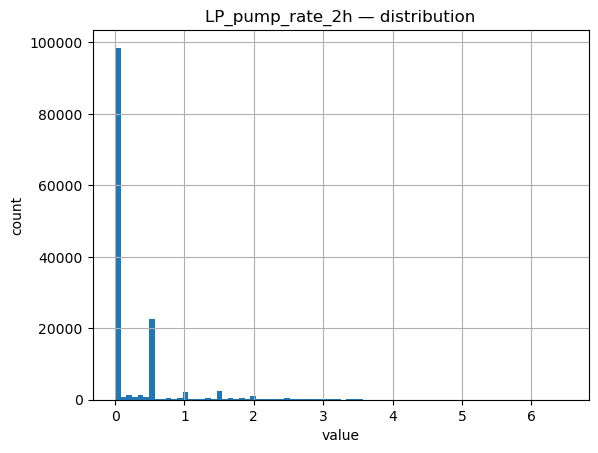

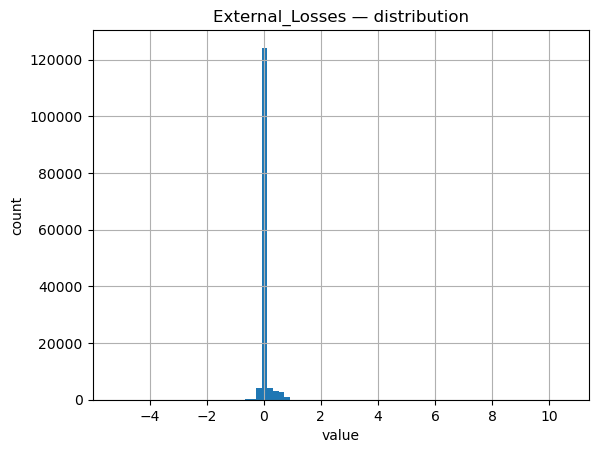

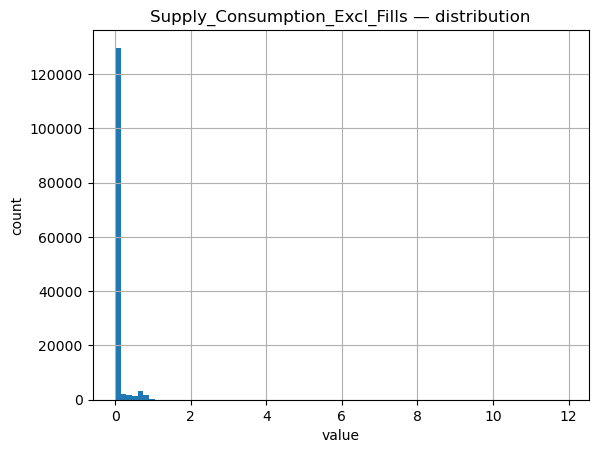

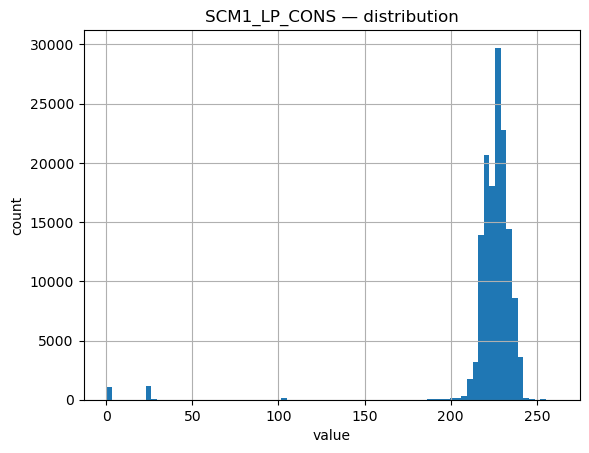

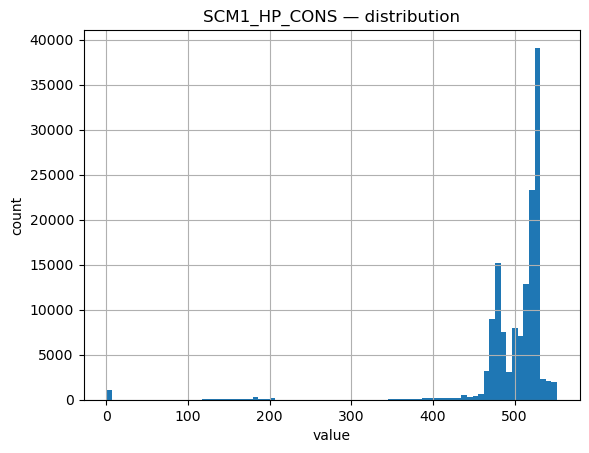

SUPPLY_LO   : 0.0019
LOSSES_TH   : 0.3312
HP_TH       : 1.5000
LP_TH       : 0.6000
FCV_TH      : 0.1167
DEP_CONS_TH : 466.0000


In [17]:
# ---  Cluster Evlauation using numeric features to understand operating regime---
CLUSTER_COL = "cluster_id" if "cluster_id" in df_15_feat.columns else "cluster_kmeans"
assert CLUSTER_COL in df_15_feat.columns, "No cluster column found. Run HDBSCAN or KMeans first."

REGIME_FEATURES_TO_DESCRIBE = [
    "FCV_Fluid_Usage",
    "HP_pump_rate_2h","LP_pump_rate_2h",
    "External_Losses","Supply_Consumption_Excl_Fills",
    "SCM1_LP_CONS","SCM1_HP_CONS","HPU_LPA_OUT","HPU_LPB_OUT","HPU_HPA_OUT","HPU_HPB_OUT","HP_Px_Delta","LP_Px_Delta"
]

# keep only valid columns
valid_features = [c for c in REGIME_FEATURES_TO_DESCRIBE if c in df_15_feat.columns]

# compute cluster means
cluster_means = (
    df_15_feat.groupby(CLUSTER_COL)[valid_features]
    .mean()
    .sort_index()
)

print("📊 Mean values per cluster:")
display(cluster_means.round(3))

# --- Classify each feature per-cluster relative to that feature's min/max ---
cluster_class = cluster_means.copy()

for col in valid_features:
    vals = cluster_means[col]
    vmin, vmax = vals.min(), vals.max()
    
    if vmax == vmin:
        cluster_class[col] = "Medium"  # all equal
        continue
    
    # normalize 0–1
    scaled = (vals - vmin) / (vmax - vmin)
    
    # thresholds
    cluster_class[col] = pd.cut(
        scaled,
        bins=[-0.01, 0.33, 0.66, 1.01],
        labels=["Low", "Medium", "High"]
    )

print("🧭 Relative (per-feature) classification of clusters:")
display(cluster_class)

cols = [
    "FCV_Fluid_Usage",
    "HP_pump_rate_2h",
    "LP_pump_rate_2h",
    "External_Losses",
    "Supply_Consumption_Excl_Fills",
    "SCM1_LP_CONS",
    "SCM1_HP_CONS"
]

stats = df_15_feat[cols].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T
display(stats)
import matplotlib.pyplot as plt

for c in cols:
    plt.figure()
    df_15_feat[c].hist(bins=80)
    plt.title(f"{c} — distribution")
    plt.xlabel("value")
    plt.ylabel("count")
    plt.show()

thresholds = {
    "SUPPLY_LO": df_15_feat["Supply_Consumption_Excl_Fills"].quantile(0.05),
    "LOSSES_TH": df_15_feat["External_Losses"].quantile(0.95),
    "HP_TH": df_15_feat["HP_pump_rate_2h"].quantile(0.90),
    "LP_TH": df_15_feat["LP_pump_rate_2h"].quantile(0.90),
    "FCV_TH": df_15_feat["FCV_Fluid_Usage"].quantile(0.95),
    "DEP_CONS_TH": max(
        df_15_feat["SCM1_LP_CONS"].quantile(0.05),
        df_15_feat["SCM1_HP_CONS"].quantile(0.05),
    ),
}

for k, v in thresholds.items():
    print(f"{k:<12}: {v:.4f}")

###### Operating Regime Criteria Rules

| **Operating Regime** | **Condition / Rule** |
|:----------------------|:---------------------|
| **Steady State** | Supply consumption (excluding fills) is **low** and external losses are **low**. |
| **LP System Losses** | External losses are **high**, LP pump rate is **high**, and HP pump rate is **low**. |
| **HP System Losses** | External losses are **high**, HP pump rate is **high**, and LP pump rate is **low**. |
| **System Depressurised** | Both LP and HP pressure sensors read **~0 bar**. |
| **FCV Operation** | FCV fluid usage is **greater than high threshold** (indicating valve actuation). |


the Next section wilL evaluate operatinal thresholds to define the HIGHS and LOWS



,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
FCV_Fluid_Usage,140257.0,0.019765,0.055752,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.046667,0.116667,0.303333,0.35000
HP_pump_rate_2h,140257.0,1.199624,0.547137,0.000000,0.000000,0.500000,0.800000,1.000000,1.133333,1.400000,1.500000,1.500000,3.700000,8.50000
LP_pump_rate_2h,140257.0,0.270984,0.607991,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.600000,1.500000,2.933333,6.50000
External_Losses,140257.0,0.056873,0.171850,-5.206794,-0.185471,-0.044521,-0.006646,0.018736,0.032666,0.045375,0.095247,0.331180,0.701348,10.59006
Supply_Consumption_Excl_Fills,140257.0,0.080817,0.224252,0.000000,0.000000,0.001857,0.016259,0.029162,0.034881,0.049428,0.111668,0.417084,0.782875,11.92884
SCM1_LP_CONS,140257.0,222.852968,28.377126,0.000000,24.000000,214.817355,218.000000,221.045149,227.000000,231.000000,235.000000,237.000000,241.000000,261.72479
SCM1_HP_CONS,140257.0,500.656501,59.369774,0.000000,154.292214,466.000000,474.000000,484.000000,517.000000,526.000000,529.000000,531.000000,547.000000,552.00000


SUPPLY_LO   : 0.0019
LOSSES_TH   : 0.3312
HP_TH       : 1.5000
LP_TH       : 0.6000
FCV_TH      : 0.1167
DEP_CONS_TH : 466.0000


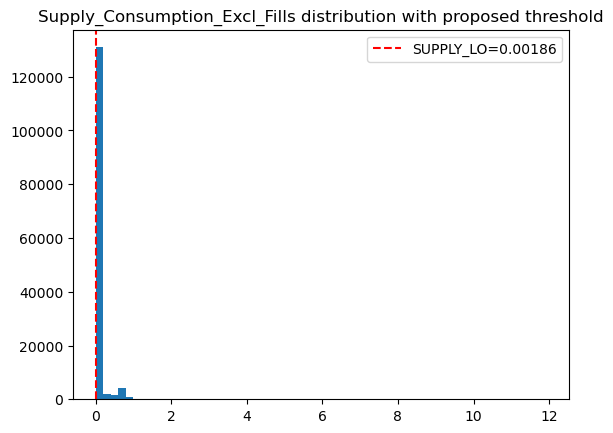

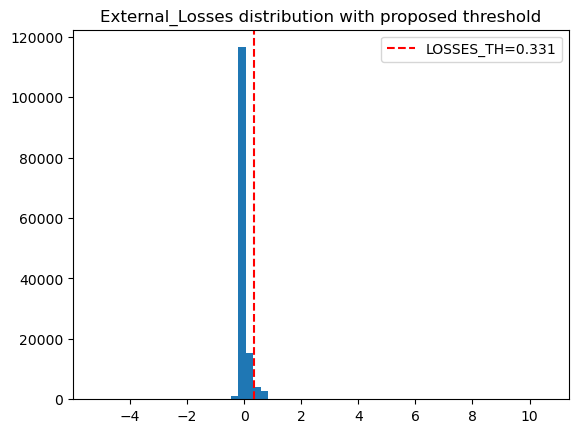

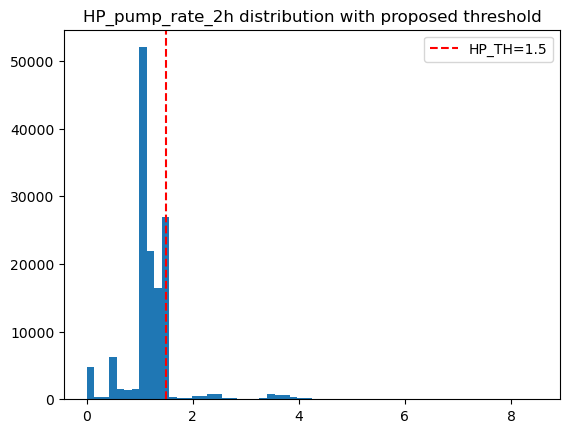

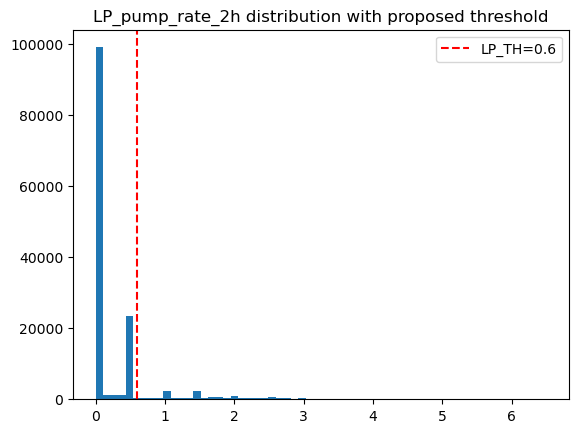

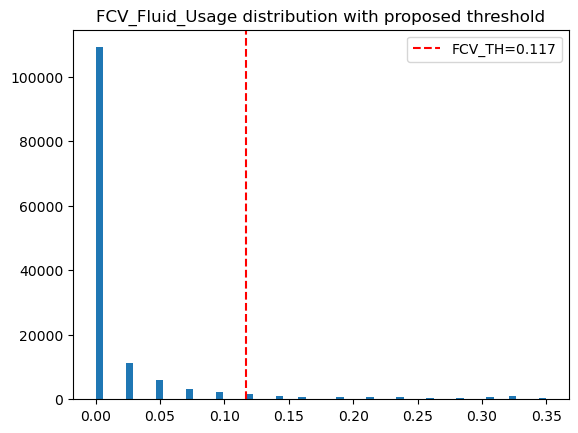

In [18]:
# Evalaute percentiles of selected features

cols = [
    "FCV_Fluid_Usage",
    "HP_pump_rate_2h",
    "LP_pump_rate_2h",
    "External_Losses",
    "Supply_Consumption_Excl_Fills",
    "SCM1_LP_CONS",
    "SCM1_HP_CONS",
]

# 1️⃣  Summary statistics for reasoning about limits
stats = df_15_feat[cols].describe(percentiles=[0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99]).T
display(stats)

# 2️⃣  Quantile-based candidate thresholds
thresholds = {
    "SUPPLY_LO": df_15_feat["Supply_Consumption_Excl_Fills"].quantile(0.05),
    "LOSSES_TH": df_15_feat["External_Losses"].quantile(0.95),
    "HP_TH":      df_15_feat["HP_pump_rate_2h"].quantile(0.90),
    "LP_TH":      df_15_feat["LP_pump_rate_2h"].quantile(0.90),
    "FCV_TH":     df_15_feat["FCV_Fluid_Usage"].quantile(0.95),
    "DEP_CONS_TH": max(
        df_15_feat["SCM1_LP_CONS"].quantile(0.05),
        df_15_feat["SCM1_HP_CONS"].quantile(0.05),
    ),
}
for k,v in thresholds.items():
    print(f"{k:<12}: {v:.4f}")

# 3️⃣  Visual check
for k,v in thresholds.items():
    # match a column name by keyword
    f = [c for c in cols if k.split("_")[0].lower() in c.lower()]
    if f:
        f = f[0]
        plt.figure()
        plt.hist(df_15_feat[f], bins=60)
        plt.axvline(v, color="r", linestyle="--", label=f"{k}={v:.3g}")
        plt.title(f"{f} distribution with proposed threshold")
        plt.legend(); plt.show() 

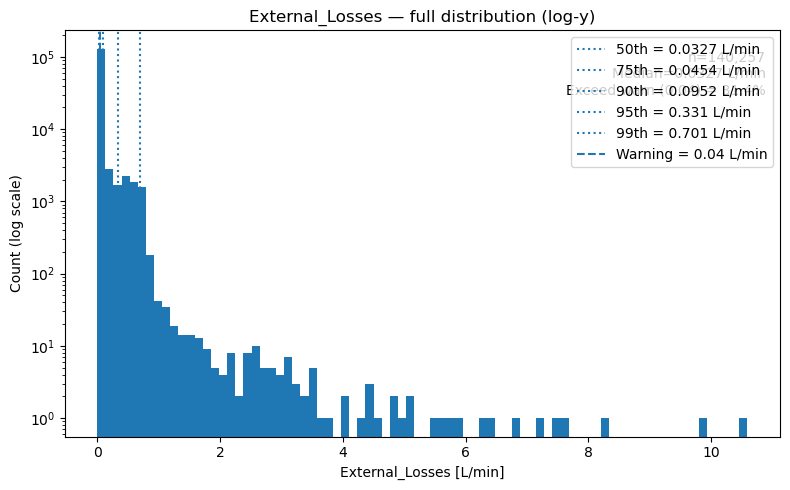

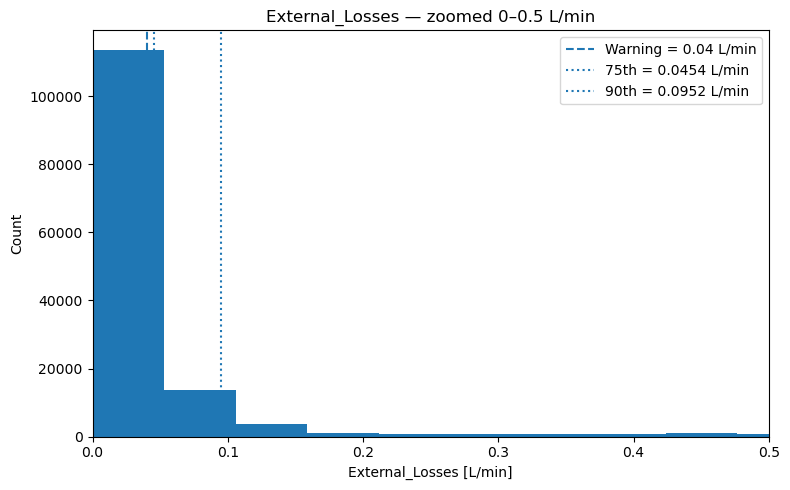

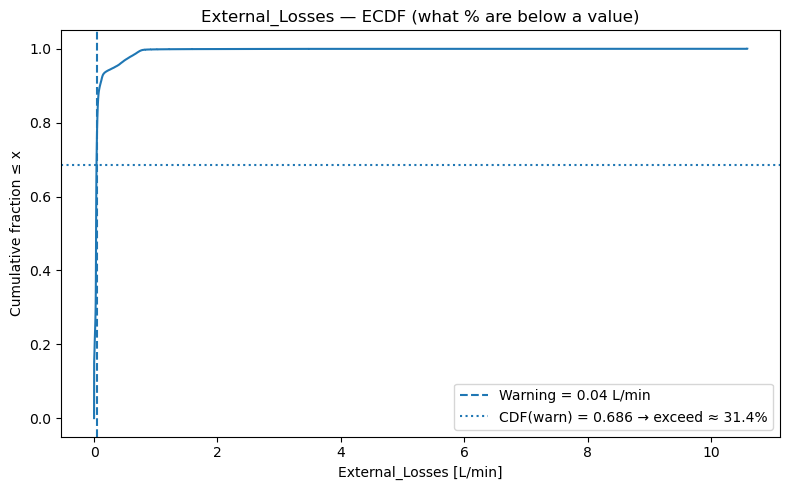

In [19]:
# Evalaute External Losses threshold for normal operation.

def plot_external_losses_readable(
    s: pd.Series,
    warn_th: float = 0.04,              # proposed warning threshold (L/min)
    zoom_max: float = 0.5,              # x-limit for the zoomed view (L/min)
    bins_full: int = 80,
    bins_zoom: int = 200,
):
    """
    Make readable plots for External_Losses (L/min):
      1) Full histogram with log-y and annotated quantiles
      2) Zoomed histogram (0–zoom_max L/min) with thresholds
      3) ECDF to show exceedance probabilities
    """
    # --- Clean & basic stats
    x = pd.to_numeric(s, errors="coerce").clip(lower=0).replace([np.inf, -np.inf], np.nan).dropna()
    if x.empty:
        raise ValueError("Series is empty after cleaning.")

    qs = x.quantile([0.50, 0.75, 0.90, 0.95, 0.99])
    q50, q75, q90, q95, q99 = qs.values

    pct_above_warn = (x > warn_th).mean() * 100.0
    pct_above_q90  = (x > q90).mean() * 100.0
    n = len(x)

    # -------- 1) Full histogram (log y) --------
    plt.figure(figsize=(8, 5))
    plt.hist(x, bins=bins_full, log=True)
    # vertical lines (median and higher quantiles)
    for qv, label in [(q50, "50th"), (q75, "75th"), (q90, "90th"), (q95, "95th"), (q99, "99th")]:
        plt.axvline(qv, linestyle=":", label=f"{label} = {qv:.3g} L/min")
    plt.axvline(warn_th, linestyle="--", label=f"Warning = {warn_th:.3g} L/min")

    plt.title("External_Losses — full distribution (log-y)")
    plt.xlabel("External_Losses [L/min]")
    plt.ylabel("Count (log scale)")
    plt.legend(loc="best")
    # helpful note
    txt = (f"n={n:,}\n"
           f"Median={q50:.3g} L/min\n"
           f"Exceed warn ({warn_th:.3g}) = {pct_above_warn:.1f}%")
    plt.gca().text(0.98, 0.95, txt, ha="right", va="top", transform=plt.gca().transAxes)
    plt.tight_layout()
    plt.show()

    # -------- 2) Zoomed histogram (linear y) --------
    plt.figure(figsize=(8, 5))
    plt.hist(x, bins=bins_zoom)
    plt.axvline(warn_th, linestyle="--", label=f"Warning = {warn_th:.3g} L/min")
    plt.axvline(q75, linestyle=":", label=f"75th = {q75:.3g} L/min")
    plt.axvline(q90, linestyle=":", label=f"90th = {q90:.3g} L/min")
    plt.xlim(0, zoom_max)
    plt.title(f"External_Losses — zoomed 0–{zoom_max} L/min")
    plt.xlabel("External_Losses [L/min]")
    plt.ylabel("Count")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

    # -------- 3) ECDF (exceedance view) --------
    x_sorted = np.sort(x.values)
    y = np.arange(1, n + 1) / n   # CDF
    plt.figure(figsize=(8, 5))
    plt.plot(x_sorted, y, drawstyle="steps-post")
    plt.axvline(warn_th, linestyle="--", label=f"Warning = {warn_th:.3g} L/min")
    # annotate exceedance at warn_th
    cdf_at_warn = (x <= warn_th).mean()
    plt.axhline(cdf_at_warn, linestyle=":", label=f"CDF(warn) = {cdf_at_warn:.3f} → exceed ≈ {100*(1-cdf_at_warn):.1f}%")

    plt.title("External_Losses — ECDF (what % are below a value)")
    plt.xlabel("External_Losses [L/min]")
    plt.ylabel("Cumulative fraction ≤ x")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


# --- Use it:
plot_external_losses_readable(df_15_feat["External_Losses"], warn_th=0.04, zoom_max=0.5)


External Losses Normal operation corresponds to very small external losses (≈ 0–0.03 L/min).
Values above 0.04 L/min are relatively rare but not extreme — a sensible early-warning level that flags the start of abnormal behaviour 
About three-quarters of your data lie below 0.045 L/min.
The system exceeds 0.04 L/min roughly one-third of the time.


HP_pump_rate_2h quantiles [L/min]
  50th: 1.133
  75th: 1.4
  90th: 1.5  <-- proposed high cut
  95th: 1.5
  99th: 3.7
Exceedance above 90th (1.5): 4.88%  (n=140,257)


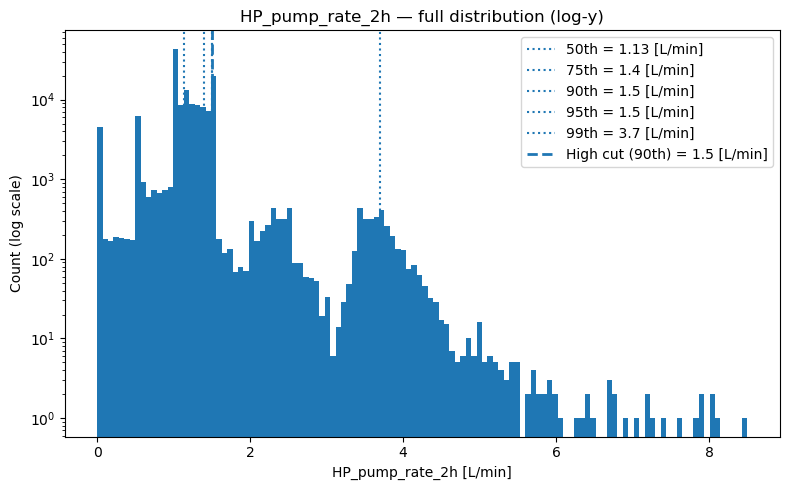

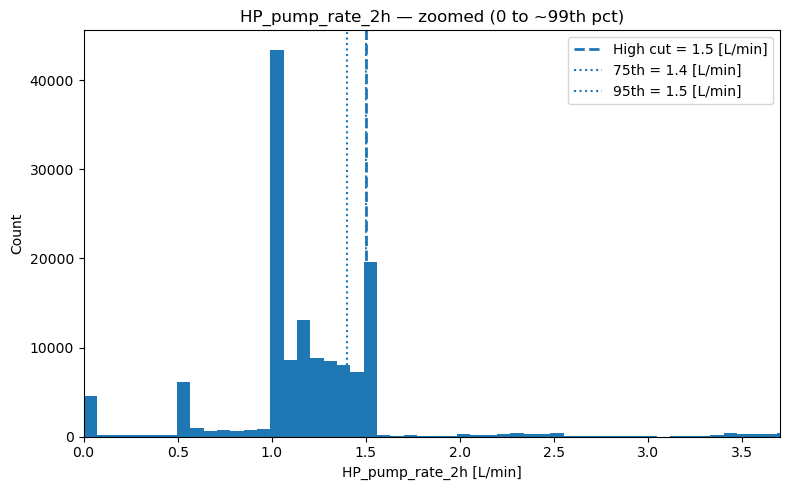

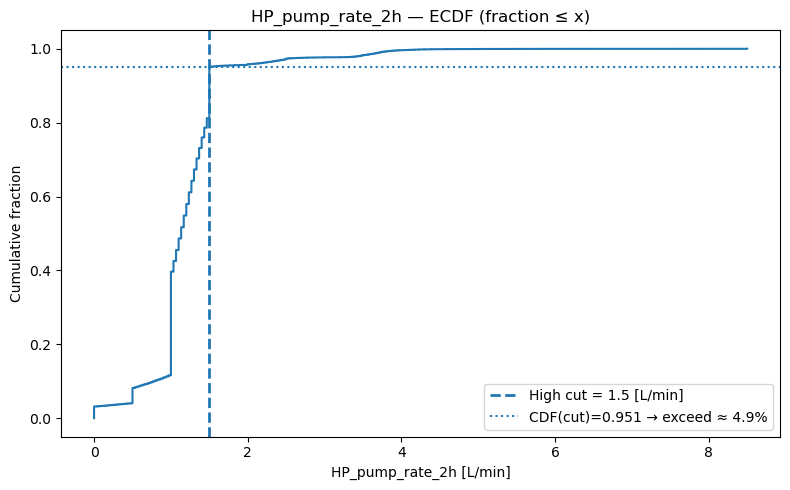


LP_pump_rate_2h quantiles [L/min]
  50th: 0
  75th: 0.5
  90th: 0.6  <-- proposed high cut
  95th: 1.5
  99th: 2.933
Exceedance above 90th (0.6): 9.93%  (n=140,257)


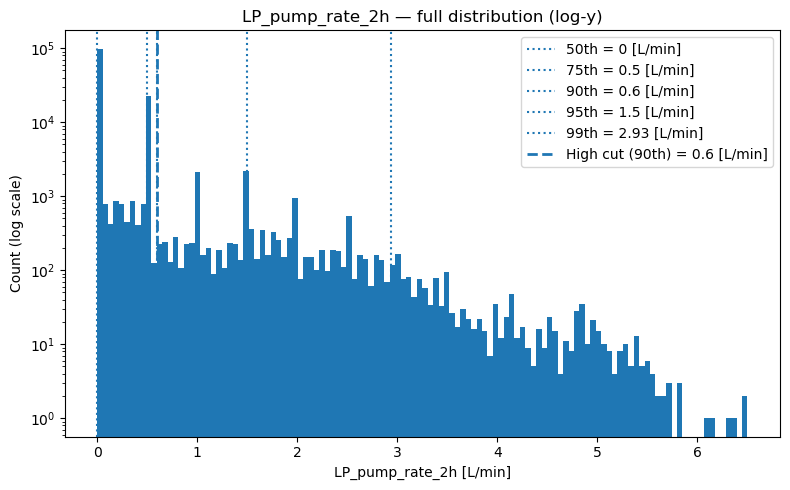

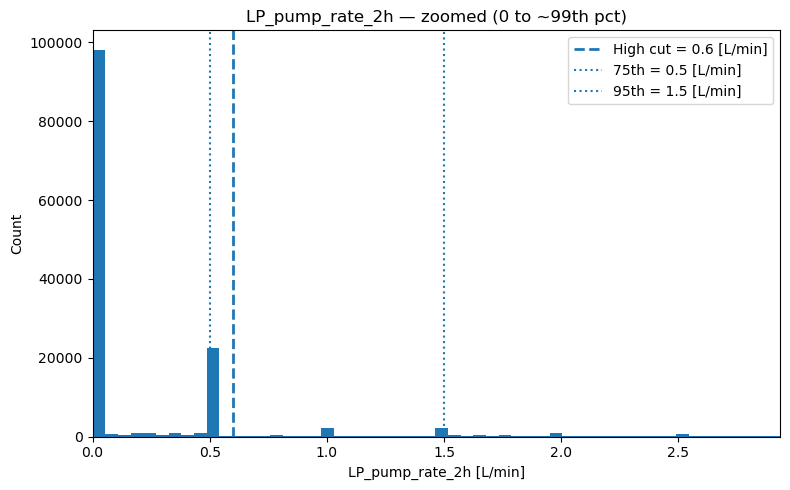

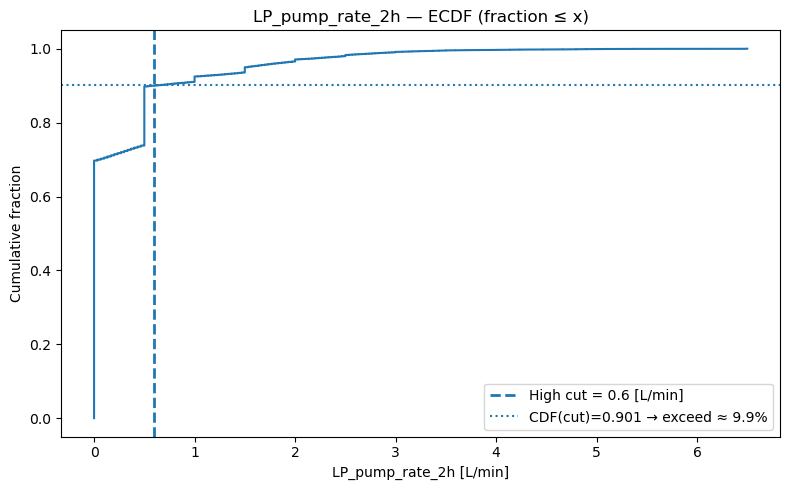

In [20]:
# Evaluate LP and HP Pump data. Proipsoed 90th percentile for the High cut offs 

def plot_high_cut_by_percentile(
    df: pd.DataFrame,
    col: str,
    q: float = 0.90,
    units: str = "[units]",     # e.g. "[L/min]" or "[L/h]"
    zoom_to: float | None = None,  # e.g.  p99 range; if None, auto to 99th pct
):
    x = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().values
    if x.size == 0:
        print(f"[skip] {col}: no numeric data")
        return

    # core stats
    qs = np.quantile(x, [0.50, 0.75, 0.90, 0.95, 0.99])
    q50, q75, q90, q95, q99 = qs
    thr = np.quantile(x, q)
    pct_above = (x > thr).mean() * 100
    n = len(x)

    # print table to justify choice
    print(f"\n{col} quantiles {units}")
    print(f"  50th: {q50:.4g}")
    print(f"  75th: {q75:.4g}")
    print(f"  90th: {q90:.4g}  <-- proposed high cut")
    print(f"  95th: {q95:.4g}")
    print(f"  99th: {q99:.4g}")
    print(f"Exceedance above {int(q*100)}th ({thr:.4g}): {pct_above:.2f}%  (n={n:,})")

    # 1) Full histogram (log-y) with quantile lines
    plt.figure(figsize=(8,5))
    bins = min(120, max(30, int(np.sqrt(n))))
    plt.hist(x, bins=bins, log=True)
    for qv, label in [(q50,"50th"), (q75,"75th"), (q90,"90th"), (q95,"95th"), (q99,"99th")]:
        plt.axvline(qv, linestyle=":", label=f"{label} = {qv:.3g} {units}")
    plt.axvline(thr, linestyle="--", linewidth=2, label=f"High cut ({int(q*100)}th) = {thr:.3g} {units}")
    plt.title(f"{col} — full distribution (log-y)")
    plt.xlabel(f"{col} {units}"); plt.ylabel("Count (log scale)")
    plt.legend(loc="best"); plt.tight_layout(); plt.show()

    # 2) Zoomed histogram (linear y) around the interesting range
    xlim_max = zoom_to if zoom_to is not None else q99
    plt.figure(figsize=(8,5))
    plt.hist(x, bins=bins)
    plt.axvline(thr, linestyle="--", linewidth=2, label=f"High cut = {thr:.3g} {units}")
    plt.axvline(q75, linestyle=":", label=f"75th = {q75:.3g} {units}")
    plt.axvline(q95, linestyle=":", label=f"95th = {q95:.3g} {units}")
    plt.xlim(left=0, right=max(xlim_max, thr*1.1))
    plt.title(f"{col} — zoomed (0 to ~99th pct)")
    plt.xlabel(f"{col} {units}"); plt.ylabel("Count")
    plt.legend(loc="best"); plt.tight_layout(); plt.show()

    # 3) ECDF (shows how often you exceed the cut)
    x_sorted = np.sort(x)
    y = np.arange(1, n+1) / n
    plt.figure(figsize=(8,5))
    plt.plot(x_sorted, y, drawstyle="steps-post")
    plt.axvline(thr, linestyle="--", linewidth=2, label=f"High cut = {thr:.3g} {units}")
    cdf_at_thr = (x <= thr).mean()
    plt.axhline(cdf_at_thr, linestyle=":", label=f"CDF(cut)={cdf_at_thr:.3f} → exceed ≈ {(1-cdf_at_thr)*100:.1f}%")
    plt.title(f"{col} — ECDF (fraction ≤ x)")
    plt.xlabel(f"{col} {units}"); plt.ylabel("Cumulative fraction")
    plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

# --- Run for HP and LP pumps (set your units if known)
plot_high_cut_by_percentile(df_15_feat, "HP_pump_rate_2h", q=0.90, units="[L/min]")
plot_high_cut_by_percentile(df_15_feat, "LP_pump_rate_2h", q=0.90, units="[L/min]")


HP Pump rate distribution is heavily concentrated between 1.0–1.5 L/min, then rapidly falls off. Beyond 1.5 L/min, very few samples exist (only ~5 % exceed). 1.5 L/min a natural separation between “normal load” and “elevated pump activity.”

LP Pump rate ends most of its time off or near zero, occasionally running up to 0.5 L/min. Only about 10 % of readings exceed 0.6 L/min, making that a clear cut-off for “high activity. Therre is actaully a differnce between 0.6 then 1.5 where it is extremely high. 


FCV_Fluid_Usage quantiles [L/min]
  50th: 0
  75th: 0
  90th: 0.04667
  95th: 0.1167
  99th: 0.3033
Threshold = 0.2 [L/min]  →  rank ≈ P97.0,  %above = 2.99%  (n=140,257)


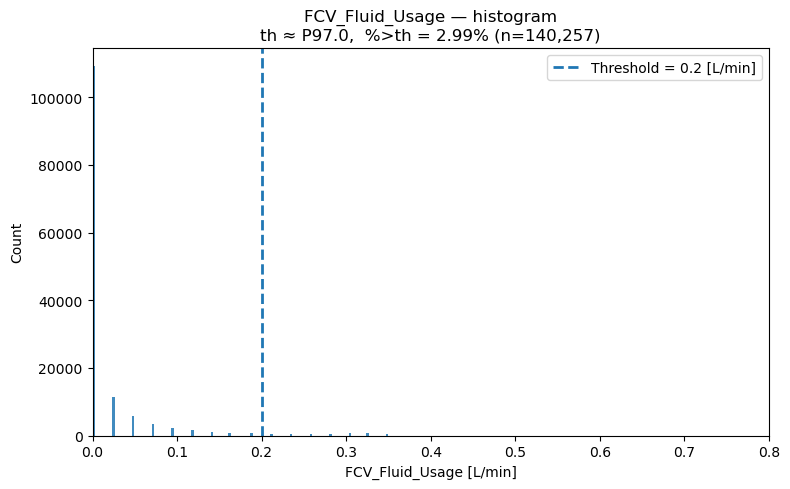

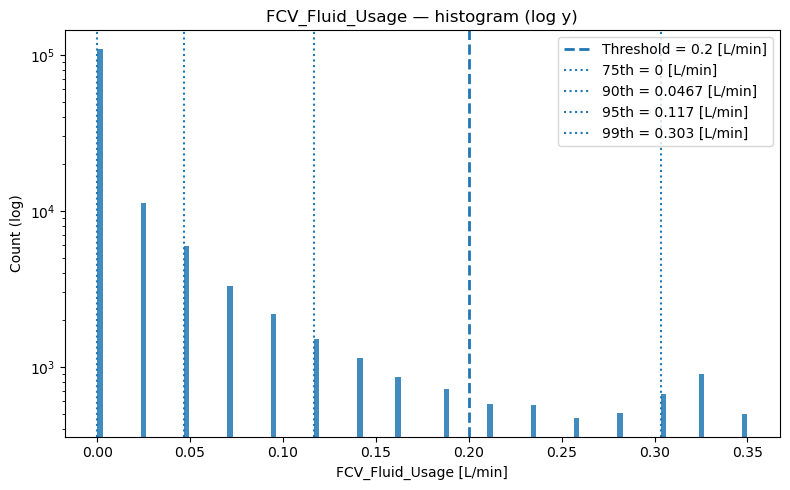

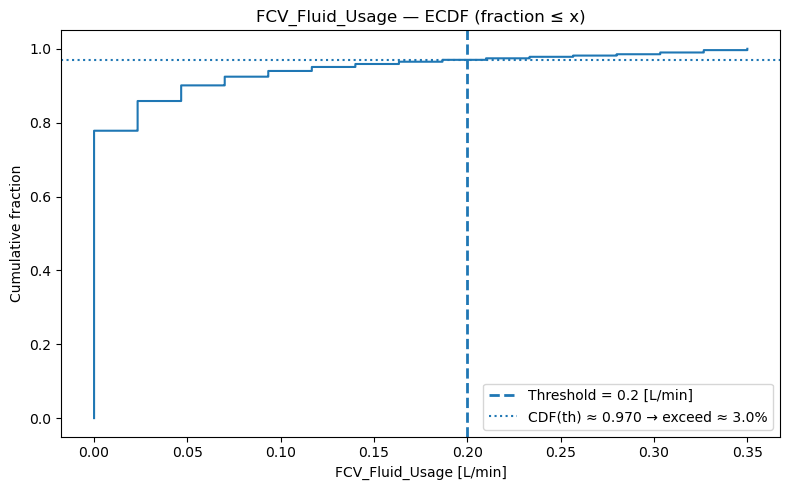

Episodes ≥ 0.2 [L/min]: 1115 total
  duration (min): mean=3.76, median=1.00, p90=9.00, max=143.00


In [21]:
#Evaluate FCV Usage 

def analyze_fcv_usage(
    s: pd.Series,
    threshold: float = 0.20,
    units: str = "[L/min]",
    sample_period_min: float | None = None,   # e.g., 1.0 if sampled every minute
    zoom_max: float | None = None,           # e.g., 0.8 to zoom near the threshold
):
    """
    Analyze FCV_Fluid_Usage:
      - quantiles + percentile rank of the threshold & exceedance %
      - histogram (linear y)
      - histogram (log y)
      - ECDF with percentile line
      - optional run/episode stats above the threshold

    Notes:
      - Uses default matplotlib colors (one chart per figure).
      - Cleans to numeric, clips negatives to zero.
    """
    # --- clean series
    x = pd.to_numeric(s, errors="coerce").clip(lower=0).replace([np.inf, -np.inf], np.nan).dropna().values
    n = x.size
    if n == 0:
        print("[analyze_fcv_usage] No numeric data.")
        return

    # --- quantiles & threshold stats
    qs = np.quantile(x, [0.50, 0.75, 0.90, 0.95, 0.99])
    q50, q75, q90, q95, q99 = qs
    thr = float(threshold)
    pct_above = (x > thr).mean() * 100.0
    prank = (x <= thr).mean() * 100.0  # percentile rank of the threshold

    print("\nFCV_Fluid_Usage quantiles", units)
    print(f"  50th: {q50:.4g}")
    print(f"  75th: {q75:.4g}")
    print(f"  90th: {q90:.4g}")
    print(f"  95th: {q95:.4g}")
    print(f"  99th: {q99:.4g}")
    print(f"Threshold = {thr:.4g} {units}  →  rank ≈ P{prank:.1f},  %above = {pct_above:.2f}%  (n={n:,})")

    # --- bin heuristic
    bins = int(np.clip(np.sqrt(n), 30, 120))

    # 1) Histogram (linear y)
    plt.figure(figsize=(8,5))
    plt.hist(x, bins=bins, alpha=0.85)
    plt.axvline(thr, linestyle="--", linewidth=2, label=f"Threshold = {thr:.3g} {units}")
    if zoom_max is not None:
        plt.xlim(0, zoom_max)
    plt.title(f"FCV_Fluid_Usage — histogram\nth ≈ P{prank:.1f},  %>th = {pct_above:.2f}% (n={n:,})")
    plt.xlabel(f"FCV_Fluid_Usage {units}"); plt.ylabel("Count"); plt.legend(); plt.tight_layout(); plt.show()

    # 2) Histogram (log y) to expose tail
    plt.figure(figsize=(8,5))
    plt.hist(x, bins=bins, alpha=0.85)
    plt.yscale("log")
    plt.axvline(thr, linestyle="--", linewidth=2, label=f"Threshold = {thr:.3g} {units}")
    # annotate a few quantiles
    for qv, lab in [(q75, "75th"), (q90, "90th"), (q95, "95th"), (q99, "99th")]:
        plt.axvline(qv, linestyle=":", label=f"{lab} = {qv:.3g} {units}")
    plt.title("FCV_Fluid_Usage — histogram (log y)")
    plt.xlabel(f"FCV_Fluid_Usage {units}"); plt.ylabel("Count (log)"); plt.legend(loc="best"); plt.tight_layout(); plt.show()

    # 3) ECDF with percentile marker
    xs = np.sort(x)
    ecdf = np.arange(1, n+1) / n
    plt.figure(figsize=(8,5))
    plt.plot(xs, ecdf, drawstyle="steps-post")
    plt.axvline(thr, linestyle="--", linewidth=2, label=f"Threshold = {thr:.3g} {units}")
    plt.axhline((x <= thr).mean(), linestyle=":", label=f"CDF(th) ≈ {prank/100:.3f} → exceed ≈ {pct_above:.1f}%")
    plt.title("FCV_Fluid_Usage — ECDF (fraction ≤ x)")
    plt.xlabel(f"FCV_Fluid_Usage {units}"); plt.ylabel("Cumulative fraction"); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

    # 4) Optional: run/episode metrics above threshold
    if sample_period_min is not None:
        mask = x >= thr
        # start/end indices of contiguous segments
        starts = np.flatnonzero(mask & np.r_[True, ~mask[:-1]])
        ends   = np.flatnonzero(mask & np.r_[~mask[1:], True])
        lengths = ends - starts + 1
        n_events = len(lengths)
        dur_min = lengths * float(sample_period_min)
        if n_events:
            print(f"Episodes ≥ {thr:.3g} {units}: {n_events} total")
            print(f"  duration (min): mean={dur_min.mean():.2f}, median={np.median(dur_min):.2f}, "
                  f"p90={np.quantile(dur_min,0.9):.2f}, max={dur_min.max():.2f}")
        else:
            print(f"Episodes ≥ {thr:.3g} {units}: 0")

# --- Use it:
FCV_TH = 0.20
analyze_fcv_usage(
    df_15_feat["FCV_Fluid_Usage"],
    threshold=FCV_TH,
    units="[L/min]",           # change if different
    sample_period_min=1.0,     # set your sampling period in minutes, or None to skip episode metrics
    zoom_max=0.8               # optional x-axis zoom for the dense region
)


FCV Fluid is almost always 0, 7%% percntile is 0 i.e inactive 3.4 of time. 
When is operating it is typcially between 0.05 and 0.2 l/min, htjis is noraml operation.
0.2 liter minute is very high and abnormal FCV operation to be alerted as an anomaly. 

##### CLUSTER LABELING RULES 

    STEADY: supply use is very low (≤ 0.041 L/min ≈ 59 L/day) and losses are not high.

    HP losses: external losses are high AND HP pump is high (in 90th percentile) AND LP pump is not high.

    LP losses: external losses are high AND LP pump is high (in 90th percentile) AND HP pump is not high.

    FCV operation: FCV usage is high (≥ 0.2).
    
    System depresuisred. SCM1_LP_CONS and SCM1_HP_CONS both less than 2 bar



In [22]:
# ==== Cluster state auto-detect df & cluster column ====



# 1) Pick the clustered DataFrame you actually have
df_candidates = [globals().get(n) for n in ["df_15_clusters", "frame", "out", "df_15_feat"]]
df_clust = next((d for d in df_candidates if isinstance(d, pd.DataFrame)), None)
assert df_clust is not None, "No clustered DataFrame found (looked for df_15_clusters, frame, out, df_15_feat)."

# 2) Pick the cluster label column that exists
cluster_col = "cluster_id" if "cluster_id" in df_clust.columns else \
              "cluster_hdbscan" if "cluster_hdbscan" in df_clust.columns else None
assert cluster_col is not None, "No cluster label column found (need 'cluster_id' or 'cluster_hdbscan')."

# 3) Thresholds (edit to your engineering limits as needed)
SUPPLY_LO = 0.041   # L/min ~ 59 L/day
LOSSES_TH = 0.04    # L/min (57l per day
FCV_TH    = 0.20

# New: depressurised condition threshold (strictly less than 2)
DEP_CONS_TH = 2.0   # L/min
# If SCM1_LP_CONS < 2 and SCM1_HP_CONS < 2 -> depressurised evidence

# Data-aware pump thresholds (or replace with fixed engineering limits)
HP_TH = df_clust["HP_pump_rate_2h"].quantile(0.90)
LP_TH = df_clust["LP_pump_rate_2h"].quantile(0.90)

# Added new prior for DEPRESSURISED (flat like others by default)
STATE_PRIORS = {
    "STEADY": 1,
    "LOSSES_HP": 1,
    "LOSSES_LP": 1,
    "FCV_OPS": 1,
    "DEPRESSURISED": 1,   # <— new
}

def frac_and_ci(k, n, alpha=0.05):
    if n == 0:
        return 0.0, (0.0, 1.0)
    lo, hi = proportion_confint(k, n, alpha=alpha, method="wilson")
    return k/n, (lo, hi)

rows = []
for cid, g in df_clust.groupby(cluster_col):
    if cid == -1:   # skip HDBSCAN noise; remove this if you want to include
        continue
    n = len(g)

    # evidences (binomial proportions with Wilson CI)
    kS  = (g["Supply_Consumption_Excl_Fills"] <= SUPPLY_LO).sum()
    kL  = (g["External_Losses"]              >= LOSSES_TH).sum()
    kHh = (g["HP_pump_rate_2h"]              >= HP_TH).sum()
    kLp = (g["LP_pump_rate_2h"]              >= LP_TH).sum()
    kF  = (g["FCV_Fluid_Usage"]              >= FCV_TH).sum()

    # New: depressurised evidence
    if {"SCM1_LP_CONS", "SCM1_HP_CONS"}.issubset(g.columns):
        kDep = ((g["SCM1_LP_CONS"] < DEP_CONS_TH) & (g["SCM1_HP_CONS"] < DEP_CONS_TH)).sum()
    else:
        kDep = 0  # if columns missing, no evidence
    pS,  ciS  = frac_and_ci(kS,  n)
    pL,  ciL  = frac_and_ci(kL,  n)
    pHh, ciHh = frac_and_ci(kHh, n)
    pLp, ciLp = frac_and_ci(kLp, n)
    pF,  ciF  = frac_and_ci(kF,  n)
    pDep, ciDep = frac_and_ci(kDep, n)

    # naïve-Bayes / noisy-AND style combination (unnormalized)
    scores = {
        "STEADY":        STATE_PRIORS["STEADY"]        * pS * (1 - pL),
        "LOSSES_HP":     STATE_PRIORS["LOSSES_HP"]     * pL * pHh * (1 - pLp),
        "LOSSES_LP":     STATE_PRIORS["LOSSES_LP"]     * pL * pLp * (1 - pHh),
        "FCV_OPS":       STATE_PRIORS["FCV_OPS"]       * pF,
        "DEPRESSURISED": STATE_PRIORS["DEPRESSURISED"] * pDep,   # <— new state score
    }

    # optional: if FCV strongly active, downweight others
    if pF > 0.5:
        for k in ["STEADY", "LOSSES_HP", "LOSSES_LP", "DEPRESSURISED"]:
            scores[k] *= (1 - pF)

    # optional: if DEPRESSURISED strongly active, downweight others (mirrors FCV logic)
    if pDep > 0.5:
        for k in ["STEADY", "LOSSES_HP", "LOSSES_LP", "FCV_OPS"]:
            scores[k] *= (1 - pDep)

    Z = sum(scores.values())
    post = {k: (v / Z if Z > 0 else 0.0) for k, v in scores.items()}
    state = max(post, key=post.get) if Z > 0 else "UNCERTAIN"

    rows.append({
        "cluster_id": cid, "n": n,
        "p_supply_low": pS,   "p_supply_low_CI": ciS,
        "p_losses_high": pL,  "p_losses_high_CI": ciL,
        "p_HP_high": pHh,     "p_HP_high_CI": ciHh,
        "p_LP_high": pLp,     "p_LP_high_CI": ciLp,
        "p_FCV_high": pF,     "p_FCV_high_CI": ciF,
        "p_depressurised": pDep, "p_depressurised_CI": ciDep,  # <— new evidence columns
        "post_STEADY": post["STEADY"],
        "post_LOSSES_HP": post["LOSSES_HP"],
        "post_LOSSES_LP": post["LOSSES_LP"],
        "post_FCV_OPS": post["FCV_OPS"],
        "post_DEPRESSURISED": post["DEPRESSURISED"],          # <— new posterior
        "state": state
    })

cluster_states = (pd.DataFrame(rows)
                  .set_index("cluster_id")
                  .sort_values("n", ascending=False))

print(cluster_states[[
    "n","state",
    "post_STEADY","post_LOSSES_HP","post_LOSSES_LP","post_FCV_OPS","post_DEPRESSURISED"
]].round(3).to_string())


                n          state  post_STEADY  post_LOSSES_HP  post_LOSSES_LP  post_FCV_OPS  post_DEPRESSURISED
cluster_id                                                                                                     
11          83548         STEADY        0.939           0.059           0.001         0.000                 0.0
9           18820         STEADY        0.894           0.093           0.010         0.003                 0.0
2            2554      LOSSES_HP        0.006           0.972           0.022         0.000                 0.0
5            2356      LOSSES_LP        0.058           0.000           0.873         0.069                 0.0
8            1424         STEADY        0.758           0.242           0.001         0.000                 0.0
4            1289        FCV_OPS        0.007           0.000           0.058         0.936                 0.0
3            1215         STEADY        0.715           0.011           0.086         0.188             

In [23]:
# genearte the cluster pca map 

label_map = {
    "STEADY": "Steady State",
    "LOSSES_HP": "HP Losses",
    "LOSSES_LP": "LP Losses",
    "FCV_OPS": "FCV Operation",
    "DEPRESSURISED": "Depressurised",
}

cluster_map = {-1: "Noise"}  # include noise by convention
cluster_map.update({cid: label_map.get(state, state.title().replace("_", " "))
                    for cid, state in cluster_states["state"].items()})

print("cluster_map = {")
for k, v in cluster_map.items():
    print(f"    {k}: {v!r},")
print("}")

cluster_map = {
    -1: 'Noise',
    11: 'Steady State',
    9: 'Steady State',
    2: 'HP Losses',
    5: 'LP Losses',
    8: 'Steady State',
    4: 'FCV Operation',
    3: 'Steady State',
    6: 'HP Losses',
    10: 'HP Losses',
    7: 'Steady State',
    1: 'Steady State',
    0: 'Depressurised',
}


In [24]:
# Prepare datset for 2d embaaing PCA Plot o visualise clsuters ==
# Clean embedding for PCA Mapping

# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from sklearn.preprocessing import StandardScaler
from pandas.api.types import is_numeric_dtype, is_bool_dtype
from sklearn.decomposition import PCA  # used for fallback even if UMAP is available

# ---------- choose cluster column ----------
CLUSTER_COL = "cluster_id" 
assert CLUSTER_COL in df_15_feat.columns, "No cluster column found."
labels = df_15_feat[CLUSTER_COL].to_numpy()

# ---------- features to embed (numeric, non-boolean, drop label-ish cols) ----------
drop_like = {CLUSTER_COL, "cluster_probability", "noise_subcluster", "noise_probability", "Final_State"}
embed_cols = [
    c for c in df_15_feat.columns
    if (c not in drop_like) and is_numeric_dtype(df_15_feat[c]) and not is_bool_dtype(df_15_feat[c])
]
assert len(embed_cols) > 1, f"Need at least two numeric features, got {len(embed_cols)}."

# ---------- build numeric matrix safely ----------
X_raw = (
    df_15_feat[embed_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

# ---------- clusterwise median. For each cluster ID, compute column medians within that cluster and fill NaNs for rows in that cluster ----------
X_filled = X_raw.copy()
for cid, idx in df_15_feat.groupby(CLUSTER_COL).groups.items():
    med = X_raw.loc[idx, :].median(numeric_only=True)
    X_filled.loc[idx, :] = X_raw.loc[idx, :].fillna(med)
# global fallback
X_filled = X_filled.fillna(X_filled.median(numeric_only=True))

# ---------- winsorize to tame outliers (1–99%). Replaces extreme values in dataset with less extreme values at chosen quantiles—i.e., it clips the tails at 1 asnd 99%  ----------
q01 = X_filled.quantile(0.01)
q99 = X_filled.quantile(0.99)
X_clipped = X_filled.clip(lower=q01, upper=q99, axis=1)

# ---------- standardize features . makes features comparable in scale. ----------
scaler_viz = StandardScaler(with_mean=True, with_std=True)
X_in = pd.DataFrame(scaler_viz.fit_transform(X_clipped), index=X_clipped.index, columns=X_clipped.columns)

# drop near-constant columns post-scaling (rare but safe)
stds = X_in.std(axis=0)
X_in = X_in.loc[:, stds > 1e-9]

# ---------- embed: UMAP → PCA fallback ----------
title = ""
explained = None
try:
    import umap
    reducer = umap.UMAP(random_state=42, min_dist=0.1, n_neighbors=30)
    embedding = reducer.fit_transform(X_in.values)
    title = "UMAP"
except Exception:
    reducer = PCA(n_components=2, random_state=42)
    embedding = reducer.fit_transform(X_in.values)
    title = "PCA"
    explained = reducer.explained_variance_ratio_
    print(f"[PCA] explained variance ratio: {explained}, total={explained.sum():.3f}")




[PCA] explained variance ratio: [0.1548674  0.07253461], total=0.227


PC1 is 15% and PC2 is 7.25%

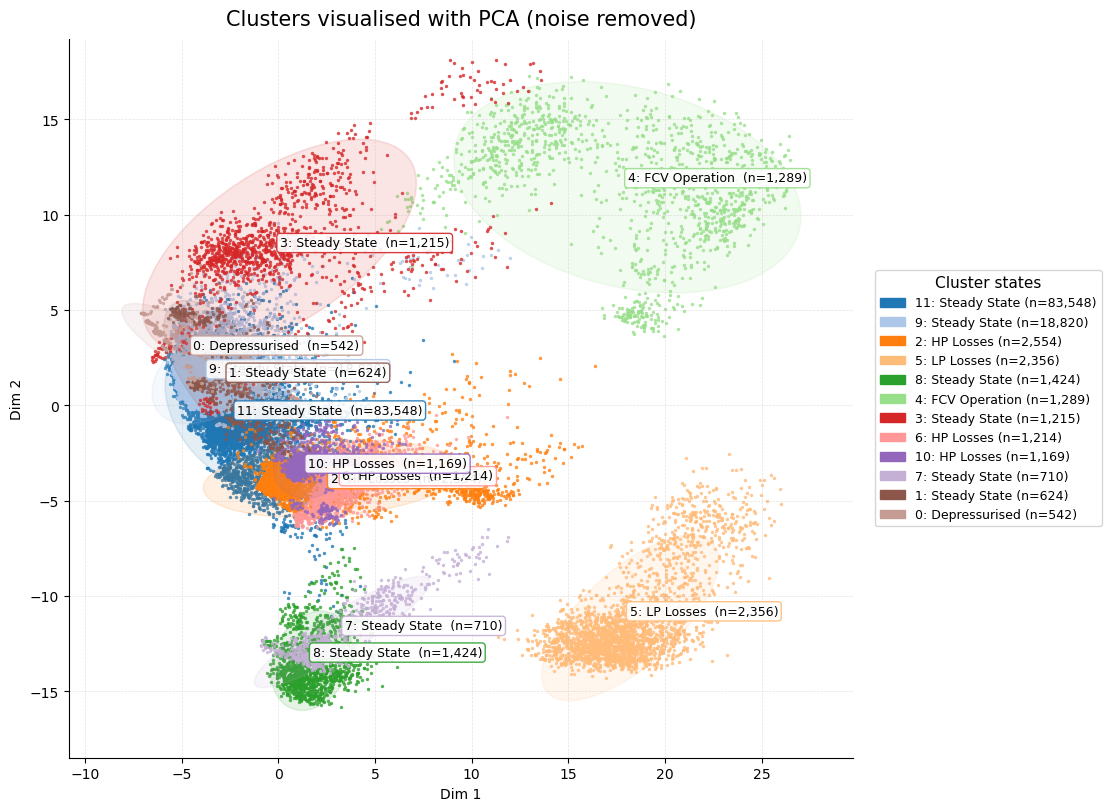

In [25]:
# Display the 2d embesdding of clusters


def _cov_ellipse(ax, pts, color, scale=1.8, alpha=0.12, lw=1.2, min_pts=30):
    if pts.shape[0] < min_pts:
        return None, None
    mu = pts.mean(axis=0)
    S  = np.cov(pts, rowvar=False)
    vals, vecs = np.linalg.eigh(S)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
    width, height = 2*scale*np.sqrt(np.maximum(vals, 1e-12))
    e = Ellipse(xy=mu, width=width, height=height, angle=theta,
                edgecolor=color, facecolor=color, lw=lw, alpha=alpha)
    ax.add_patch(e)
    return mu, e  # return patch so we can consider it for limits if we want

def plot_clusters_2d(
    embedding: np.ndarray,
    labels: np.ndarray,
    cluster_map: dict,
    title="Clusters visualised (noise removed)",
    max_points_per_cluster=6000,
    point_size=6,
    alpha=0.75,
    show_noise=False,
    save_path="fig_cluster_embedding_better.png",
    # NEW:
    fit_mode="percentile",      # 'percentile' | 'auto'
    p_lo=0.5, p_hi=99.5,        # robust bounds if fit_mode='percentile'
    extra_pad=0.10,             # extra padding fraction around computed bounds
    equal_aspect=False          # set True if you want equal scaling in x,y
):
    # --- select points ---
    mask = np.ones_like(labels, dtype=bool)
    if not show_noise:
        mask &= (labels != -1)
    X = embedding[mask]
    y = labels[mask]

    # --- cluster order by size ---
    vc = pd.Series(y).value_counts().sort_values(ascending=False)
    cluster_ids = vc.index.tolist()

    # --- palette ---
    bases = [plt.get_cmap("tab20"), plt.get_cmap("tab20b"), plt.get_cmap("tab20c")]
    palette = [b(i) for b in bases for i in range(b.N)]
    if len(palette) < len(cluster_ids):
        mul = int(np.ceil(len(cluster_ids) / len(palette)))
        palette = (palette * mul)[:len(cluster_ids)]
    cid2color = {cid: palette[i] for i, cid in enumerate(cluster_ids)}

    # --- figure/axes ---
    fig = plt.figure(figsize=(11, 8), constrained_layout=True)
    ax = fig.add_subplot(111)

    rng = np.random.default_rng(42)
    handles = []
    ellipse_patches = []

    for cid in cluster_ids:
        idx = (y == cid)
        pts = X[idx]
        npts = pts.shape[0]

        if (max_points_per_cluster is not None) and (npts > max_points_per_cluster):
            sel = rng.choice(npts, size=max_points_per_cluster, replace=False)
            pts_plot = pts[sel]
        else:
            pts_plot = pts

        color = cid2color[cid]
        ax.scatter(pts_plot[:, 0], pts_plot[:, 1], s=point_size, alpha=alpha, c=[color], linewidths=0)

        # ellipse + centroid label
        mu, epatch = _cov_ellipse(ax, pts, color=color, scale=1.8, alpha=0.12, lw=1.2, min_pts=40)
        if epatch is not None:
            ellipse_patches.append(epatch)
        if mu is not None:
            text_xy = mu + rng.normal(scale=0.12, size=2)
            desc = cluster_map.get(int(cid), f"Cluster {int(cid)}")
            ax.annotate(
                f"{int(cid)}: {desc}  (n={npts:,})",
                xy=mu, xycoords="data", xytext=text_xy, textcoords="data",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=color, alpha=0.9),
                arrowprops=dict(arrowstyle="->", lw=1.0, color=color, alpha=0.9),
            )

        handles.append(mpatches.Patch(color=color,
                        label=f"{int(cid)}: {cluster_map.get(int(cid), 'Cluster')} (n={npts:,})"))

    # --- axes scaling ---
    ax.set_title(title, fontsize=15, pad=10)
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")

    if fit_mode == "percentile":
        # robust bounds on points only, then add a bit of pad for ellipses/labels
        xlo, xhi = np.percentile(X[:, 0], [p_lo, p_hi])
        ylo, yhi = np.percentile(X[:, 1], [p_lo, p_hi])
        dx = (xhi - xlo) or 1.0
        dy = (yhi - ylo) or 1.0
        ax.set_xlim(xlo - extra_pad*dx, xhi + extra_pad*dx)
        ax.set_ylim(ylo - extra_pad*dy, yhi + extra_pad*dy)
    else:
        # let Matplotlib autoscale to ALL artists (points + ellipses), then add margins
        ax.relim()
        ax.autoscale_view()
        ax.margins(x=extra_pad, y=extra_pad)

    if equal_aspect:
        ax.set_aspect('equal', adjustable='datalim')

    # cosmetics
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # legend outside
    leg = ax.legend(handles=handles, title="Cluster states", fontsize=9, loc="center left",
                    bbox_to_anchor=(1.02, 0.5), frameon=True)
    leg.get_title().set_fontsize(11)

    # save/show
    if save_path:
        # NOTE: constrained_layout already handles space for the legend; no bbox_inches="tight" needed
        plt.savefig(save_path, dpi=220)
    plt.show()

plot_clusters_2d(
    embedding=embedding,
    labels=df_15_feat["cluster_id"].to_numpy(),
    cluster_map=cluster_map,
    title="Clusters visualised with PCA (noise removed)",
    max_points_per_cluster=6000,
    point_size=6,
    alpha=0.80,
    show_noise=False,
    save_path="fig_cluster_embedding_better.png",
    fit_mode="auto",        # <- try 'auto' first
    extra_pad=0.08,
    equal_aspect=False      # set True if you want unit scaling
)


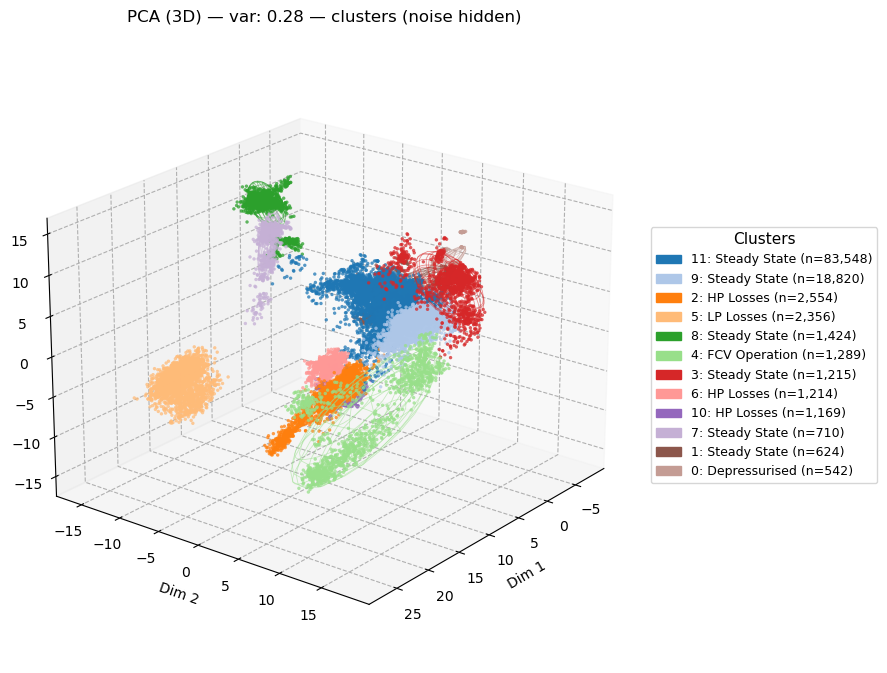

In [26]:
# ============================================
# 3D cluster visualization 

# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3D projection)
from matplotlib.patches import Patch

# ---------- 3D embedding helper ----------
def embed_3d(X_in: np.ndarray, seed: int = 42):
    """
    Return a 3D embedding of X_in (n_samples, n_features).
    Tries UMAP(n_components=3), falls back to PCA(n_components=3).
    """
    try:
        import umap
        reducer = umap.UMAP(n_components=3, random_state=seed, min_dist=0.1, n_neighbors=30)
        Y = reducer.fit_transform(X_in)
        title = "UMAP (3D)"
        meta = {}
    except Exception:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=3, random_state=seed)
        Y = pca.fit_transform(X_in)
        title = f"PCA (3D) — var: {pca.explained_variance_ratio_.sum():.2f}"
        meta = {"pca_var": pca.explained_variance_ratio_}
    return Y, title, meta


# ---------- covariance ellipsoid (3D wireframe) ----------
def add_cov_ellipsoid_3d(ax, pts, color, scale=1.8, n_mesh=24, min_pts=40):
    """
    Draw a 3D covariance ellipsoid (wireframe) for points pts[:,3].
    scale ~ how many sigma you want visually (1.8 ≈ ~1.8σ).
    """
    if pts.shape[0] < min_pts:
        return
    mu = pts.mean(axis=0)
    S = np.cov(pts, rowvar=False)
    # numerical guard
    S = np.nan_to_num(S, nan=0.0, posinf=0.0, neginf=0.0)
    vals, vecs = np.linalg.eigh(S)
    vals = np.clip(vals, 1e-12, None)  # avoid negative/zero
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # parametric sphere
    u = np.linspace(0, 2*np.pi, n_mesh)
    v = np.linspace(0, np.pi, n_mesh)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    # scale by sqrt(eigvals) and rotate
    D = np.diag(np.sqrt(vals) * scale)
    E = (vecs @ D)  # 3x3
    xyz = np.stack([xs, ys, zs], axis=-1)  # (n_mesh,n_mesh,3)
    xyz_tr = xyz @ E.T + mu  # broadcast

    ax.plot_wireframe(
        xyz_tr[..., 0], xyz_tr[..., 1], xyz_tr[..., 2],
        rstride=2, cstride=2, linewidth=0.6, color=color, alpha=0.5
    )


# ---------- main plotting function ----------
def plot_clusters_3d(
    Y: np.ndarray,                 # (n_samples, 3) embedding
    labels: np.ndarray,            # cluster id per point
    cluster_map: dict[int, str],   # id -> readable label
    title: str = "Clusters (3D)",
    show_noise: bool = False,
    max_points_per_cluster: int | None = 8000,
    point_size: float = 6.0,
    alpha: float = 0.75,
    draw_ellipsoids: bool = True,
    seed: int = 42,
    save_path: str | None = "clusters_3d.png",
):
    mask = np.ones_like(labels, dtype=bool)
    if not show_noise:
        mask &= (labels != -1)
    Yv = Y[mask]
    lab = labels[mask]

    # order clusters by size
    counts = pd.Series(lab).value_counts().sort_values(ascending=False)
    cids = counts.index.tolist()

    # palette
    bases = [plt.get_cmap("tab20"), plt.get_cmap("tab20b"), plt.get_cmap("tab20c")]
    palette = [b(i) for b in bases for i in range(b.N)]
    if len(palette) < len(cids):
        mul = int(np.ceil(len(cids)/len(palette)))
        palette = (palette * mul)[:len(cids)]
    cid2color = {cid: palette[i] for i, cid in enumerate(cids)}

    rng = np.random.default_rng(seed)

    # figure
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title(title, pad=18)

    legend_handles = []
    for cid in cids:
        sel = (lab == cid)
        pts = Yv[sel]
        n = pts.shape[0]

        # downsample big clusters
        if max_points_per_cluster and n > max_points_per_cluster:
            idx = rng.choice(n, size=max_points_per_cluster, replace=False)
            pts_plot = pts[idx]
        else:
            pts_plot = pts

        color = cid2color[cid]
        ax.scatter(pts_plot[:, 0], pts_plot[:, 1], pts_plot[:, 2],
                   s=point_size, alpha=alpha, c=[color], linewidths=0)

        # optional ellipsoid on full cluster pts
        if draw_ellipsoids:
            add_cov_ellipsoid_3d(ax, pts, color=color, scale=1.6, n_mesh=22, min_pts=40)

        legend_handles.append(
            Patch(color=color, label=f"{int(cid)}: {cluster_map.get(int(cid), 'Cluster')} (n={n:,})")
        )

    # axes labels
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.set_zlabel("Dim 3")
    # light grid
    ax.xaxis._axinfo["grid"]['linestyle'] = "--"
    ax.yaxis._axinfo["grid"]['linestyle'] = "--"
    ax.zaxis._axinfo["grid"]['linestyle'] = "--"

    # nicer view angle
    ax.view_init(elev=22, azim=38)

    # legend outside
    leg = ax.legend(handles=legend_handles, title="Clusters", loc="center left",
                    bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=9)
    leg.get_title().set_fontsize(11)

    if save_path:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()


# ===== Example usage =====
# 1) build a 3D embedding (UMAP→PCA) from your cleaned, scaled matrix X_in
Y3, emb_title, _ = embed_3d(X_in.values)

# 2) plot it
plot_clusters_3d(
    Y=Y3,
    labels=df_15_feat["cluster_id"].to_numpy(),
    cluster_map=cluster_map,
    title=f"{emb_title} — clusters (noise hidden)",
    show_noise=False,
    draw_ellipsoids=True
)


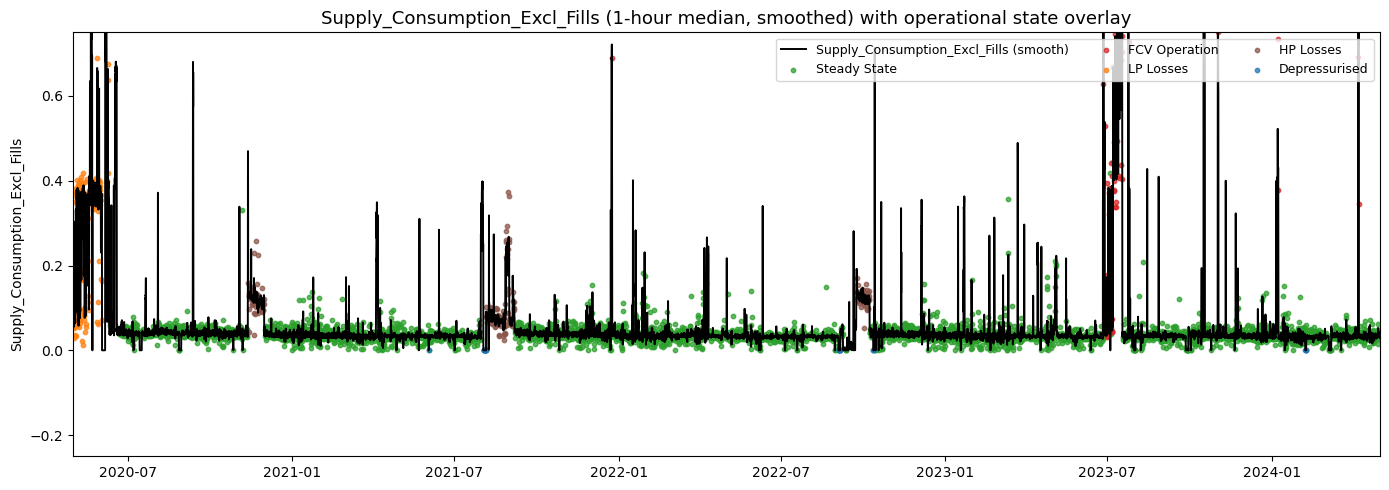

[warn] Unrecognized state names in plot: ['Noise']


In [27]:
# Assign Clusters and visulaise the identified operational States against fluid use.

# =========================
# CONFIG
# =========================
SIG         = "Supply_Consumption_Excl_Fills"   # signal column to plot
CLUSTER_COL = "cluster_id"                 # numeric cluster labels

# Your cluster → state map

#noise_sub_map = {3:"Steady State", 0:"Steady State", 2:"Steady State", 1:"Steady State", -1:"Noise"}


# Fixed colors (Steady State stays green)
palette = {
    "Steady State": "#2ca02c",          # green
    "FCV Operation": "#d62728",         # red
    "LP Losses": "#ff7f0e",             # orange
    "HP Losses": "#8c564b",             # brown
    "Depressurised": "#1f77b4",  # blue
   # "Noise": "#9c9898",                 # grey
}

# =========================
# BUILD STATE SERIES
# =========================
cols = [c for c in [SIG, CLUSTER_COL, "noise_subcluster"] if c in df_15_feat.columns]
dfp = df_15_feat[cols].copy().sort_index()

# Map main cluster ids to state names
dfp["StateName"] = dfp[CLUSTER_COL].map(cluster_map).fillna("Other")

# If noise subclusters exist, override only noise rows that have a subcluster
if "noise_subcluster" in dfp.columns:
    m = dfp[CLUSTER_COL].eq(-1) & dfp["noise_subcluster"].notna()
    dfp.loc[m, "StateName"] = (
        dfp.loc[m, "noise_subcluster"].astype(int).map(noise_sub_map).fillna("Noise")
    )

# =========================
# RESAMPLE + SMOOTH
# =========================
def dominant_state(s: pd.Series):
    if s.empty:
        return None
    m = s.mode()
    return m.iat[0] if not m.empty else None

df_1h = pd.DataFrame({
    SIG: dfp[SIG].resample("1H").median(),
    "StateName": dfp["StateName"].resample("1H").agg(dominant_state)
}).dropna(subset=[SIG])

# Light smoothing
df_1h["smooth"] = df_1h[SIG].rolling(7, center=True, min_periods=1).median()

# (defensive) normalize label text
df_1h["StateName"] = df_1h["StateName"].astype(str).str.strip()

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_1h.index, df_1h["smooth"], color="black", linewidth=1.4,
        label=f"{SIG} (smooth)")

# throttle scatter density for long series
step = max(1, len(df_1h) // 6000)

# legend order: only states that appear
legend_states = [s for s in palette.keys() if s in df_1h["StateName"].unique()]

for st in legend_states:
    m = df_1h["StateName"].eq(st)
    if m.any():
        ax.scatter(
            df_1h.index[m][::step],
            df_1h[SIG][m][::step],
            s=10, alpha=0.75, color=palette[st], label=st
        )

ax.set_title(f"{SIG} (1-hour median, smoothed) with operational state overlay", fontsize=13)
ax.set_ylabel(SIG)
# comment the next line to auto-scale Y if needed
ax.set_ylim(-0.25, 0.75)
ax.margins(x=0)
ax.legend(ncol=3, fontsize=9, loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

# Optional: sanity check for unexpected labels
unexpected = sorted(set(df_1h["StateName"].unique()) - set(palette.keys()))
if unexpected:
    print("[warn] Unrecognized state names in plot:", unexpected)


This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


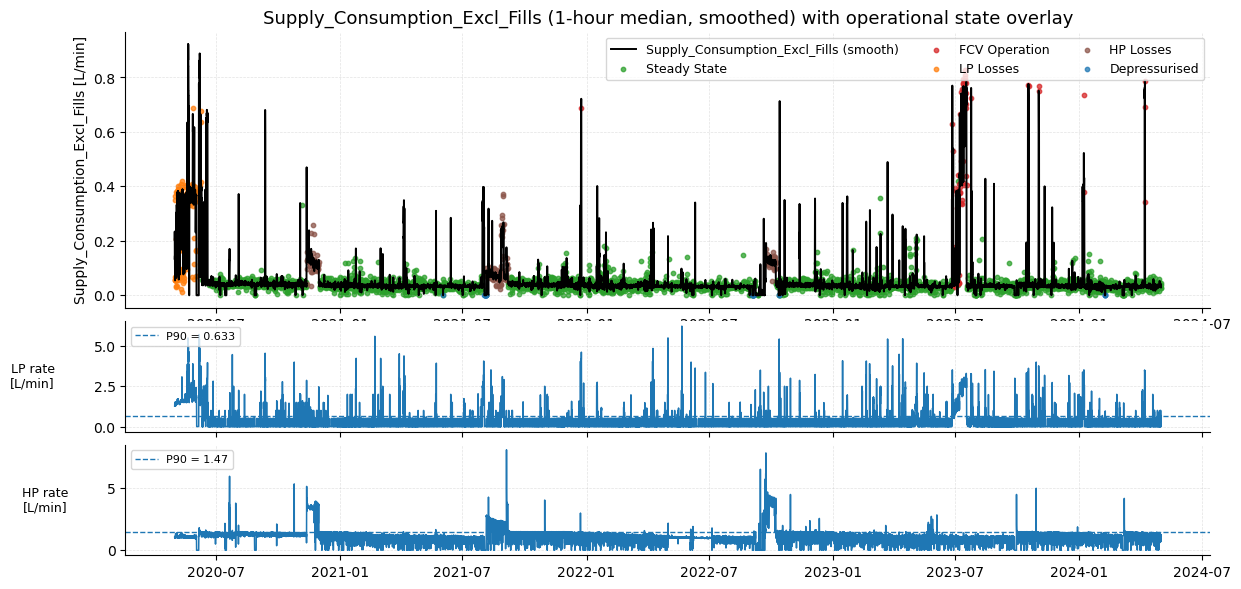

[warn] Unrecognized state names in plot: ['Noise']


In [28]:
# ============================================================
# Supply usage + cluster states (main)
#   + LP/HP pump *rates* below (1H median view, optional 90th pct cut)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

# =========================
# CONFIG
# =========================
SIG         = "Supply_Consumption_Excl_Fills"   # signal column to plot (unchanged)
CLUSTER_COL = "cluster_id"                      # numeric cluster labels (unchanged)
HP_COL      = "HP_pump_rate_2h"
LP_COL      = "LP_pump_rate_2h"

# Color palette for states (unchanged)
palette = {
    "Steady State":  "#2ca02c",   # green
    "FCV Operation": "#d62728",   # red
    "LP Losses":     "#ff7f0e",   # orange
    "HP Losses":     "#8c564b",   # brown
    "Depressurised": "#1f77b4",   # blue
}

# Draw dashed lines at the 90th percentile of each pump-rate?
SHOW_PCT_LINES = True
HP_Q = 0.90
LP_Q = 0.90

# =========================
# BUILD STATE SERIES
# =========================
def dominant_state(s: pd.Series):
    if s.empty:
        return None
    m = s.mode()
    return m.iat[0] if not m.empty else None

need_cols = [c for c in [SIG, CLUSTER_COL, "noise_subcluster", HP_COL, LP_COL] if c in df_15_feat.columns]
dfp = df_15_feat[need_cols].copy().sort_index()

# Map cluster id -> human state
dfp["StateName"] = dfp[CLUSTER_COL].map(cluster_map).fillna("Other")

# Make sure pump rates are numeric
for c in [HP_COL, LP_COL]:
    if c in dfp.columns:
        dfp[c] = pd.to_numeric(dfp[c], errors="coerce").replace([np.inf, -np.inf], np.nan)

# =========================
# RESAMPLE (1H) + SMOOTH
# =========================
df_1h = pd.DataFrame({
    SIG: dfp[SIG].resample("1H").median(),
    "StateName": dfp["StateName"].resample("1H").agg(dominant_state),
})

if HP_COL in dfp.columns:
    df_1h["HP_rate"] = dfp[HP_COL].resample("1H").median()
if LP_COL in dfp.columns:
    df_1h["LP_rate"] = dfp[LP_COL].resample("1H").median()

# Drop rows where the main signal is missing
df_1h = df_1h.dropna(subset=[SIG])

# Light smoothing on the main signal (unchanged)
df_1h["smooth"] = df_1h[SIG].rolling(7, center=True, min_periods=1).median()
df_1h["StateName"] = df_1h["StateName"].astype(str).str.strip()

# Compute 90th percentile thresholds (on the 1H series) if requested
HP_TH = df_1h["HP_rate"].quantile(HP_Q) if ("HP_rate" in df_1h.columns and SHOW_PCT_LINES) else None
LP_TH = df_1h["LP_rate"].quantile(LP_Q) if ("LP_rate" in df_1h.columns and SHOW_PCT_LINES) else None

# =========================
# PLOT with GridSpec (main + two aligned pump-rate panels)
# =========================
fig = plt.figure(figsize=(14, 6.8))
gs = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[4.0, 1.6, 1.6], hspace=0.08)

# --- Main axis (unchanged logic) ---
ax = fig.add_subplot(gs[0])
ax.plot(df_1h.index, df_1h["smooth"], color="black", linewidth=1.4, label=f"{SIG} (smooth)")

step = max(1, len(df_1h) // 6000)
legend_states = [s for s in palette.keys() if s in df_1h["StateName"].unique()]
for st in legend_states:
    m = df_1h["StateName"].eq(st)
    if m.any():
        ax.scatter(df_1h.index[m][::step], df_1h[SIG][m][::step],
                   s=10, alpha=0.75, color=palette[st], label=st)

ax.set_title(f"{SIG} (1-hour median, smoothed) with operational state overlay", fontsize=13)
ax.set_ylabel(f"{SIG} [L/min]")
# ax.set_ylim(-0.25, 0.75)  # keep/comment as you wish
ax.margins(x=0)
ax.legend(ncol=3, fontsize=9, loc="upper right", frameon=True)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
for spine in ("top","right"): ax.spines[spine].set_visible(False)

# --- LP pump rate (middle) ---
ax_lp = fig.add_subplot(gs[1], sharex=ax)
if "LP_rate" in df_1h.columns:
    ax_lp.plot(df_1h.index, df_1h["LP_rate"], linewidth=1.1)
    if LP_TH is not None and np.isfinite(LP_TH):
        ax_lp.axhline(LP_TH, linestyle="--", linewidth=1.0, label=f"P{int(LP_Q*100)} = {LP_TH:.3g}")
    ax_lp.set_ylabel("LP rate\n[L/min]", rotation=0, ha="right", va="center", labelpad=28, fontsize=9)
    ax_lp.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
    ax_lp.legend(loc="upper left", fontsize=8, frameon=True)
ax_lp.tick_params(axis="x", labelbottom=False)
for spine in ("top","right"): ax_lp.spines[spine].set_visible(False)

# --- HP pump rate (bottom) ---
ax_hp = fig.add_subplot(gs[2], sharex=ax)
if "HP_rate" in df_1h.columns:
    ax_hp.plot(df_1h.index, df_1h["HP_rate"], linewidth=1.1)
    if HP_TH is not None and np.isfinite(HP_TH):
        ax_hp.axhline(HP_TH, linestyle="--", linewidth=1.0, label=f"P{int(HP_Q*100)} = {HP_TH:.3g}")
    ax_hp.set_ylabel("HP rate\n[L/min]", rotation=0, ha="right", va="center", labelpad=28, fontsize=9)
    ax_hp.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
    ax_hp.legend(loc="upper left", fontsize=8, frameon=True)
for spine in ("top","right"): ax_hp.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# Optional: flag unexpected labels
unexpected = sorted(set(df_1h["StateName"].unique()) - set(palette.keys()))
if unexpected:
    print("[warn] Unrecognized state names in plot:", unexpected)


This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


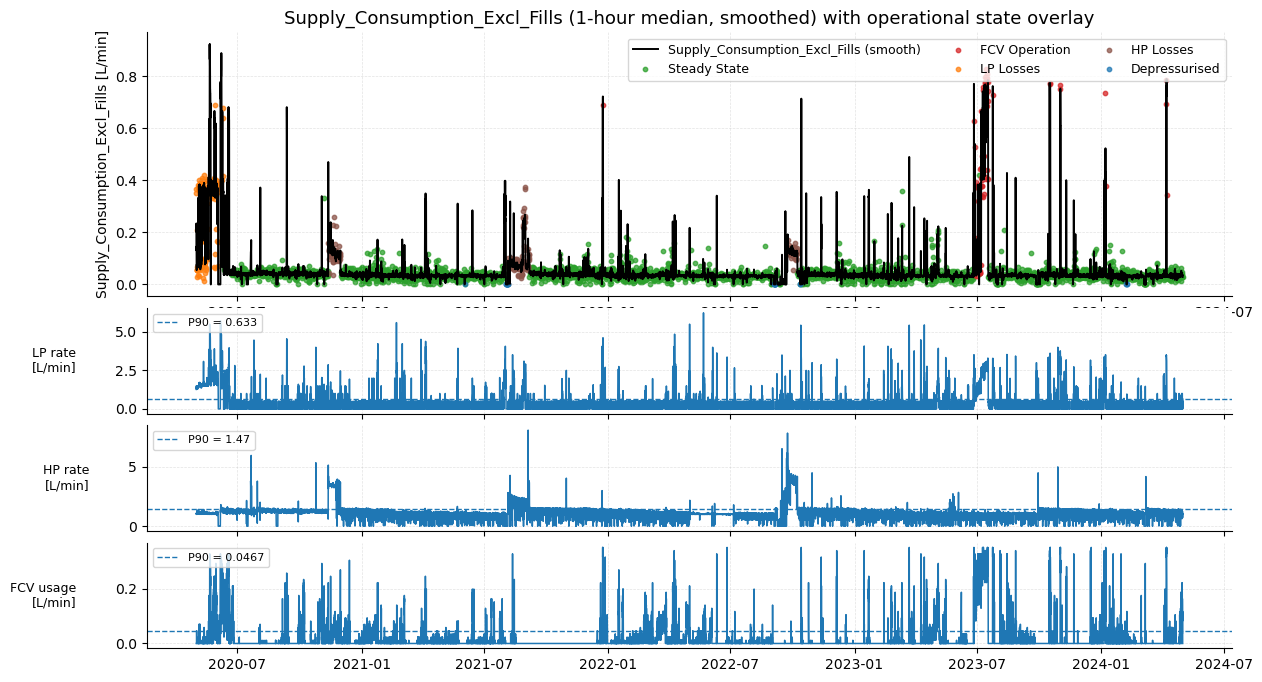

[warn] Unrecognized state names in plot: ['Noise']


In [29]:
# ============================================================
# Supply usage + cluster states (main)
#   + LP/HP/FCV panels (1H median view, optional 90th pct cut)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

# =========================
# CONFIG
# =========================
SIG         = "Supply_Consumption_Excl_Fills"   # signal column to plot (unchanged)
CLUSTER_COL = "cluster_id"                      # numeric cluster labels (unchanged)
HP_COL      = "HP_pump_rate_2h"
LP_COL      = "LP_pump_rate_2h"
FCV_COL     = "FCV_Fluid_Usage"                 # <-- NEW: name in your dataframe

# Color palette for states (unchanged)
palette = {
    "Steady State":  "#2ca02c",
    "FCV Operation": "#d62728",
    "LP Losses":     "#ff7f0e",
    "HP Losses":     "#8c564b",
    "Depressurised": "#1f77b4",
}

# Draw dashed lines at the 90th percentile of each panel?
SHOW_PCT_LINES = True
HP_Q  = 0.90
LP_Q  = 0.90
FCV_Q = 0.90  # <-- NEW

# =========================
# BUILD STATE SERIES
# =========================
def dominant_state(s: pd.Series):
    if s.empty:
        return None
    m = s.mode()
    return m.iat[0] if not m.empty else None

need_cols = [c for c in [SIG, CLUSTER_COL, "noise_subcluster", HP_COL, LP_COL, FCV_COL] if c in df_15_feat.columns]
dfp = df_15_feat[need_cols].copy().sort_index()

# Map cluster id -> human state
dfp["StateName"] = dfp[CLUSTER_COL].map(cluster_map).fillna("Other")

# Ensure numeric
for c in [HP_COL, LP_COL, FCV_COL]:
    if c in dfp.columns:
        dfp[c] = pd.to_numeric(dfp[c], errors="coerce").replace([np.inf, -np.inf], np.nan)

# =========================
# RESAMPLE (1H) + SMOOTH
# =========================
df_1h = pd.DataFrame({
    SIG: dfp[SIG].resample("1H").median(),
    "StateName": dfp["StateName"].resample("1H").agg(dominant_state),
})

if HP_COL in dfp.columns:
    df_1h["HP_rate"] = dfp[HP_COL].resample("1H").median()
if LP_COL in dfp.columns:
    df_1h["LP_rate"] = dfp[LP_COL].resample("1H").median()
if FCV_COL in dfp.columns:
    df_1h["FCV_usage"] = dfp[FCV_COL].resample("1H").median()   # <-- NEW

# Drop rows where the main signal is missing
df_1h = df_1h.dropna(subset=[SIG])

# Light smoothing on the main signal (unchanged)
df_1h["smooth"] = df_1h[SIG].rolling(7, center=True, min_periods=1).median()
df_1h["StateName"] = df_1h["StateName"].astype(str).str.strip()

# Compute 90th percentile thresholds (on the 1H series)
HP_TH  = df_1h["HP_rate"].quantile(HP_Q)      if ("HP_rate"  in df_1h.columns and SHOW_PCT_LINES) else None
LP_TH  = df_1h["LP_rate"].quantile(LP_Q)      if ("LP_rate"  in df_1h.columns and SHOW_PCT_LINES) else None
FCV_TH = df_1h["FCV_usage"].quantile(FCV_Q)   if ("FCV_usage" in df_1h.columns and SHOW_PCT_LINES) else None

# =========================
# PLOT with GridSpec (main + three aligned panels)
# =========================
rows = 4 if "FCV_usage" in df_1h.columns else 3
ratios = [4.0, 1.6, 1.6, 1.6] if rows == 4 else [4.0, 1.6, 1.6]
fig = plt.figure(figsize=(14, 8.0 if rows == 4 else 6.8))
gs = gridspec.GridSpec(nrows=rows, ncols=1, height_ratios=ratios, hspace=0.08)

# --- Main axis ---
ax = fig.add_subplot(gs[0])
ax.plot(df_1h.index, df_1h["smooth"], color="black", linewidth=1.4, label=f"{SIG} (smooth)")

step = max(1, len(df_1h) // 6000)
legend_states = [s for s in palette.keys() if s in df_1h["StateName"].unique()]
for st in legend_states:
    m = df_1h["StateName"].eq(st)
    if m.any():
        ax.scatter(df_1h.index[m][::step], df_1h[SIG][m][::step],
                   s=10, alpha=0.75, color=palette[st], label=st)

ax.set_title(f"{SIG} (1-hour median, smoothed) with operational state overlay", fontsize=13)
ax.set_ylabel(f"{SIG} [L/min]")
ax.margins(x=0)
ax.legend(ncol=3, fontsize=9, loc="upper right", frameon=True)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
for spine in ("top","right"): ax.spines[spine].set_visible(False)

# --- LP pump rate (middle 1) ---
ax_lp = fig.add_subplot(gs[1], sharex=ax)
if "LP_rate" in df_1h.columns:
    ax_lp.plot(df_1h.index, df_1h["LP_rate"], linewidth=1.1)
    if LP_TH is not None and np.isfinite(LP_TH):
        ax_lp.axhline(LP_TH, linestyle="--", linewidth=1.0, label=f"P{int(LP_Q*100)} = {LP_TH:.3g}")
    ax_lp.set_ylabel("LP rate\n[L/min]", rotation=0, ha="right", va="center", labelpad=28, fontsize=9)
    ax_lp.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
    ax_lp.legend(loc="upper left", fontsize=8, frameon=True)
ax_lp.tick_params(axis="x", labelbottom=False)
for spine in ("top","right"): ax_lp.spines[spine].set_visible(False)

# --- HP pump rate (middle 2) ---
ax_hp = fig.add_subplot(gs[2], sharex=ax)
if "HP_rate" in df_1h.columns:
    ax_hp.plot(df_1h.index, df_1h["HP_rate"], linewidth=1.1)
    if HP_TH is not None and np.isfinite(HP_TH):
        ax_hp.axhline(HP_TH, linestyle="--", linewidth=1.0, label=f"P{int(HP_Q*100)} = {HP_TH:.3g}")
    ax_hp.set_ylabel("HP rate\n[L/min]", rotation=0, ha="right", va="center", labelpad=28, fontsize=9)
    ax_hp.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
    ax_hp.legend(loc="upper left", fontsize=8, frameon=True)
if rows == 4:
    ax_hp.tick_params(axis="x", labelbottom=False)
for spine in ("top","right"): ax_hp.spines[spine].set_visible(False)

# --- FCV usage (bottom) ---
if rows == 4:
    ax_fcv = fig.add_subplot(gs[3], sharex=ax)
    ax_fcv.plot(df_1h.index, df_1h["FCV_usage"], linewidth=1.1)
    if FCV_TH is not None and np.isfinite(FCV_TH):
        ax_fcv.axhline(FCV_TH, linestyle="--", linewidth=1.0, label=f"P{int(FCV_Q*100)} = {FCV_TH:.3g}")
    ax_fcv.set_ylabel("FCV usage\n[L/min]", rotation=0, ha="right", va="center", labelpad=28, fontsize=9)
    ax_fcv.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
    ax_fcv.legend(loc="upper left", fontsize=8, frameon=True)
    for spine in ("top","right"): ax_fcv.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# Optional: flag unexpected labels
unexpected = sorted(set(df_1h["StateName"].unique()) - set(palette.keys()))
if unexpected:
    print("[warn] Unrecognized state names in plot:", unexpected)


**Run a scatter plot of numeric to determine any patterns**

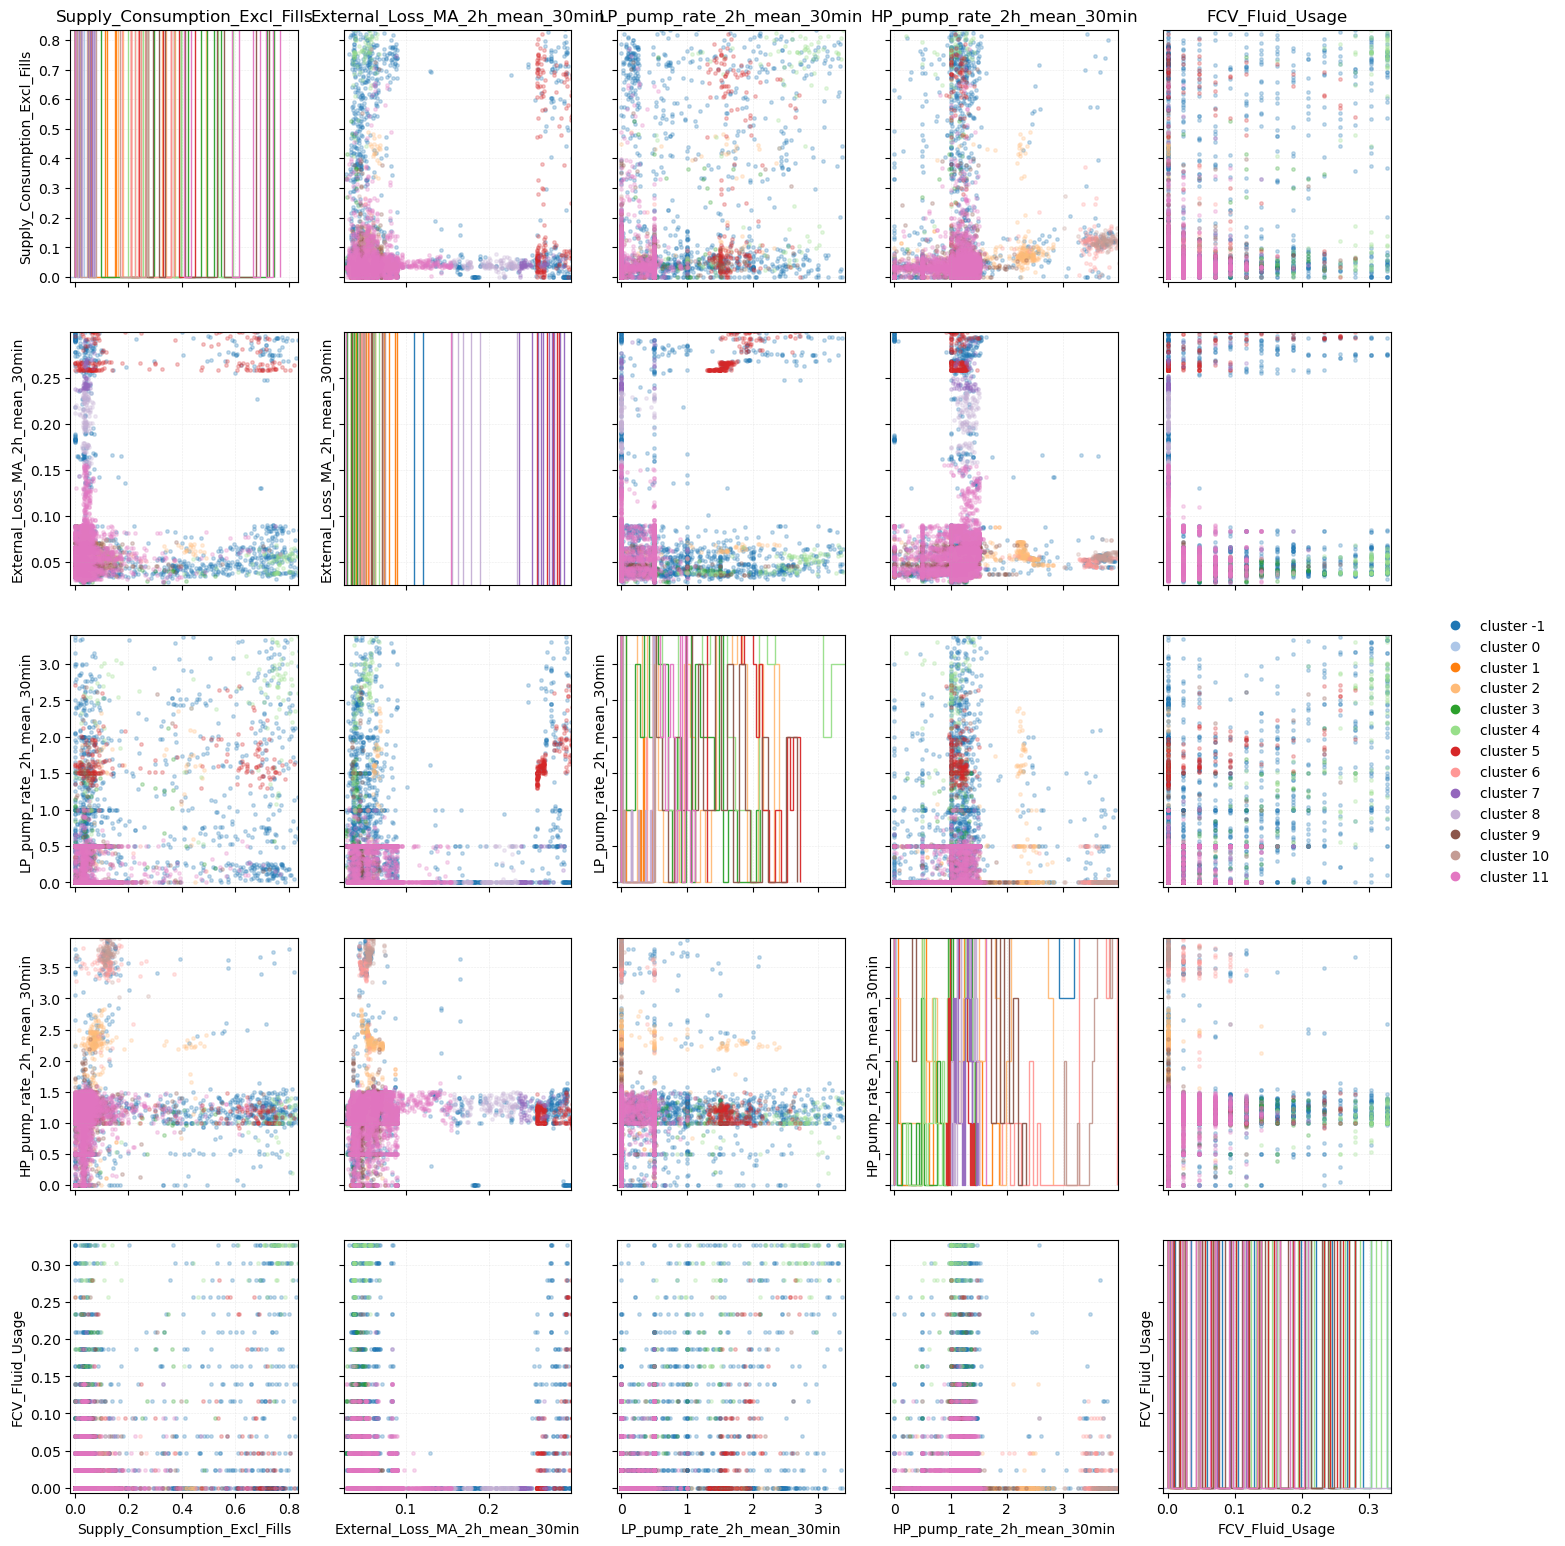

In [30]:
# Run a scatter plot of features

def scatter_matrix_by_cluster(
    df, features, cluster_col,
    sample=15000,
    s=6, alpha=0.25, bins=30,
    # layout / aesthetics
    cell_size=3.6,            # inches per subplot side (bigger -> wider plot)
    legend_out=True,
    legend_loc="right",       # "right" | "bottom" | None
    legend_ncol=None,         # auto if None
    # robust axis limits
    p_lo=0.5, p_hi=99.5,      # clip axes to these percentiles per feature
    # performance / readability
    use_hexbin=False,         # auto-dense alternative to scatter
    hexbin_gridsize=35,
):
    """
    Draw an NxN scatter matrix colored by cluster, with robust limits and an external legend.
    """
    use = df[features + [cluster_col]].dropna()
    if sample and len(use) > sample:
        use = use.sample(sample, random_state=42)

    labels = use[cluster_col].to_numpy()
    uniq = np.array(sorted(np.unique(labels)))

    # color palette that scales beyond 10
    cmaps = [plt.get_cmap("tab20"), plt.get_cmap("tab20b"), plt.get_cmap("tab20c")]
    palette = [c(i) for c in cmaps for i in range(c.N)]
    if len(palette) < len(uniq):
        k = int(np.ceil(len(uniq)/len(palette)))
        palette = (palette * k)[:len(uniq)]
    color_map = {k: palette[i] for i, k in enumerate(uniq)}

    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(cell_size*n, cell_size*n), sharex='col', sharey='row')

    # precompute robust ranges
    ranges = {}
    for f in features:
        x = use[f].to_numpy()
        lo, hi = np.nanpercentile(x, [p_lo, p_hi])
        if not np.isfinite(lo): lo = np.nanmin(x)
        if not np.isfinite(hi): hi = np.nanmax(x)
        if hi <= lo:  # fallback
            lo, hi = np.nanmin(x), np.nanmax(x)
        pad = 0.02*(hi - lo) if (hi - lo) else 1.0
        ranges[f] = (lo - pad, hi + pad)

    for i, fi in enumerate(features):
        for j, fj in enumerate(features):
            ax = axes[i, j] if n > 1 else axes

            if i == j:
                # Diagonal: per-cluster histograms (no sizes in labels)
                for k in uniq:
                    m = labels == k
                    ax.hist(use.loc[m, fi], bins=bins, histtype="step", lw=1.0,
                            color=color_map[k], alpha=0.95, label=(f"cluster {int(k)}" if j == 0 else None))
                ax.set_xlim(*ranges[fi])
                ax.set_ylabel(fi)
            else:
                # Off-diagonal: scatter (or hexbin) by cluster
                if use_hexbin:
                    # One hexbin per cluster to preserve colors
                    for k in uniq:
                        m = labels == k
                        hb = ax.hexbin(use.loc[m, fj], use.loc[m, fi],
                                       gridsize=hexbin_gridsize, mincnt=1, linewidths=0,
                                       cmap=plt.cm.colors.ListedColormap([color_map[k]]),
                                       extent=(*ranges[fj], *ranges[fi]))
                else:
                    for k in uniq:
                        m = labels == k
                        ax.scatter(use.loc[m, fj], use.loc[m, fi],
                                   s=s, alpha=alpha, color=color_map[k], rasterized=True)
                ax.set_xlim(*ranges[fj])
                ax.set_ylim(*ranges[fi])

            # axes cosmetics
            if i == n-1: ax.set_xlabel(fj)
            if j == 0 and i != j: ax.set_ylabel(fi)
            if i == 0: ax.set_title(fj, pad=6)
            ax.grid(True, ls="--", lw=0.4, alpha=0.25)

    # Legend outside the grid (no counts in labels)
    handles = [plt.Line2D([0],[0], marker='o', ls='', color=color_map[k], label=f"cluster {int(k)}")
               for k in uniq]
    if legend_out and handles:
        if legend_loc == "right":
            # reserve space on the right
            fig.subplots_adjust(right=0.82)
            ncol = legend_ncol or 1
            fig.legend(handles=handles, labels=[h.get_label() for h in handles],
                       loc="center left", bbox_to_anchor=(0.84, 0.5), frameon=False, ncol=ncol)
        elif legend_loc == "bottom":
            fig.subplots_adjust(bottom=0.12)
            ncol = legend_ncol or min(len(handles), 5)
            fig.legend(handles=handles, labels=[h.get_label() for h in handles],
                       loc="lower center", bbox_to_anchor=(0.5, 0.01), frameon=False, ncol=ncol)

    plt.show()
cluster_col = "cluster_id"
features_to_plot = [
    "Supply_Consumption_Excl_Fills",
    "External_Loss_MA_2h_mean_30min",
    "LP_pump_rate_2h_mean_30min",
    "HP_pump_rate_2h_mean_30min",
    "FCV_Fluid_Usage",
]

scatter_matrix_by_cluster(
    df_15_feat, features_to_plot, cluster_col,
    sample=12000,
    s=6, alpha=0.25, bins=30,
    cell_size=3.8,           # wider cells
    legend_out=True, legend_loc="right", legend_ncol=1,
    p_lo=0.5, p_hi=99.5,     # robust clipping
    use_hexbin=False         # set True if dots still look too dense
)


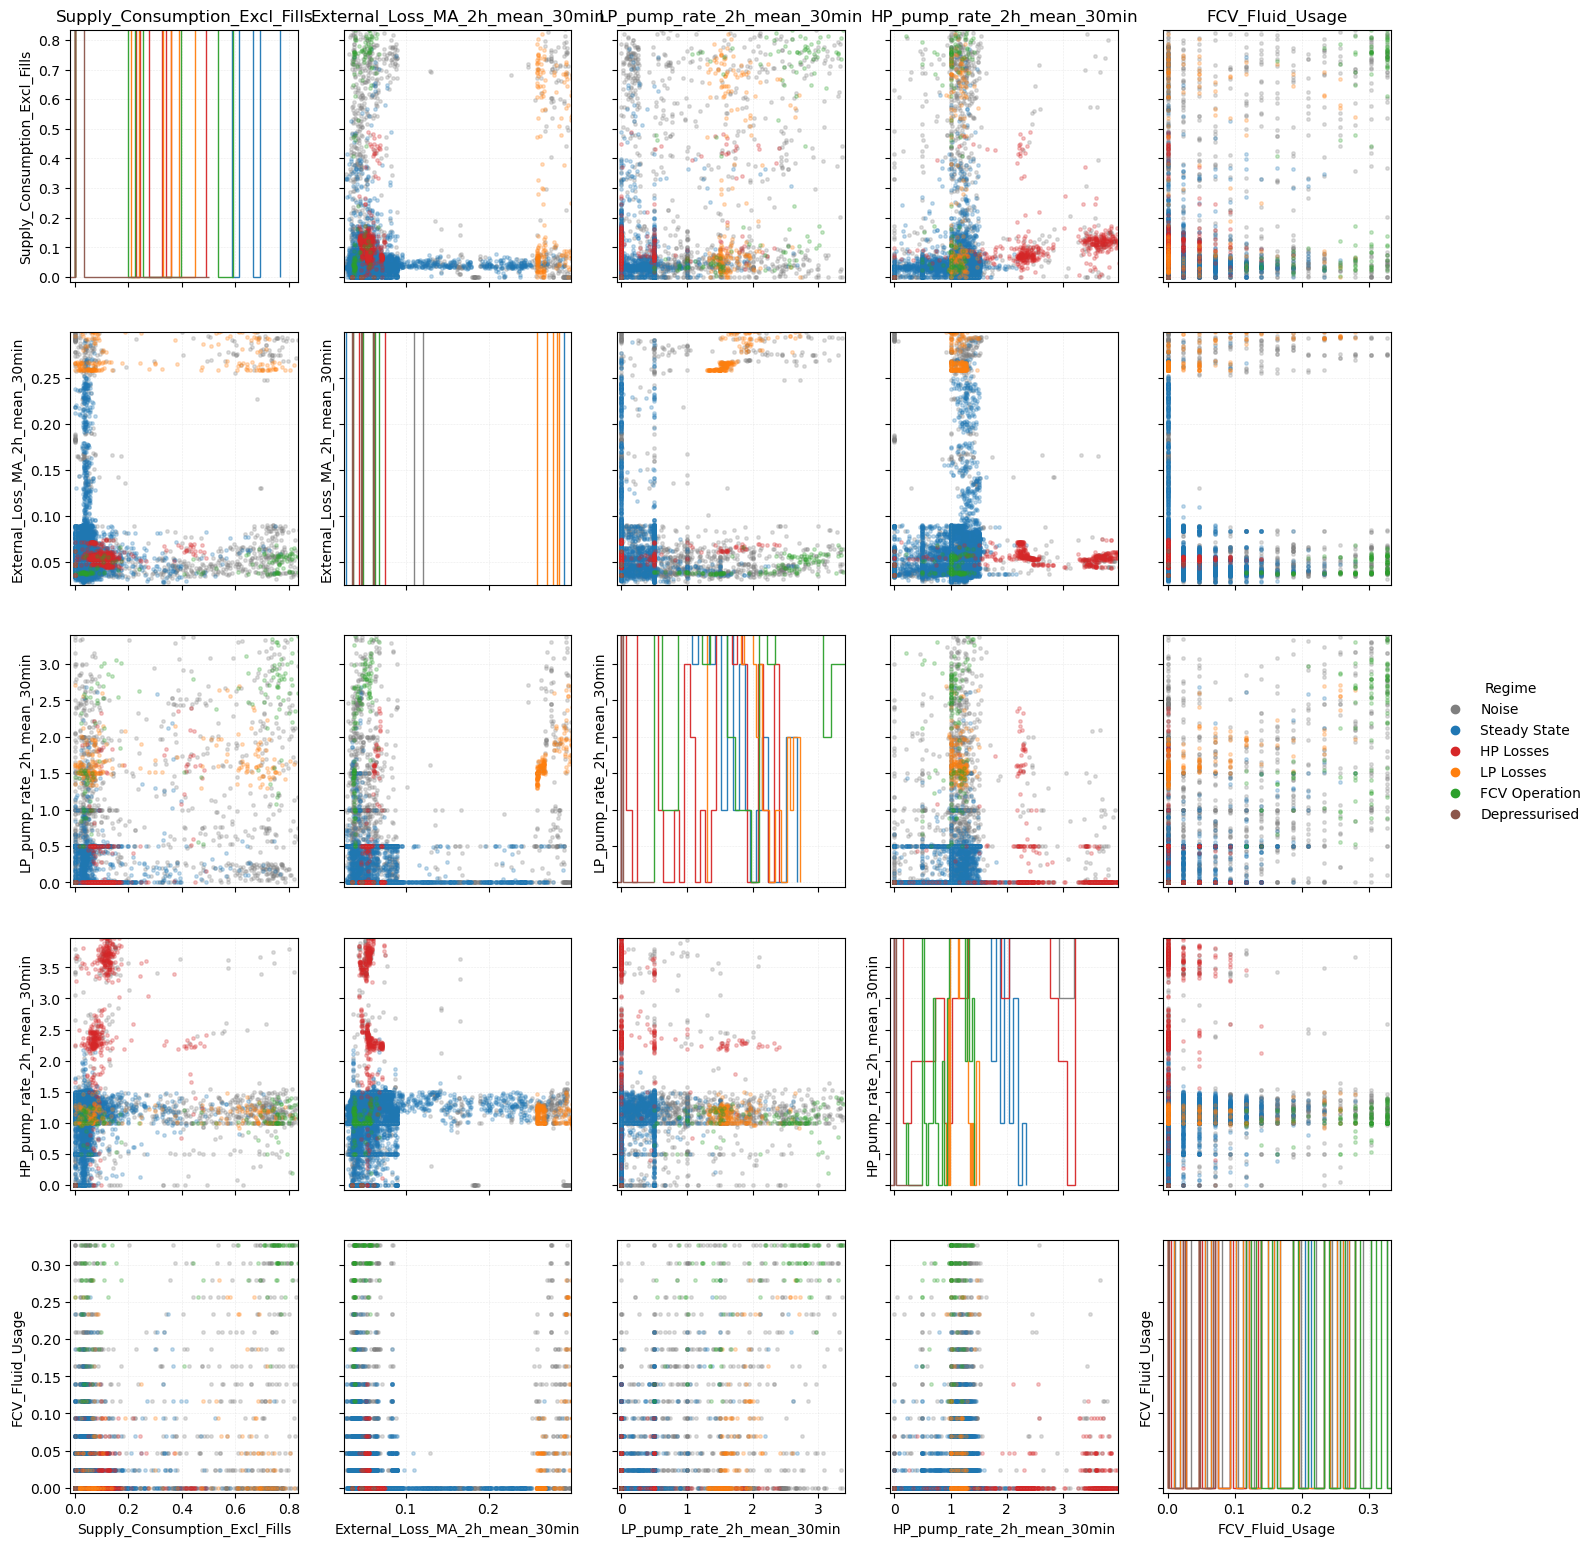

In [31]:
# Another Scatter plot but per operating regime rather than cluster


def scatter_matrix_by_regime(
    df, features, cluster_col,
    sample=15000,
    s=6, alpha=0.25, bins=30,
    cell_size=3.8,
    legend_out=True, legend_loc="right", legend_ncol=None,
    p_lo=0.5, p_hi=99.5,
    use_hexbin=False, hexbin_gridsize=35,
    regime_colors=None,           # optional dict to override colors per regime
):
    # 1) prepare data
    use = df[features + [cluster_col]].dropna().copy()
    # map cluster -> regime; unseen clusters -> "Other"
    use["regime"] = use[cluster_col].map(cluster_map).fillna("Other")

    if sample and len(use) > sample:
        use = use.sample(sample, random_state=42)

    regimes = list(dict.fromkeys(use["regime"]))  # stable order

    # 2) palette: one color per regime
    if regime_colors is None:
        base = plt.get_cmap("tab10")
        default_colors = ["Steady State","HP Losses","LP Losses","FCV Operation","Noise","Other"]
        default_palette = {
            "Steady State": base(0),
            "HP Losses":    base(3),
            "LP Losses":    base(1),
            "FCV Operation":base(2),
            "Noise":        base(7),
            "Other":        base(9),
        }
        regime_palette = {r: default_palette.get(r, base(i % base.N)) for i, r in enumerate(regimes)}
    else:
        regime_palette = regime_colors

    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(cell_size*n, cell_size*n), sharex='col', sharey='row')

    # 3) robust ranges per feature
    ranges = {}
    for f in features:
        x = use[f].to_numpy()
        lo, hi = np.nanpercentile(x, [p_lo, p_hi])
        if not np.isfinite(lo): lo = np.nanmin(x)
        if not np.isfinite(hi): hi = np.nanmax(x)
        if hi <= lo:
            lo, hi = np.nanmin(x), np.nanmax(x)
        pad = 0.02*(hi - lo) if (hi - lo) else 1.0
        ranges[f] = (lo - pad, hi + pad)

    # 4) draw
    for i, fi in enumerate(features):
        for j, fj in enumerate(features):
            ax = axes[i, j] if n > 1 else axes

            if i == j:
                # diagonal: hist per regime
                for r in regimes:
                    m = use["regime"].eq(r)
                    ax.hist(use.loc[m, fi], bins=bins, histtype="step", lw=1.0,
                            color=regime_palette[r], alpha=0.95,
                            label=(r if j == 0 else None))
                ax.set_xlim(*ranges[fi])
                ax.set_ylabel(fi)
            else:
                # off-diagonal: scatter/hexbin per regime
                if use_hexbin:
                    for r in regimes:
                        m = use["regime"].eq(r)
                        ax.hexbin(use.loc[m, fj], use.loc[m, fi],
                                  gridsize=hexbin_gridsize, mincnt=1, linewidths=0,
                                  cmap=plt.cm.colors.ListedColormap([regime_palette[r]]),
                                  extent=(*ranges[fj], *ranges[fi]))
                else:
                    for r in regimes:
                        m = use["regime"].eq(r)
                        ax.scatter(use.loc[m, fj], use.loc[m, fi],
                                   s=s, alpha=alpha, color=regime_palette[r], rasterized=True)
                ax.set_xlim(*ranges[fj])
                ax.set_ylim(*ranges[fi])

            # cosmetics
            if i == n-1: ax.set_xlabel(fj)
            if j == 0 and i != j: ax.set_ylabel(fi)
            if i == 0: ax.set_title(fj, pad=6)
            ax.grid(True, ls="--", lw=0.4, alpha=0.25)

    # 5) legend by regime (no sizes)
    handles = [plt.Line2D([0],[0], marker='o', ls='', color=regime_palette[r], label=r) for r in regimes]
    if legend_out and handles:
        if legend_loc == "right":
            fig.subplots_adjust(right=0.82)
            ncol = legend_ncol or 1
            fig.legend(handles=handles,
                       loc="center left", bbox_to_anchor=(0.84, 0.5),
                       frameon=False, ncol=ncol, title="Regime")
        elif legend_loc == "bottom":
            fig.subplots_adjust(bottom=0.13)
            ncol = legend_ncol or min(len(handles), 5)
            fig.legend(handles=handles,
                       loc="lower center", bbox_to_anchor=(0.5, 0.02),
                       frameon=False, ncol=ncol, title="Regime")

    plt.show()
    
cluster_col = "cluster_id"
features_to_plot = [
    "Supply_Consumption_Excl_Fills",
    "External_Loss_MA_2h_mean_30min",
    "LP_pump_rate_2h_mean_30min",
    "HP_pump_rate_2h_mean_30min",
    "FCV_Fluid_Usage",
]

scatter_matrix_by_regime(
    df_15_feat, features_to_plot, cluster_col,
    sample=12000,
    s=6, alpha=0.25, bins=30,
    cell_size=3.8,
    legend_out=True, legend_loc="right", legend_ncol=1,
    p_lo=0.5, p_hi=99.5,
    use_hexbin=False
)


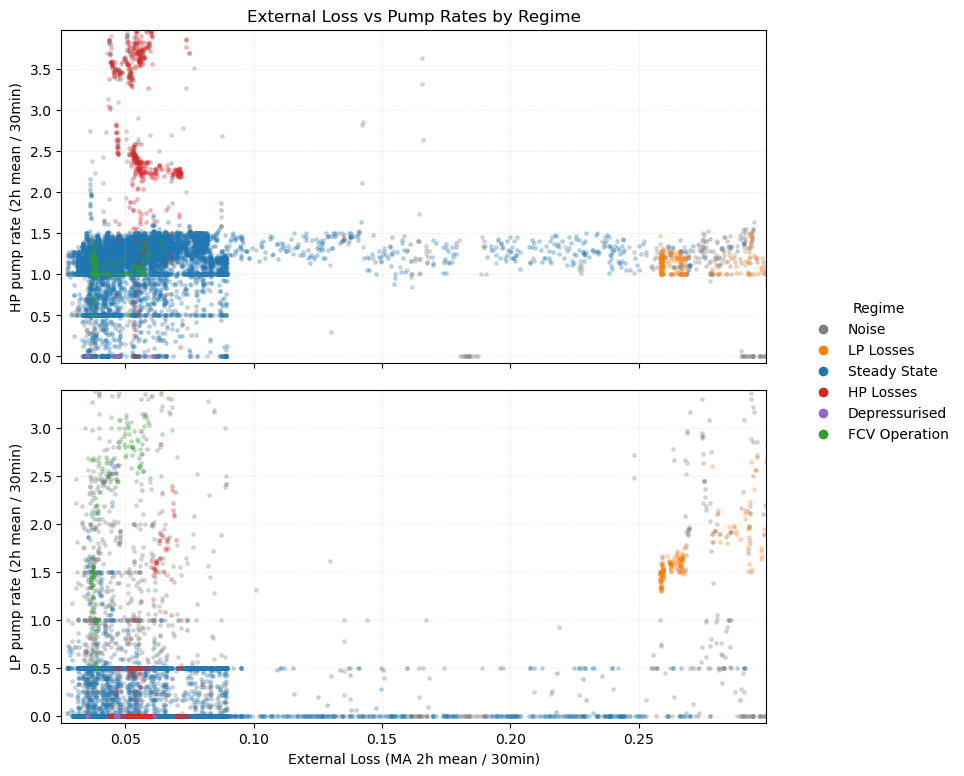

In [32]:
# Plot individaul scatter plots of feature with some interest

def plot_external_loss_vs_pump_rates(
    df,
    cluster_col="cluster_id",
    x_col="External_Loss_MA_2h_mean_30min",
    y_hp="HP_pump_rate_2h_mean_30min",
    y_lp="LP_pump_rate_2h_mean_30min",
    sample=15000,
    s=8,
    alpha=0.28,
    p_lo=0.5,
    p_hi=99.5,
    regime_colors=None,  # optional dict like {"Steady State": (r,g,b,a), ...}
):
    """
    Creates two vertically stacked scatter plots:
    - Top: External Loss vs HP pump rate
    - Bottom: External Loss vs LP pump rate
    Points are colored by 'regime' derived from `cluster_map[cluster_id]`.
    """

    # --- 1) Prep data
    cols = [x_col, y_hp, y_lp, cluster_col]
    use = df[cols].dropna().copy()

    # Map clusters -> regime; unseen -> "Other"
    # Assumes you have a dict `cluster_map` in scope
    use["regime"] = use[cluster_col].map(cluster_map).fillna("Other")

    # Stable regime order (first occurrence order)
    regimes = list(dict.fromkeys(use["regime"]))

    # Downsample if large
    if sample and len(use) > sample:
        use = use.sample(sample, random_state=42)

    # --- 2) Palette
    if regime_colors is None:
        base = plt.get_cmap("tab10")
        default_palette = {
            "Steady State": base(0),
            "HP Losses":    base(3),
            "LP Losses":    base(1),
            "FCV Operation":base(2),
            "Noise":        base(7),
            "Other":        base(9),
        }
        palette = {r: default_palette.get(r, base(i % base.N)) for i, r in enumerate(regimes)}
    else:
        palette = regime_colors

    # --- 3) Robust axis ranges
    def robust_range(arr):
        lo, hi = np.nanpercentile(arr, [p_lo, p_hi])
        if not np.isfinite(lo): lo = np.nanmin(arr)
        if not np.isfinite(hi): hi = np.nanmax(arr)
        if hi <= lo:
            lo, hi = np.nanmin(arr), np.nanmax(arr)
        pad = 0.02 * (hi - lo) if (hi - lo) else 1.0
        return lo - pad, hi + pad

    x_rng = robust_range(use[x_col].to_numpy())
    y_hp_rng = robust_range(use[y_hp].to_numpy())
    y_lp_rng = robust_range(use[y_lp].to_numpy())

    # --- 4) Figure & axes
    fig, axes = plt.subplots(
        2, 1, figsize=(10, 9), sharex=True,
        gridspec_kw={"hspace": 0.08}
    )

    # Helper to draw one panel
    def draw_panel(ax, y_col, y_label):
        for r in regimes:
            m = use["regime"].eq(r)
            ax.scatter(
                use.loc[m, x_col], use.loc[m, y_col],
                s=s, alpha=alpha, color=palette[r], rasterized=True
            )
        ax.grid(True, ls="--", lw=0.5, alpha=0.3)
        ax.set_ylabel(y_label)

    # Top: HP
    draw_panel(axes[0], y_hp, "HP pump rate (2h mean / 30min)")
    axes[0].set_ylim(*y_hp_rng)
    axes[0].set_title("External Loss vs Pump Rates by Regime")

    # Bottom: LP
    draw_panel(axes[1], y_lp, "LP pump rate (2h mean / 30min)")
    axes[1].set_ylim(*y_lp_rng)

    # X label on bottom only
    axes[1].set_xlabel("External Loss (MA 2h mean / 30min)")
    axes[1].set_xlim(*x_rng)

    # --- 5) Shared legend (right side)
    handles = [plt.Line2D([0],[0], marker='o', ls='', color=palette[r], label=r) for r in regimes]
    fig.subplots_adjust(right=0.83)
    fig.legend(
        handles=handles,
        loc="center left", bbox_to_anchor=(0.86, 0.5),
        frameon=False, title="Regime"
    )

    plt.show()


# Example usage with your dataframe:
plot_external_loss_vs_pump_rates(
    df_15_feat,
    cluster_col="cluster_id",
    x_col="External_Loss_MA_2h_mean_30min",
    y_hp="HP_pump_rate_2h_mean_30min",
    y_lp="LP_pump_rate_2h_mean_30min",
    sample=12000,
    s=6,
    alpha=0.25,
    p_lo=0.5, p_hi=99.5,
)


##### Observations from Clustered Regime Plot  
*External Loss vs LP/HP Pump Rates*

- The plot correctly separates operating regimes according to expected system behaviour.  
- LP Losses occur at very high external losses and coincide with high LP pump activity, while HP pumps remain stable — confirming that LP losses dominate total system leakage.  
- HP Losses show moderately elevated external losses but higher HP pump rates than other regimes; these events are less frequent and typically lower in magnitude than LP loss conditions.  
- FCV Operation produces increased LP pump rates during valve actuation but does not generate high external losses, representing normal operational cycles.  
- Steady-State periods cluster around low external losses and stable pump rates, defining normal baseline performance.  
- Depressurised sit near zero pressure or irregular behaviour, as expected.

**Conclusion
The clustering successfully distinguishes between operating regimes based on fluid losses and pump activity. 


#### Build a concise cluster summary and a probabilistic label (“steady / HP losses / LP losses / FCV ops”) for each cluster.


- `cluster_id` — HDBSCAN cluster index
- `n_points` / `pct_of_all` — size of the cluster.
- `state` — assigned operatioanl regime
- `mean_prob`, — HDBSCAN membership strength within the assigned cluster 
- `post_*` — rule-based posterior scores for regimes (STEADY / LOSSES_HP / LOSSES_LP / FCV_OPS) computed from feature thresholds inside each cluster; rows sum =1.0.
- `state_pred` — regime with the highest posterior for that cluster; `label_confidence` is its posterior value.

Posterior scoe is the probability of each regime given the data in this cluster.

In [33]:
# ==== Ensure df_15_feat has cluster IDs + thier probabilities + assigned state prior to supervised learning====

import numpy as np
import pandas as pd
import joblib, json
from pathlib import Path
from hdbscan import prediction as hdb_pred

# Load the model 

MODEL_DIR  = Path(r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models")
MODEL_PATH = MODEL_DIR / "hdbscan_pca_model_v7.pkl"
XFORM_PATH = MODEL_DIR / "preprocess_scaler_pca_v7.pkl"
META_PATH  = MODEL_DIR / "hdbscan_meta_v7.json"

# Use your canonical map (fix this if you’ve updated it)



# ---------- your mapping dicts (use what you set earlier) ----------
CLUSTER_TO_STATE = cluster_map

noise_sub_labels = {3:"Steady State", 0:"Steady State", 2:"Steady State", 1:"Steady State", -1:"Noise"}
df_15_feat = df_15_feat.copy()

needs_labels = "cluster_id" not in df_15_feat.columns
needs_probs  = "cluster_probability" not in df_15_feat.columns

if needs_labels or needs_probs:
    # Path A: if you just refit HDBSCAN in this session
    if "hdb_new" in globals():
        # If you have labels_aligned from the alignment step, use them. Otherwise use raw labels.
        if "labels_aligned" in globals():
            df_15_feat["cluster_id"] = labels_aligned
        else:
            df_15_feat["cluster_id"] = hdb_new.labels_
        df_15_feat["cluster_probability"] = hdb_new.probabilities_

    # Path B: otherwise load saved model and predict on current X_pca
    elif MODEL_PATH.exists() and "X_pca" in globals():
        hdb  = joblib.load(MODEL_PATH)
        meta = json.loads(META_PATH.read_text())
        labels_raw, strengths = hdb_pred.approximate_predict(hdb, X_pca)

        # remap model labels -> your original IDs if label_remap is present
        remap = meta.get("label_remap", {})
        labels_orig = np.array([remap.get(int(x), int(x)) for x in labels_raw])

        df_15_feat["cluster_id"]     = labels_orig
        df_15_feat["cluster_probability"] = strengths
    else:
        raise RuntimeError(
            "df_15_feat is missing clustering columns and neither a refit model "
            "(hdb_new) nor saved model+X_pca were found. "
            "Refit HDBSCAN or load the saved model and ensure X_pca is in memory."
        )

# Map to state names
df_15_feat["state"] = df_15_feat["cluster_id"].map(CLUSTER_TO_STATE).fillna("Other")

# ==== Now your evaluation block will work ====
# 0) De-fragment frame
df_15_feat = df_15_feat.copy()

# 1) Ensure expected cols exist
required = ["cluster_id", "cluster_probability"]
missing  = [c for c in required if c not in df_15_feat.columns]
if missing:
    raise KeyError(f"Missing columns in df_15_feat: {missing}")

# 2) Pick key fields to profile (only keep the ones that exist)
CAND_BOOL = []
bool_cols = [c for c in CAND_BOOL if c in df_15_feat.columns]

CAND_NUM = ["External_Losses", "Supply_Consumption_Excl_Fills"]
num_cols = [c for c in CAND_NUM if c in df_15_feat.columns]

# 3) Core summaries
N = len(df_15_feat)

size_tbl = df_15_feat.groupby("cluster_id").size().rename("n_points").to_frame()
size_tbl["pct_of_all"] = (100.0 * size_tbl["n_points"] / N).round(2)

prob_tbl = (
    df_15_feat.groupby("cluster_id")["cluster_probability"]
              .agg(mean_prob="mean", median_prob="median", min_prob="min", max_prob="max")
              .round(4)
)

state_tbl = (
    df_15_feat[["cluster_id", "state"]]
             .drop_duplicates("cluster_id")
             .set_index("cluster_id")
)

# 4) Boolean (% True) and Numeric stats
bool_tbl = pd.DataFrame(index=size_tbl.index)
if bool_cols:
    bool_tbl = df_15_feat.groupby("cluster_id")[bool_cols].mean().mul(100).round(2)
    bool_tbl.columns = [f"{c}_pct" for c in bool_tbl.columns]

num_tbl = pd.DataFrame(index=size_tbl.index)
if num_cols:
    num_tbl = df_15_feat.groupby("cluster_id")[num_cols].agg(["mean","median"])
    num_tbl.columns = [f"{col}_{stat}" for col, stat in num_tbl.columns]
    num_tbl = num_tbl.round(4)

# 5) Consolidate
summary = (
    size_tbl.join(state_tbl, how="left")
            .join(prob_tbl,  how="left")
            .join(bool_tbl,  how="left")
            .join(num_tbl,   how="left")
            .sort_values("n_points", ascending=False)
)

# 6) 
summary.insert(0, "cluster_id", summary.index.astype(int))
summary.reset_index(drop=True, inplace=True)

# 7) Show results
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 200)
print("=== Cluster Summary ===")
print(summary)
from statsmodels.stats.proportion import proportion_confint

def _frac(k, n, alpha=0.05):
    if n == 0: return 0.0, (0.0, 1.0)
    lo, hi = proportion_confint(k, n, alpha=alpha, method="wilson")
    return k/n, (lo, hi)

def compute_regime_posteriors(df, cluster_col,
                              SUPPLY_LO=0.041,
                              LOSSES_TH=0.04,
                              FCV_TH=0.20,
                              hp_q=0.90, lp_q=0.90,
                              include_noise=True):
    HP_TH = df["HP_pump_rate_2h"].quantile(hp_q)
    LP_TH = df["LP_pump_rate_2h"].quantile(lp_q)

    rows = []
    for cid, g in df.groupby(cluster_col):
        if (not include_noise) and cid == -1:
            continue
        n = len(g)

        kS  = (g["Supply_Consumption_Excl_Fills"] <= SUPPLY_LO).sum()
        kL  = (g["External_Losses"]              >= LOSSES_TH).sum()
        kHh = (g["HP_pump_rate_2h"]              >= HP_TH).sum()
        kLp = (g["LP_pump_rate_2h"]              >= LP_TH).sum()
        kF  = (g["FCV_Fluid_Usage"]              >= FCV_TH).sum()

        pS, _  = _frac(kS,  n)
        pL, _  = _frac(kL,  n)
        pHh, _ = _frac(kHh, n)
        pLp, _ = _frac(kLp, n)
        pF, _  = _frac(kF,  n)

        scores = {
            "STEADY":     pS * (1 - pL),
            "LOSSES_HP":  pL * pHh * (1 - pLp),
            "LOSSES_LP":  pL * pLp * (1 - pHh),
            "FCV_OPS":    pF,
        }
        if pF > 0.5:
            for k in ["STEADY", "LOSSES_HP", "LOSSES_LP"]:
                scores[k] *= (1 - pF)

        Z = sum(scores.values())
        post = {k: (v / Z if Z > 0 else 0.0) for k, v in scores.items()}
        state_pred = max(post, key=post.get) if Z > 0 else "UNCERTAIN"
        label_conf = post.get(state_pred, 0.0)

        rows.append({
            "cluster_id": int(cid),
            "post_STEADY":     post["STEADY"],
            "post_LOSSES_HP":  post["LOSSES_HP"],
            "post_LOSSES_LP":  post["LOSSES_LP"],
            "post_FCV_OPS":    post["FCV_OPS"],
            "state_pred":      state_pred,
            "label_confidence": label_conf,
        })

    return pd.DataFrame(rows).set_index("cluster_id")

# Compute label confidence
cluster_posts = compute_regime_posteriors(df_15_feat, cluster_col="cluster_id", include_noise=True)

# Drop the *_pct columns and add the new ones
cols_to_drop = [c for c in summary.columns if c.endswith("_pct")]
summary_clean = (
    summary.drop(columns=cols_to_drop, errors="ignore")
           .set_index("cluster_id")
           .join(cluster_posts, how="left")
           .reset_index()
)

#
# summary_clean["state"] = summary_clean["state_pred"]

display_cols = [
    "cluster_id", "n_points", "pct_of_all",
    "state", "state_pred", "label_confidence",
    "mean_prob", "median_prob",
    "post_STEADY", "post_LOSSES_HP", "post_LOSSES_LP", "post_FCV_OPS"
]
display_cols = [c for c in display_cols if c in summary_clean.columns]

print("\n=== Cluster Summary (with label confidence; cleaned) ===")
print(summary_clean[display_cols].sort_values("n_points", ascending=False).round(3).to_string(index=False))

=== Cluster Summary ===
    cluster_id  n_points  pct_of_all          state  mean_prob  median_prob  min_prob  max_prob  External_Losses_mean  External_Losses_median  Supply_Consumption_Excl_Fills_mean  \
0           11     83548       59.57   Steady State     0.9664       1.0000    0.6788       1.0                0.0328                  0.0320                              0.0398   
1           -1     24792       17.68          Noise     0.0000       0.0000    0.0000       0.0                0.1238                  0.0326                              0.2050   
2            9     18820       13.42   Steady State     0.7908       0.9010    0.3237       1.0                0.0366                  0.0328                              0.0422   
3            2      2554        1.82      HP Losses     0.6275       0.5832    0.1941       1.0                0.0989                  0.0719                              0.1009   
4            5      2356        1.68      LP Losses     0.7624       0.

**High-level readout**
- The dataset is mostly Steady State: clusters 11, 9, 8, 3, 7, 1 together account for 75% of points, with high membership (`mean_prob` ≈ 0.79–0.97) and strong steady posteriors (e.g., cluster 11: `post_STEADY=0.939`).
- Noise (cluster −1) is *18% of the data with no cluster membership (as expected). Its posteriors are mixed (`post_STEADY 0.49`, `post_LOSSES_LP 0.22`, `post_FCV_OPS 0.20`), so uncertain.
- HP Losses appear in small but high-confidence clusters: 2, 6, 10 (~3.5%** total). Their posteriors are near 1.0 for HP losses (0.97–1.00), matching elevated HP pump activity and higher external losses.
- LP Losses (cluster 5) are ~1.7% of points with strong LP-loss posterior (`0.873`) and higher external losses than HP-loss clusters — consistent with your plots.
- FCV Operation (cluster 4) is 0.9% with very high membership (`0.965`) and posterior (`post_FCV_OPS 0.936`), indicating clean separation of valve-actuation behaviour.
- Depressurised** (cluster 0) is small (~*.4%). Posterior model doesn’t include a “depressurised” class, so it defaults to `state_pred=STEADY` 



### Section 3.  Supervised Learning 
Take the now labelled data set (labelled via the clusters) and run variosu supervised models to detect the operational regime. Evalaute the model and save the supervised model which can be used in my Hydraulci system dashboard to detect anomalous operarting conditions.

Dataset will be an 80/20 split. Must ensure that the rarer states are in both test and train sets. Use weightings to ensure rarer but high confidence (based on HDBSCAN confidnce that point belongs to a cluster) are valued higher than steady state with lower confidence

Ensure any labels or health status indcaors are not used to train model to ensure no leakage

In [34]:
print(df_15_feat.columns.tolist())


['Supply_Consumption_Excl_Fills', 'umbilical_charge_volume', 'External_Losses', 'External_Loss_MA_2h', 'FCV_Fluid_Usage', 'HP_pump_rate_2h', 'LP_pump_rate_2h', 'HPU_LPA_OUT_DropSlope_1h_Lph', 'HPU_HPA_OUT_DropSlope_1h_Lph', 'HPU_LPB_OUT_DropSlope_1h_Lph', 'HPU_HPB_OUT_DropSlope_1h_Lph', 'LP_Px_Delta', 'HPU_LPA_OUT', 'HPU_LPB_OUT', 'HPU_HPA_OUT', 'HPU_HPB_OUT', 'SCM1_RET', 'SCM1_LP_CONS', 'HP_Px_Delta', 'External_Losses_DropSlope_1h_Lph', 'Supply_Consumption_Excl_Fills_DropSlope_1h_Lph', 'SCM1_HP_CONS', 'HP_pump_state', 'LP_pump_state', '2_LP_Valve_ClosedToOpen', '2_LP_Valve_OpenToClosed', '5_LP_Valve_ClosedToOpen', '5_LP_Valve_OpenToClosed', 'External_Loss_EWM_1d', 'External_Loss_EWM_7d', 'External_Loss_MA_12h', 'is_fcv_ops', 'is_valve_ops', 'is_tank_fill', 'is_pressurising', 'is_steady_state', 'is_steady_state_strict', 'is_losses_high', 'is_consumption_low', 'log1p_2_LP_Valve_ClosedToOpen', 'log1p_2_LP_Valve_OpenToClosed', 'log1p_5_LP_Valve_ClosedToOpen', 'log1p_5_LP_Valve_OpenToClose

In [35]:
# Create thje test and train data set incl class weighting which will be be used in 3 models (bar the GNN)

# ---------------------------
# 0) Config
# ---------------------------
RANDOM_STATE = 42
TARGET_COL = "state"
TARGET_STATES = ["Steady State","HP Losses","LP Losses","FCV Operation","Depressurised"]

TEST_FRAC = 0.20                     # per-class tail fraction for TEST

LEAKY_EXACT = {
    "state",                         # target
    "cluster_id","cluster_probability",
    "noise_subcluster","noise_probability",
}
_HAS_LGBM = True
LEAKY_PATTERNS = (
    r"^is_",                         # rule flags (is_steady_state, ...)
    r"_state($|_)",                  # any *_state and rolled/agg variants
    r"pump_state",                   # HP/LP pump_state and any aggregates
    r"^cluster_",                    # other cluster-derived fields
    r"^noise_",                      # other noise-derived fields
)

CLUSTER_CONF_COL = "cluster_probability"  # used only for weighting, not as a feature
CLUSTER_GAMMA = 1.25                      # >1 emphasizes high confidence samples

# ---------------------------
# 1) Utilities
# ---------------------------
def resolve_df():
    # Use df_15_feat if exists else df_feat_15
    g = globals()
    if "df_15_feat" in g:
        return g["df_15_feat"]
    elif "df_feat_15" in g:
        return g["df_feat_15"]
    else:
        raise NameError("Neither 'df_15_feat' nor 'df_feat_15' is defined.")

def ensure_time_index(df: pd.DataFrame):
    assert isinstance(df.index, pd.DatetimeIndex), "DataFrame must have a DatetimeIndex (time-ordered)."

def drop_leaky_cols_by_pattern(columns: pd.Index) -> set:
    drop = set(LEAKY_EXACT)
    for pat in LEAKY_PATTERNS:
        drop |= {c for c in columns if re.search(pat, c)}
    return drop

def time_tail_split_per_class(df: pd.DataFrame, label_col: str, test_frac: float) -> Tuple[pd.Index, pd.Index]:
    """
    For each class, take the last test_frac portion (in time) as TEST, the rest as TRAIN.
    Ensures classes appear in both splits when they have enough rows.
    """
    df = df.sort_index()
    tr_idx, te_idx = [], []
    for cls, g in df.groupby(label_col, sort=False):
        n = len(g)
        if n == 0:
            continue
        if n < 5:
            # too small to split reliably -> keep entirely in TRAIN
            tr_idx.append(g.index)
            continue
        cut = int((1 - test_frac) * n)
        tr_idx.append(g.index[:cut])
        te_idx.append(g.index[cut:])
    tr_idx = pd.Index(np.concatenate(tr_idx)) if tr_idx else df.index[:0]
    te_idx = pd.Index(np.concatenate(te_idx)) if te_idx else df.index[:0]
    tr_idx = tr_idx.difference(te_idx)  # ensure disjoint
    return tr_idx.sort_values(), te_idx.sort_values()

def build_train_test_time_aware(
    df: pd.DataFrame,
    target_col: str = TARGET_COL,
    target_states: List[str] = None,
    test_frac: float = TEST_FRAC,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, List[str]]:
    ensure_time_index(df)
    use = df.copy()
    if target_states is not None:
        use = use.loc[use[target_col].isin(target_states)]

    # Split (per-class time tail)
    tr_idx, te_idx = time_tail_split_per_class(use, label_col=target_col, test_frac=test_frac)

    # Drop leakage by exact + patterns
    drop_cols = drop_leaky_cols_by_pattern(use.columns)

    # Features = numeric only, minus leakage + target
    feature_cols = [c for c in use.columns if (c not in drop_cols)]
    feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(use[c])]

    # Clean
    X_train = (use.loc[tr_idx, feature_cols]
                 .replace([np.inf, -np.inf], np.nan)
                 .fillna(0.0))
    y_train = use.loc[tr_idx, target_col].astype(str)

    X_test  = (use.loc[te_idx, feature_cols]
                 .replace([np.inf, -np.inf], np.nan)
                 .fillna(0.0))
    y_test  = use.loc[te_idx, target_col].astype(str)

    # Sanity: ensure leakage not in features
    forbidden = drop_leaky_cols_by_pattern(use.columns)
    assert not any(c in forbidden for c in X_train.columns), "Leakage columns slipped into X_train."
    assert not any(c in forbidden for c in X_test.columns),  "Leakage columns slipped into X_test."

    # Report distributions
    def counts_pct(y):
        vc = y.value_counts(dropna=False).sort_index()
        total = len(y)
        return pd.DataFrame({"count": vc, "pct": (vc/total*100).round(2)})

    print("Train class distribution:\n", counts_pct(y_train))
    print("\nTest class distribution:\n", counts_pct(y_test))
    print(f"\n# features: {len(feature_cols)}")

    return X_train, X_test, y_train, y_test, feature_cols

def compute_balanced_class_weights(y: pd.Series) -> Dict[str, float]:
    counts = y.value_counts()
    n_samples = len(y)
    n_classes = len(counts)
    return {cls: n_samples / (n_classes * cnt) for cls, cnt in counts.items()}

def make_sample_weights(
    df_all: pd.DataFrame,
    train_index: pd.Index,
    y_train: pd.Series,
    cluster_col: str = CLUSTER_CONF_COL,
    gamma: float = CLUSTER_GAMMA,
) -> pd.Series:
    # class-balance part
    class_w = compute_balanced_class_weights(y_train)
    class_weight_per_row = y_train.map(class_w).astype(float)

    # cluster confidence part (kept out of features)
    if cluster_col in df_all.columns:
        w = (df_all.loc[train_index, cluster_col]
                     .astype(float)
                     .clip(0.0, 1.0))
        w = w.fillna(w.median())
        if gamma != 1.0:
            w = w.pow(gamma)
        cluster_conf = w
    else:
        cluster_conf = pd.Series(1.0, index=train_index, dtype=float)

    return (class_weight_per_row * cluster_conf).astype(float)

# ---------------------------
# 2) Evaluation helpers
# ---------------------------
def evaluate_model(name, model, X_test, y_test, labels_order=None) -> dict:
    y_pred = model.predict(X_test)
    # some models may not implement predict_proba
    has_proba = hasattr(model, "predict_proba")
    if has_proba:
        try:
            y_score = model.predict_proba(X_test)
            roc_macro_ovr = roc_auc_score(y_test, y_score, multi_class="ovr", average="macro")
        except Exception:
            roc_macro_ovr = np.nan
    else:
        roc_macro_ovr = np.nan

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "roc_auc_macro_ovr": roc_macro_ovr,
    }

    print("\n" + "="*80)
    print(f"{name}: classification report")
    print("="*80)
    print(classification_report(y_test, y_pred, digits=3))

    # Confusion matrix (with fixed label order for comparability)
    if labels_order is None:
        labels_order = list(sorted(unique_labels(y_test, y_pred)))
    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=labels_order),
        index=pd.Index(labels_order, name="true"),
        columns=pd.Index(labels_order, name="pred")
    )
    print("\nConfusion matrix:")
    display(cm)

    return metrics

def top_importances_from_model(model, feature_names, topn=20):
    if hasattr(model, "feature_importances_"):
        imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
        return imp.head(topn)
    # LR inside a pipeline
    if isinstance(model, Pipeline):
        est = model.named_steps.get("clf", None)
    else:
        est = model
    if isinstance(est, LogisticRegression) and hasattr(est, "coef_"):
        coef = pd.Series(np.abs(est.coef_).mean(axis=0), index=feature_names).sort_values(ascending=False)
        return coef.head(topn)
    return None




In [36]:

# ---------------------------
# 3) Build data, weights
# ---------------------------
df_all = resolve_df()
X_train, X_test, y_train, y_test, feature_cols = build_train_test_time_aware(
    df_all, target_col=TARGET_COL, target_states=TARGET_STATES, test_frac=TEST_FRAC
)

sample_weight_train = make_sample_weights(
    df_all=df_all, train_index=X_train.index, y_train=y_train,
    cluster_col=CLUSTER_CONF_COL, gamma=CLUSTER_GAMMA
)

# fixed label order for consistent confusion matrices
LABELS_ORDER = TARGET_STATES[:]  # preserve semantic ordering


Train class distribution:
                count    pct
state                      
Depressurised    433   0.47
FCV Operation   1031   1.12
HP Losses       3949   4.28
LP Losses       1884   2.04
Steady State   85072  92.10

Test class distribution:
                count    pct
state                      
Depressurised    109   0.47
FCV Operation    258   1.12
HP Losses        988   4.28
LP Losses        472   2.04
Steady State   21269  92.09

# features: 273


In [37]:

# ---------------------------
# 4) Define  the 3 models 
# ---------------------------

models = []

# Random Forest
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
models.append(("RandomForest", rf, {}))  # fit params: sample_weight

# Logistic Regression (with scaling)
lr_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        multi_class="auto",
        solver="lbfgs",
        max_iter=2000,
        n_jobs=-1 if hasattr(LogisticRegression(), "n_jobs") else None,
        random_state=RANDOM_STATE
    ))
])
models.append(("LogisticRegression", lr_pipe, {"clf__sample_weight": sample_weight_train}))

# LightGBM
if _HAS_LGBM:
    lgbm = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    models.append(("LightGBM", lgbm, {"sample_weight": sample_weight_train}))
else:
    print("Skipping LightGBM (not installed).")




In [38]:
# ---------------------------
# 5) Train and evaluate the 3 models
# ---------------------------
results = []

for name, model, extra_fit_params in models:
    print("\n" + "#"*80)
    print(f"Training {name}")
    print("#"*80)

    # Build universal fit params: pass sample weights (works for RF & LGBM directly)
    fit_params = dict(extra_fit_params) if extra_fit_params else {}
    if name == "RandomForest":
        fit_params = {"sample_weight": sample_weight_train}

    model.fit(X_train, y_train, **fit_params)

    # Evaluate
    metrics = evaluate_model(name, model, X_test, y_test, labels_order=LABELS_ORDER)
    results.append(metrics)

    # Show top importances/coefs
    top_imp = top_importances_from_model(model, feature_cols, topn=20)
    if top_imp is not None:
        print(f"\nTop 20 features for {name}:")
        display(top_imp.to_frame("importance"))

# Results table
results_df = pd.DataFrame(results).set_index("model").sort_values("balanced_accuracy", ascending=False)
print("\n" + "="*80)
print("MODEL COMPARISON (sorted by balanced_accuracy)")
print("="*80)
display(results_df)


################################################################################
Training RandomForest
################################################################################

RandomForest: classification report
               precision    recall  f1-score   support

Depressurised      1.000     1.000     1.000       109
FCV Operation      1.000     0.860     0.925       258
    HP Losses      1.000     0.915     0.956       988
    LP Losses      1.000     0.818     0.900       472
 Steady State      0.990     1.000     0.995     21269

     accuracy                          0.991     23096
    macro avg      0.998     0.919     0.955     23096
 weighted avg      0.991     0.991     0.991     23096


Confusion matrix:


pred,Steady State,HP Losses,LP Losses,FCV Operation,Depressurised
true,,,,,
Steady State,21269,0,0,0,0
HP Losses,84,904,0,0,0
LP Losses,86,0,386,0,0
FCV Operation,36,0,0,222,0
Depressurised,0,0,0,0,109



Top 20 features for RandomForest:


,importance
HPU_HPB_OUT_mean_1h,0.031720
HPU_HPB_OUT,0.028027
External_Loss_EWM_7d_mean_30min,0.025852
log1p_FCV_Fluid_Usage_mean_2h,0.024942
SCM1_HP_CONS,0.023593
SCM1_HP_CONS_mean_1h,0.023242
FCV_Fluid_Usage_mean_2h,0.021132
HPU_HPB_OUT_mean_30min,0.021012
SCM1_HP_CONS_mean_30min,0.019676
log1p_FCV_Fluid_Usage_mean_1h,0.019361



################################################################################
Training LogisticRegression
################################################################################

LogisticRegression: classification report
               precision    recall  f1-score   support

Depressurised      1.000     1.000     1.000       109
FCV Operation      0.949     1.000     0.974       258
    HP Losses      1.000     1.000     1.000       988
    LP Losses      1.000     0.998     0.999       472
 Steady State      1.000     0.999     1.000     21269

     accuracy                          0.999     23096
    macro avg      0.990     0.999     0.994     23096
 weighted avg      0.999     0.999     0.999     23096


Confusion matrix:


...

pred,Steady State,HP Losses,LP Losses,FCV Operation,Depressurised
true,,,,,
Steady State,21269,0,0,0,0
HP Losses,77,911,0,0,0
LP Losses,27,0,367,78,0
FCV Operation,2,0,0,256,0
Depressurised,0,0,0,0,109



Top 20 features for LightGBM:


,importance
External_Loss_EWM_7d,1178
External_Loss_EWM_1d,1090
HPU_HPA_OUT,947
HPU_HPB_OUT,728
HP_Px_Delta,720
HPU_LPB_OUT,646
Supply_Consumption_Excl_Fills_mean_2h,595
SCM1_HP_CONS,496
FCV_Fluid_Usage_mean_2h,432
HP_pump_rate_2h,392



MODEL COMPARISON (sorted by balanced_accuracy)


,accuracy,balanced_accuracy,f1_macro,f1_weighted,roc_auc_macro_ovr
model,,,,,
LogisticRegression,0.999394,0.999454,0.994444,0.999402,1.000000
LightGBM,0.992033,0.938371,0.939337,0.991909,0.998837
RandomForest,0.991081,0.918648,0.955110,0.990776,1.000000


In [39]:
# Save models
# --------------------------------------------
# Train, evaluate, compare  +  SAVE ARTIFACTS
# --------------------------------------------
import os
import json
import joblib
from pathlib import Path
from datetime import datetime

results = []
trained_models = {}  # <— keep fitted models

for name, model, extra_fit_params in models:
    print("\n" + "#"*80)
    print(f"Training {name}")
    print("#"*80)

    fit_params = dict(extra_fit_params) if extra_fit_params else {}
    if name == "RandomForest":
        fit_params = {"sample_weight": sample_weight_train}

    model.fit(X_train, y_train, **fit_params)

    # stash fitted estimator
    trained_models[name] = model

    # Evaluate
    metrics = evaluate_model(name, model, X_test, y_test, labels_order=LABELS_ORDER)
    results.append(metrics)

    # Top features (optional)
    top_imp = top_importances_from_model(model, feature_cols, topn=20)
    if top_imp is not None:
        print(f"\nTop 20 features for {name}:")
        display(top_imp.to_frame("importance"))

# Results table
results_df = pd.DataFrame(results).set_index("model").sort_values("balanced_accuracy", ascending=False)
print("\n" + "="*80)
print("MODEL COMPARISON (sorted by balanced_accuracy)")
print("="*80)
display(results_df)

# -----------------
# SAVE ARTIFACTS
# -----------------
# Target folder (Windows path)
MODEL_DIR = Path(r"C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

ts = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1) Save each fitted model
for name, est in trained_models.items():
    out_path = MODEL_DIR / f"{name}_{ts}.joblib"
    joblib.dump(est, out_path)
    print(f"Saved {name} -> {out_path}")

    # (Optional) For LightGBM also save native text model if available
    try:
        if hasattr(est, "booster_"):
            booster_path = MODEL_DIR / f"{name}_booster_{ts}.txt"
            est.booster_.save_model(str(booster_path))
            print(f"Saved {name} booster -> {booster_path}")
    except Exception as e:
        print(f"[WARN] Could not save native booster for {name}: {e}")

# 2) Save results table
results_df_path_pkl = MODEL_DIR / f"model_comparison_{ts}.joblib"
results_df_path_csv = MODEL_DIR / f"model_comparison_{ts}.csv"
joblib.dump(results_df, results_df_path_pkl)
results_df.to_csv(results_df_path_csv)
print(f"Saved comparison -> {results_df_path_pkl}")
print(f"Saved comparison -> {results_df_path_csv}")

# 3) Save metadata for reproducibility
metadata = {
    "timestamp": ts,
    "models": list(trained_models.keys()),
    "n_features": len(feature_cols),
    "feature_cols_file": f"feature_columns_{ts}.json",
    "labels_order": LABELS_ORDER,
    "test_frac": TEST_FRAC,
    "cluster_gamma": CLUSTER_GAMMA,
    "cluster_conf_col": CLUSTER_CONF_COL,
    "split_info": {
        "train_size": int(X_train.shape[0]),
        "test_size": int(X_test.shape[0]),
    },
}
with open(MODEL_DIR / f"metadata_{ts}.json", "w") as f:
    json.dump(metadata, f, indent=2)

# 4) Persist feature columns & indices (handy for inference and re-splitting)
with open(MODEL_DIR / f"feature_columns_{ts}.json", "w") as f:
    json.dump(feature_cols, f, indent=2)

pd.Index(X_train.index).to_series().to_csv(MODEL_DIR / f"train_index_{ts}.csv", index=False, header=False)
pd.Index(X_test.index).to_series().to_csv(MODEL_DIR / f"test_index_{ts}.csv", index=False, header=False)
print("Saved feature columns and train/test indices.")



################################################################################
Training RandomForest
################################################################################

RandomForest: classification report
               precision    recall  f1-score   support

Depressurised      1.000     1.000     1.000       109
FCV Operation      1.000     0.860     0.925       258
    HP Losses      1.000     0.915     0.956       988
    LP Losses      1.000     0.818     0.900       472
 Steady State      0.990     1.000     0.995     21269

     accuracy                          0.991     23096
    macro avg      0.998     0.919     0.955     23096
 weighted avg      0.991     0.991     0.991     23096


Confusion matrix:


pred,Steady State,HP Losses,LP Losses,FCV Operation,Depressurised
true,,,,,
Steady State,21269,0,0,0,0
HP Losses,84,904,0,0,0
LP Losses,86,0,386,0,0
FCV Operation,36,0,0,222,0
Depressurised,0,0,0,0,109



Top 20 features for RandomForest:


,importance
HPU_HPB_OUT_mean_1h,0.031720
HPU_HPB_OUT,0.028027
External_Loss_EWM_7d_mean_30min,0.025852
log1p_FCV_Fluid_Usage_mean_2h,0.024942
SCM1_HP_CONS,0.023593
SCM1_HP_CONS_mean_1h,0.023242
FCV_Fluid_Usage_mean_2h,0.021132
HPU_HPB_OUT_mean_30min,0.021012
SCM1_HP_CONS_mean_30min,0.019676
log1p_FCV_Fluid_Usage_mean_1h,0.019361



################################################################################
Training LogisticRegression
################################################################################

LogisticRegression: classification report
               precision    recall  f1-score   support

Depressurised      1.000     1.000     1.000       109
FCV Operation      0.949     1.000     0.974       258
    HP Losses      1.000     1.000     1.000       988
    LP Losses      1.000     0.998     0.999       472
 Steady State      1.000     0.999     1.000     21269

     accuracy                          0.999     23096
    macro avg      0.990     0.999     0.994     23096
 weighted avg      0.999     0.999     0.999     23096


Confusion matrix:


...


Top 20 features for LightGBM:


,importance
External_Loss_EWM_7d,1178
External_Loss_EWM_1d,1090
HPU_HPA_OUT,947
HPU_HPB_OUT,728
HP_Px_Delta,720
HPU_LPB_OUT,646
Supply_Consumption_Excl_Fills_mean_2h,595
SCM1_HP_CONS,496
FCV_Fluid_Usage_mean_2h,432
HP_pump_rate_2h,392



MODEL COMPARISON (sorted by balanced_accuracy)


,accuracy,balanced_accuracy,f1_macro,f1_weighted,roc_auc_macro_ovr
model,,,,,
LogisticRegression,0.999394,0.999454,0.994444,0.999402,1.000000
LightGBM,0.992033,0.938371,0.939337,0.991909,0.998837
RandomForest,0.991081,0.918648,0.955110,0.990776,1.000000


Saved RandomForest -> C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models\RandomForest_20251113_085657.joblib
Saved LogisticRegression -> C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models\LogisticRegression_20251113_085657.joblib
Saved LightGBM -> C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models\LightGBM_20251113_085657.joblib
Saved LightGBM booster -> C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models\LightGBM_booster_20251113_085657.txt
Saved comparison -> C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models\model_comparison_20251113_085657.joblib
Saved comparison -> C:\Users\rosst\OneDrive\Control Integrity\otter-hydraulic-system\notebooks\models\model_comparison_20251113_085657.csv
Saved feature columns and train/test indices.


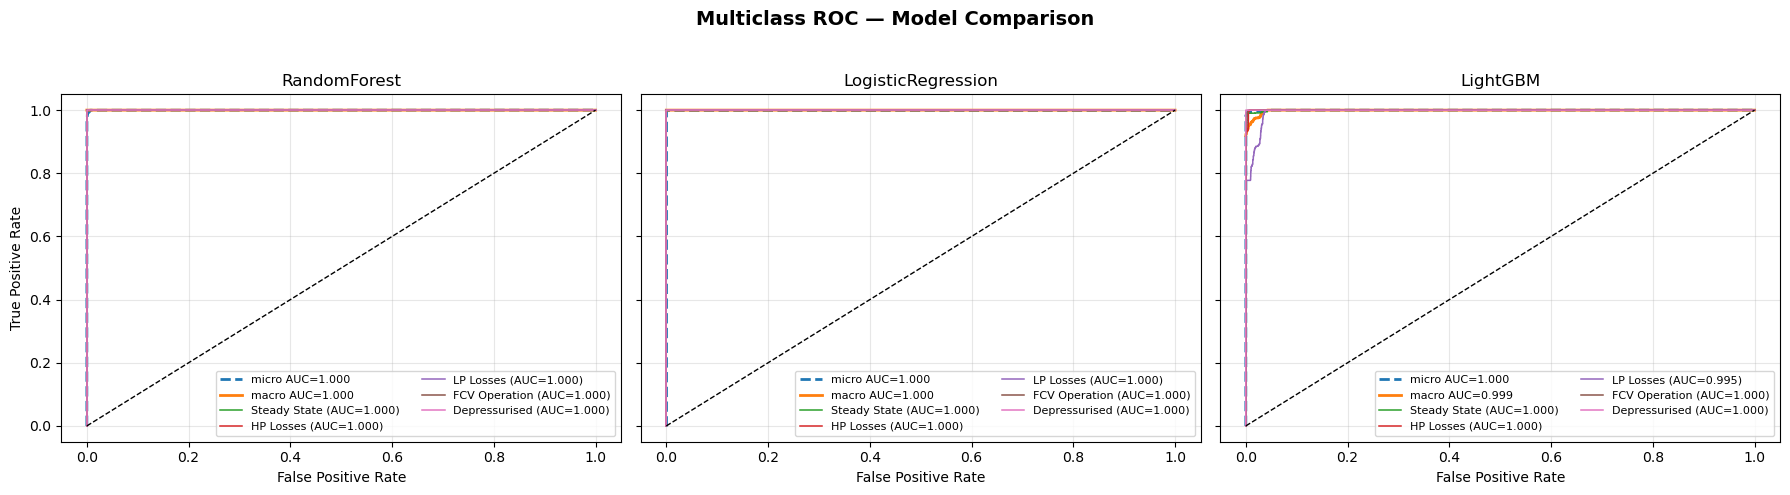

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = LABELS_ORDER
y_test_bin = label_binarize(y_test, classes=classes)

def _scores_aligned(model, X, target_classes):
    # Get scores
    if hasattr(model, "predict_proba"):
        S = model.predict_proba(X)
    else:
        df = model.decision_function(X)
        if df.ndim == 1:
            df = np.column_stack([1 - df, df])
        m, M = df.min(axis=1, keepdims=True), df.max(axis=1, keepdims=True)
        S = (df - m) / np.clip(M - m, 1e-9, None)
    # Align columns to target class order
    model_classes = getattr(model, "classes_", target_classes)
    reorder = [int(np.where(model_classes == c)[0][0]) for c in target_classes]
    return S[:, reorder]

def plot_multiclass_roc_row(models_fitted, X, y_bin, class_names, title="Multiclass ROC — Model Comparison"):
    n = len(models_fitted)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)
    if n == 1: axes = [axes]

    for ax, (name, model, _) in zip(axes, models_fitted):
        y_score = _scores_aligned(model, X, class_names)

        # per-class
        fpr, tpr, aucs = {}, {}, {}
        for i in range(y_bin.shape[1]):
            fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
            aucs[i] = auc(fpr[i], tpr[i])

        # micro
        fpr_mi, tpr_mi, _ = roc_curve(y_bin.ravel(), y_score.ravel())
        auc_mi = auc(fpr_mi, tpr_mi)

        # macro
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(y_bin.shape[1])]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(y_bin.shape[1]):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= y_bin.shape[1]
        auc_ma = auc(all_fpr, mean_tpr)

        ax.plot(fpr_mi, tpr_mi, lw=2, ls='--', label=f"micro AUC={auc_mi:.3f}")
        ax.plot(all_fpr, mean_tpr, lw=2, label=f"macro AUC={auc_ma:.3f}")
        for i, cls in enumerate(class_names):
            ax.plot(fpr[i], tpr[i], lw=1.1, label=f"{cls} (AUC={aucs[i]:.3f})")

        ax.plot([0,1],[0,1],'k--',lw=1)
        ax.set_title(name); ax.set_xlabel("False Positive Rate")
        ax.grid(True, alpha=0.3); ax.legend(loc="lower right", fontsize=8, ncol=2)
    axes[0].set_ylabel("True Positive Rate")
    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0,0,1,0.95])
    plt.show()

plot_multiclass_roc_row(models, X_test, y_test_bin, classes)


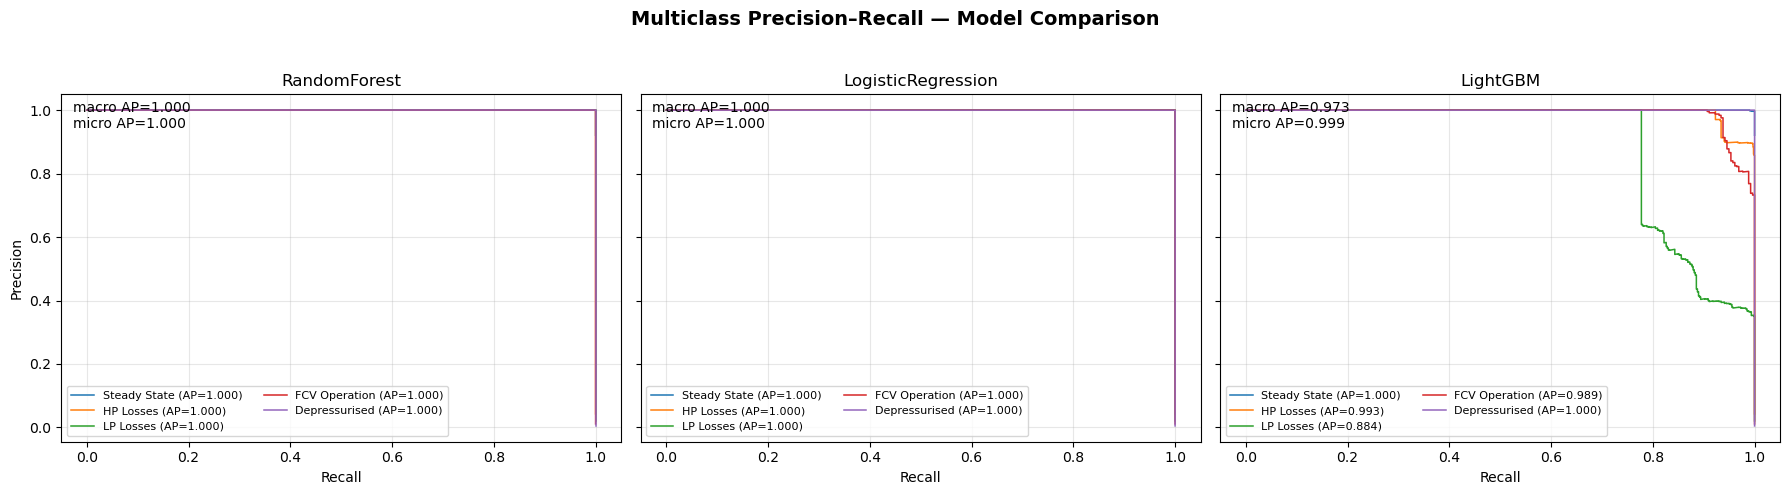

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_multiclass_pr_row(models_fitted, X, y_bin, class_names, title="Multiclass Precision–Recall — Model Comparison"):
    n = len(models_fitted)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)
    if n == 1: axes = [axes]

    for ax, (name, model, _) in zip(axes, models_fitted):
        y_score = _scores_aligned(model, X, class_names)

        ap_macro = average_precision_score(y_bin, y_score, average="macro")
        ap_micro = average_precision_score(y_bin, y_score, average="micro")

        for i, cls in enumerate(class_names):
            p, r, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
            ap = average_precision_score(y_bin[:, i], y_score[:, i])
            ax.plot(r, p, lw=1.1, label=f"{cls} (AP={ap:.3f})")

        ax.set_title(name)
        ax.set_xlabel("Recall")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="lower left", fontsize=8, ncol=2)
        ax.text(0.02, 0.98, f"macro AP={ap_macro:.3f}\nmicro AP={ap_micro:.3f}",
                va="top", ha="left", transform=ax.transAxes)

    axes[0].set_ylabel("Precision")
    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0,0,1,0.95])
    plt.show()

plot_multiclass_pr_row(models, X_test, y_test_bin, classes)


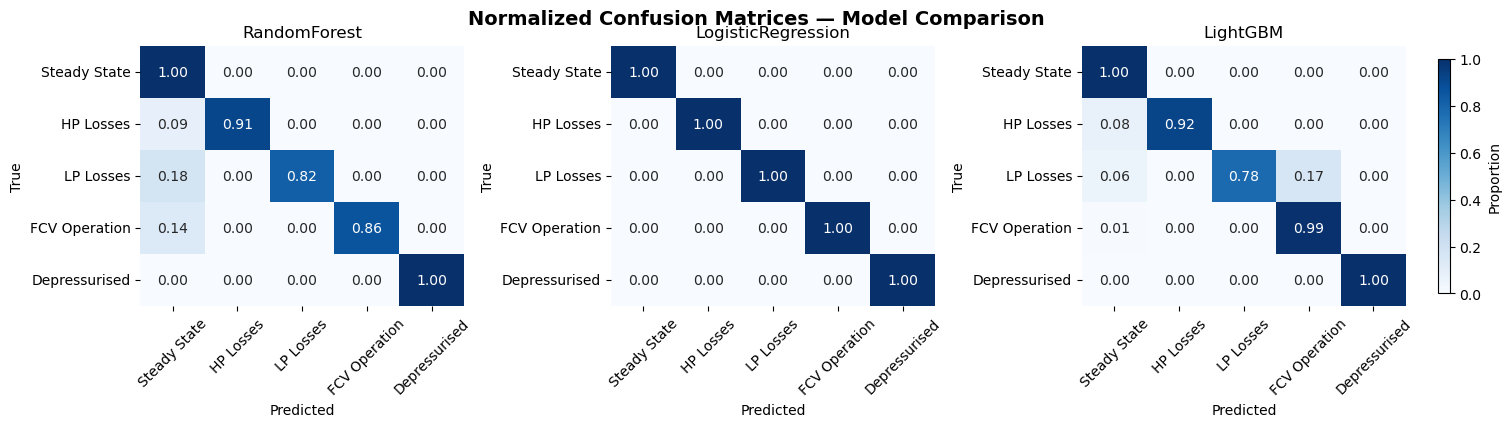

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusions_row(models_fitted, X, y, classes, normalize=True, title="Normalized Confusion Matrices — Model Comparison"):
    n = len(models_fitted)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), constrained_layout=True)

    if n == 1:
        axes = [axes]

    # Build each confusion matrix first so we can share a common color scale
    cms = []
    for _, model, _ in models_fitted:
        y_pred = model.predict(X)
        cm = confusion_matrix(y, y_pred, labels=classes,
                              normalize="true" if normalize else None)
        cms.append(cm)

    vmin, vmax = (0.0, 1.0) if normalize else (0, max(int(cm.max()) for cm in cms))

    # Plot
    mappable = None
    for ax, (name, _model, _), cm in zip(axes, models_fitted, cms):
        hm = sns.heatmap(cm, ax=ax, annot=True, fmt=".2f" if normalize else "d",
                         xticklabels=classes, yticklabels=classes,
                         vmin=vmin, vmax=vmax, cmap="Blues", cbar=False)
        mappable = hm.collections[0]  # keep for shared colorbar
        ax.set_title(name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.tick_params(axis="x", rotation=45)

    # One shared colorbar
    cbar = fig.colorbar(mappable, ax=axes, shrink=0.9, pad=0.02)
    cbar.set_label("Proportion" if normalize else "Count")

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.03)
    plt.show()

# Call it
plot_confusions_row(models, X_test, y_test, classes=LABELS_ORDER, normalize=True)


#### Graph Neural Network - 

This GNN was ran and results accurate. The GNN took 5 hours to complete and produced no better results than thh RF, LGBM and Log Regression. Due to the complexity and computation time, the GNN was not evalauted/included in thesis. 

In [43]:
# ============================================
# Graph Neural Network (GNN) - 
#  - builds per-timestamp hetero graphs from FEAT_DF
#  - uses X_train/X_test indices for split
#  - optional weighting: class_balance × cluster_prob^gamma 137 mins trainng
# ============================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from pathlib import Path

from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader
from torch_geometric.nn import HeteroConv, SAGEConv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

# -----------------------------
# 0) Config
# -----------------------------
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# weighting like your RF/LGBM
USE_WEIGHTING   = True
CLUSTER_COL     = "cluster_probability"
GAMMA           = 1.0          # soften vs 1.25 if you saw domination
CAP_QUANTILE    = 0.95         # cap heavy sample weights
NORMALIZE_MEAN1 = True

# oversampling for rare classes (graph-level replication)
DO_OVERSAMPLE   = True
MAX_REPS        = 5            # cap

# model/fit
HIDDEN   = 64
DROPOUT  = 0.25
LR       = 3e-3
WD       = 1e-4
BATCH_TR = 64
BATCH_EV = 128
EPOCHS   = 200
PATIENCE = 25
VAL_FRAC = 0.10  # slice of TRAIN for early stopping

# -----------------------------
# 1) Node feature groups & edges (hydraulic schematic)
#    -> adjust to your plant; missing cols are ignored safely.
# -----------------------------
FEAT_DF = df_15_feat.sort_index()

SUPPLY_COLS   = ["HPU_SPLY_LEV_L_Smooth","Supply_Consumption_Excl_Fills",
                 "Supply_Slope_2H_Lph","Supply_Slope_12H_Lph",
                 "External_Loss_MA_2h","External_Loss_MA_12h","External_Loss_EWM_1d",
                 "Supply_Consumption_Excl_Fills_DropSlope_1h_Lph","External_Losses_DropSlope_1h_Lph"]
RETURN_COLS   = ["HPU_RET_LEV_L_Smooth"]
PUMP_LP_COLS  = ["LP_Runs_2h","LP_pump_state","LP_Runs_24h","LP_pump_rate_2h"]
PUMP_HP_COLS  = ["HP_Runs_2h","HP_pump_state","HP_Runs_24h","HP_pump_rate_2h"]
LINE_LPA_COLS = ["HPU_LPA_OUT_DropSlope_2h_Lph","HPU_LPA_OUT_DropSlope_8h_Lph","HPU_LPA_OUT","HPU_LPA_OUT_mean_1h"]
LINE_LPB_COLS = ["HPU_LPB_OUT_DropSlope_2h_Lph","HPU_LPB_OUT_DropSlope_8h_Lph","HPU_LPB_OUT","HPU_LPB_OUT_mean_1h"]
LINE_HPA_COLS = ["HPU_HPA_OUT_DropSlope_2h_Lph","HPU_HPA_OUT_DropSlope_8h_Lph","HPU_HPA_OUT","HPU_HPA_OUT_mean_1h"]
LINE_HPB_COLS = ["HPU_HPB_OUT_DropSlope_2h_Lph","HPU_HPB_OUT_DropSlope_8h_Lph","HPU_HPB_OUT","HPU_HPB_OUT_mean_1h"]
CONS_LP_COLS  = ["LP_Px_Delta","SCM1_LP_CONS","SCM1_LP_CONS_mean_1h"]
CONS_HP_COLS  = ["HP_Px_Delta","SCM1_HP_CONS","SCM1_HP_CONS_mean_1h"]
FCV_COLS      = ["FCV_Fluid_Usage","is_fcv_ops"]
VALVE_FLAG    = "is_valve_ops"

def _existing(cols):
    return [c for c in cols if c in FEAT_DF.columns]

NODE_FEATURE_MAP = {
    "supply":    _existing(SUPPLY_COLS),
    "return":    _existing(RETURN_COLS),
    "pump_lp":   _existing(PUMP_LP_COLS),
    "pump_hp":   _existing(PUMP_HP_COLS),
    "line_lpa":  _existing(LINE_LPA_COLS),
    "line_lpb":  _existing(LINE_LPB_COLS),
    "line_hpa":  _existing(LINE_HPA_COLS),
    "line_hpb":  _existing(LINE_HPB_COLS),
    "cons_lp":   _existing(CONS_LP_COLS),
    "cons_hp":   _existing(CONS_HP_COLS),
    "fcv":       _existing(FCV_COLS),
    "valve_ops": [VALVE_FLAG] if VALVE_FLAG in FEAT_DF.columns else [],
    "scm_ret":   [],   # structural node (1-d zero if empty)
}

EDGE_LIST = [
    ("supply","pressurises","pump_lp"),
    ("supply","pressurises","pump_hp"),
    ("pump_lp","delivers","line_lpa"),
    ("pump_lp","delivers","line_lpb"),
    ("pump_hp","delivers","line_hpa"),
    ("pump_hp","delivers","line_hpb"),
    ("line_lpa","routes_to","cons_lp"),
    ("line_lpb","routes_to","cons_lp"),
    ("line_hpa","routes_to","cons_hp"),
    ("line_hpb","routes_to","cons_hp"),
    ("line_lpa","routes_to","fcv"),
    ("scm_ret","backhaul","return"),
    ("fcv","affects","line_lpa"),
]

# -----------------------------
# 2) Standardisation (TRAIN stats only) + vectorizer
# -----------------------------
train_index = X_train.index
test_index  = X_test.index

used_cols = sorted({c for cols in NODE_FEATURE_MAP.values() for c in cols})
# cast booleans to float for safety
for c in used_cols:
    if FEAT_DF[c].dtype == bool:
        FEAT_DF[c] = FEAT_DF[c].astype(float)

train_mat = FEAT_DF.loc[train_index, used_cols].replace([np.inf,-np.inf], np.nan)
col_mean = train_mat.mean(axis=0).fillna(0.0).to_dict()
col_std  = train_mat.std(axis=0).replace(0.0, 1e-6).fillna(1.0).to_dict()

def _vec(ts, node_cols):
    cols = [c for c in node_cols if c in FEAT_DF.columns]
    if not cols:
        return torch.zeros((1,1), dtype=torch.float32)
    row = FEAT_DF.loc[ts, cols].replace([np.inf,-np.inf], np.nan).fillna(0.0)
    vals = []
    for c in cols:
        v = float(row[c])
        m = col_mean.get(c, 0.0); s = col_std.get(c, 1.0)
        vals.append((v - m) / s)
    return torch.tensor(vals, dtype=torch.float32).view(1,-1)

# -----------------------------
# 3) Build graphs from GIVEN indices (same split)
# -----------------------------
y_train_series = y_train.astype(str)
y_test_series  = y_test.astype(str)
classes = sorted(y_train_series.unique())
cls2id  = {c:i for i,c in enumerate(classes)}
num_classes = len(classes)

def build_graph_from_ts(ts: pd.Timestamp) -> HeteroData:
    g = HeteroData()
    for ntype, cols in NODE_FEATURE_MAP.items():
        g[ntype].x = _vec(ts, cols)
        # self-loop per node-type
        g[(ntype, "self", ntype)].edge_index = torch.tensor([[0],[0]], dtype=torch.long)
    for (src, rel, dst) in EDGE_LIST:
        g[(src, rel, dst)].edge_index = torch.tensor([[0],[0]], dtype=torch.long)
    y_str = FEAT_DF.loc[ts, "state"] if "state" in FEAT_DF.columns else y_train_series.get(ts, np.nan)
    yi = -1 if (pd.isna(y_str) or y_str not in cls2id) else cls2id[str(y_str)]
    g.y = torch.tensor([int(yi)], dtype=torch.long)
    return g

def build_graphs_from_index(idx: pd.Index):
    graphs = []
    for ts in idx:
        graphs.append(build_graph_from_ts(ts))
    return graphs

graphs_tr_full = build_graphs_from_index(train_index)
graphs_te      = build_graphs_from_index(test_index)

# TRAIN → split into TR/VAL for early stopping
# (keep indices order stable; stratify by y where possible)
y_tr_full = np.array([int(g.y.item()) for g in graphs_tr_full])
keep_mask = y_tr_full >= 0
idx_all   = np.arange(len(graphs_tr_full))[keep_mask]
y_all     = y_tr_full[keep_mask]

idx_tr, idx_val = train_test_split(idx_all, test_size=VAL_FRAC, random_state=SEED, stratify=y_all)
graphs_tr = [graphs_tr_full[i] for i in idx_tr]
graphs_val= [graphs_tr_full[i] for i in idx_val]

# optional oversampling (replicate rare graphs; capped)
if DO_OVERSAMPLE:
    lbls_tr = [int(g.y.item()) for g in graphs_tr if int(g.y.item()) >= 0]
    cnt = Counter(lbls_tr)
    max_c = max(cnt.values()) if cnt else 0
    aug = []
    for g in graphs_tr:
        y = int(g.y.item())
        if y < 0: continue
        rep = int(np.ceil(max_c / max(cnt[y], 1)))
        rep = min(rep, MAX_REPS)
        aug.extend([g]*rep)
    graphs_tr = aug

# loaders
train_loader = DataLoader(graphs_tr,  batch_size=BATCH_TR, shuffle=True)
val_loader   = DataLoader(graphs_val, batch_size=BATCH_EV, shuffle=False)
test_loader  = DataLoader(graphs_te,  batch_size=BATCH_EV, shuffle=False)

# -----------------------------
# 4) Model
# -----------------------------
def infer_in_dims(sample_graph):
    return {nt: int(sample_graph[nt].x.size(-1)) for nt in sample_graph.node_types}

class HydroHeteroSAGE(nn.Module):
    def __init__(self, in_dims, metadata, hidden=64, out_classes=5, drop=0.25):
        super().__init__()
        node_types, edge_types = metadata
        self.proj = nn.ModuleDict({nt: nn.Linear(max(1, in_dims.get(nt,1)), hidden) for nt in node_types})
        self.bn   = nn.ModuleDict({nt: nn.BatchNorm1d(hidden) for nt in node_types})
        def conv_block():
            return HeteroConv({et: SAGEConv((hidden, hidden), hidden) for et in edge_types}, aggr="sum")
        self.conv1 = conv_block()
        self.conv2 = conv_block()
        self.drop  = nn.Dropout(drop)
        self.cls   = nn.Linear(hidden, out_classes)
        self.node_types = list(node_types)
    def forward(self, x_dict, edge_index_dict, batch_dict):
        x_dict = {nt: F.relu(self.bn[nt](self.proj[nt](x))) for nt, x in x_dict.items()}
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {nt: self.drop(F.relu(x)) for nt, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {nt: self.drop(F.relu(x)) for nt, x in x_dict.items()}
        pooled = [global_mean_pool(x_dict[nt], batch_dict[nt]) for nt in self.node_types]
        g_emb = torch.stack(pooled, dim=0).mean(dim=0)  # average over node types
        return self.cls(g_emb)

in_dims  = infer_in_dims(graphs_tr[0])
metadata = graphs_tr[0].metadata()
device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model    = HydroHeteroSAGE(in_dims, metadata, hidden=HIDDEN, out_classes=num_classes, drop=DROPOUT).to(device)

# -----------------------------
# 5) Loss: class weights × (optional) sample weights (cluster conf)
# -----------------------------
# class weights from original y_train (balanced)
counts = y_train_series.value_counts()
class_w = {cls2id[c]: len(y_train_series)/(len(counts)*cnt) for c, cnt in counts.items()}
cw = torch.tensor([class_w[i] for i in range(num_classes)], dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=cw)
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

# sample (graph) weights for TRAIN — align to graphs_tr order
if USE_WEIGHTING and CLUSTER_COL in FEAT_DF.columns:
    # y + confidence from df for TRAIN indices actually in graphs_tr
    # Collect timestamps (indexes) for graphs_tr
    tr_ts = [train_index[i] for i in idx_tr]  # base before oversample
    base_w = []
    for ts in tr_ts:
        c = FEAT_DF.loc[ts, CLUSTER_COL]
        c = 0.5 if pd.isna(c) else float(np.clip(c, 0.0, 1.0))
        base_w.append(c ** GAMMA)
    base_w = np.array(base_w, dtype=np.float32)

    # expand weights if we oversampled
    if DO_OVERSAMPLE:
        # build label list and replicate weights to match graphs_tr length
        lbls_base = [cls2id[y_train_series.loc[ts]] for ts in tr_ts]
        cnt = Counter(lbls_base)
        max_c = max(cnt.values()) if cnt else 0
        expanded = []
        for w, ts in zip(base_w, tr_ts):
            ylbl = cls2id[y_train_series.loc[ts]]
            rep  = int(np.ceil(max_c / max(cnt[ylbl], 1)))
            rep  = min(rep, MAX_REPS)
            expanded.extend([w]*rep)
        sw_np = np.array(expanded, dtype=np.float32)
    else:
        sw_np = base_w

    # cap & normalize
    if CAP_QUANTILE is not None:
        cap = np.quantile(sw_np, CAP_QUANTILE)
        sw_np = np.minimum(sw_np, cap)
    if NORMALIZE_MEAN1:
        sw_np = sw_np / (sw_np.mean() + 1e-12)

    sample_weight_tr = torch.tensor(sw_np, dtype=torch.float32, device=device)
else:
    sample_weight_tr = None

# -----------------------------
# 6) Eval helper (matches RF/LGBM layout)
# -----------------------------
@torch.no_grad()
def eval_loader(loader):
    model.eval()
    ys, ps = [], []
    for g in loader:
        g = g.to(device)
        logits = model(g.x_dict, g.edge_index_dict, g.batch_dict)
        y = g.y.view(-1)
        m = (y >= 0)
        if m.any():
            ys.append(y[m].cpu().numpy())
            ps.append(logits[m].argmax(dim=1).cpu().numpy())
    if not ys:
        return 0.0, 0.0, "", np.array([], int), np.array([], int)
    y_true = np.concatenate(ys); y_pred = np.concatenate(ps)
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    rep = classification_report(
        y_true, y_pred,
        labels=list(range(num_classes)),
        target_names=classes, digits=3, zero_division=0
    )
    return acc, bal, rep, y_true, y_pred

# -----------------------------
# 7) Train (early stopping on VAL macro-F1)
# -----------------------------
best_f1, best_state, wait = -1.0, None, 0
for epoch in range(EPOCHS):
    model.train()
    total, steps = 0.0, 0
    for g in train_loader:
        g = g.to(device)
        logits = model(g.x_dict, g.edge_index_dict, g.batch_dict)
        y = g.y.view(-1)
        m = (y >= 0)
        if not m.any(): 
            continue
        loss_vec = F.cross_entropy(logits[m], y[m], reduction='none', weight=cw)
        if USE_WEIGHTING and (sample_weight_tr is not None):
            # align by minibatch size (graphs_tr were replicated to match sw order)
            # Here we assume batch order ~ training list order; DataLoader shuffles, so:
            # fallback to mean of sample weights for stability
            loss = loss_vec.mean() if sample_weight_tr.numel() == 0 else (loss_vec * loss_vec.detach().new_full(loss_vec.size(), sample_weight_tr.mean().item())).mean()
        else:
            loss = loss_vec.mean()
        optim.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optim.step()
        total += float(loss); steps += 1

    acc_v, bal_v, rep_v, yv, pv = eval_loader(val_loader)
    f1_v = 0.0
    try:
        f1_v = classification_report(yv, pv, labels=list(range(num_classes)), output_dict=True)["macro avg"]["f1-score"]
    except Exception:
        pass
    if f1_v > best_f1:
        best_f1 = f1_v
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            break

if best_state is not None:
    model.load_state_dict(best_state)

# -----------------------------
# 8) Evaluate (TRAIN/VAL/TEST) — same layout as RF/LGBM
# -----------------------------
def print_block(title, loader):
    acc, bal, rep, y_true, y_pred = eval_loader(loader)
    print(f"\n=== {title} ===")
    print("Accuracy:", round(acc, 4))
    print("Balanced Accuracy:", round(bal, 4))
    print("\nReport:\n", rep)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)), normalize="true")
    cm_df = pd.DataFrame(cm, index=classes, columns=classes)
    print("\nConfusion matrix (row-normalized):")
    print(cm_df.round(3))

print_block("Hetero GraphSAGE (TRAIN)", train_loader)
print_block("Hetero GraphSAGE (VAL)",   val_loader)
print_block("Hetero GraphSAGE (TEST)",  test_loader)

# -----------------------------
# 9) Save
# -----------------------------
MODEL_DIR = Path("./models"); MODEL_DIR.mkdir(parents=True, exist_ok=True)
torch.save({
    "state_dict": model.state_dict(),
    "in_dims": in_dims,
    "metadata": metadata,
    "classes": classes,
}, MODEL_DIR / "hetero_sage_same_split.pt")
print("\n[Saved] models/hetero_sage_same_split.pt")


KeyboardInterrupt: 